# Time evolution of t-J model

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np

from ncon import ncon

from scipy.sparse import csc_array, kron
import scipy.sparse as sp
from scipy.linalg import svd, norm

from qs_mps.sparse_hamiltonians_and_operators import diagonalization, U_evolution_sparse
from qs_mps.mps_class import MPS
from qs_mps.utils import tensor_shapes, mps_to_vector, logarithm_base_d, mpo_to_matrix

import matplotlib.pyplot as plt

# default parameters of the plot layout
plt.rcParams["text.usetex"] = True  # use latex
plt.rcParams["font.size"] = 13
plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.constrained_layout.use"] = True

## Exact

In [3]:
# Single-site identity
Id = sp.identity(3, format="csr").toarray()
O = csc_array((3, 3), dtype=complex).toarray()

# Spin operators
Sz = (1/2) * sp.diags([1, 0, -1], 0, format="csr")

S_plus  = sp.csr_matrix([[0, 0, 1],
                         [0, 0, 0],
                         [0, 0, 0]])

S_minus = sp.csr_matrix([[0, 0, 0],
                         [0, 0, 0],
                         [1, 0, 0]])

# Hole hopping operators

# hole goes into a spin up state
T_up_h   = sp.csr_matrix([[0, 1, 0],
                          [0, 0, 0],
                          [0, 0, 0]])

# hole goes into a spin down state
T_down_h = sp.csr_matrix([[0, 0, 0],
                          [0, 0, 0],
                          [0, 1, 0]])

# spin up goes into a hole state
T_h_up   = sp.csr_matrix([[0, 0, 0],
                          [1, 0, 0],
                          [0, 0, 0]])

# spin down goes into a hole state
T_h_down = sp.csr_matrix([[0, 0, 0],
                          [0, 0, 1],
                          [0, 0, 0]])

# Hole number operator
n_h = sp.csr_matrix([[0, 0, 0],
                     [0, 1, 0],
                     [0, 0, 0]])

In [4]:
def kron_sparse_op(Op, i, n):
    if (i > 1) and (i < n):
        left = Id
        right = Id
        for k in range(1,i-1):
            left = kron(left, Id)
        for k in range(i+1,n):
            right = kron(Id, right)
        return kron(kron(left, Op),right)
    elif i == 1:
        right = Id
        for k in range(i+1,n):
            right = kron(Id, right)
        return kron(Op,right)
    elif i == n:
        left = Id
        for k in range(1,i-1):
            left = kron(left, Id)        
        return kron(left, Op)

# Heisenberg ham
def heis_ham(n, Jz, J_perp, eps):
    # zz-int
    H_zz = sp.csr_matrix((3**n,3**n))
    if Jz != 0:
        for i in range(1,n):
            H_zz += kron_sparse_op(Sz,i,n) @ kron_sparse_op(Sz,i+1,n)
    
    # pm-int
    H_pm = sp.csr_matrix((3**n,3**n))
    if J_perp != 0:
        for i in range(1,n):
            H_pm += kron_sparse_op(S_plus,i,n) @ kron_sparse_op(S_minus,i+1,n)
    
    # pm-int
    H_mp = sp.csr_matrix((3**n,3**n))
    if J_perp != 0:
        for i in range(1,n):
            H_mp += kron_sparse_op(S_minus,i,n) @ kron_sparse_op(S_plus,i+1,n)
    
    # breaking degeneracy (if eps<0 -> up, if eps>0 -> down)
    H_z = sp.csr_matrix((3**n,3**n))
    if eps != 0:
        for i in range(1,n+1):
            H_z += kron_sparse_op(Sz,i,n)

    return Jz * H_zz + (J_perp / 2) * (H_pm + H_mp) + eps * H_z

# hopping ham
def hop_ham(n, t_up, t_down):
    # up-hole
    H_uh = sp.csr_matrix((3**n,3**n))
    if t_up != 0:
        for i in range(1,n):
            H_uh += kron_sparse_op(T_up_h,i,n) @ kron_sparse_op(T_h_up,i+1,n)

    # hole-up
    H_hu = sp.csr_matrix((3**n,3**n))
    if t_up != 0:
        for i in range(1,n):
            H_hu += kron_sparse_op(T_h_up,i,n) @ kron_sparse_op(T_up_h,i+1,n)
    
    # down-hole
    H_dh = sp.csr_matrix((3**n,3**n))
    if t_down != 0:
        for i in range(1,n):
            H_dh += kron_sparse_op(T_down_h,i,n) @ kron_sparse_op(T_h_down,i+1,n)

    # hole-down
    H_hd = sp.csr_matrix((3**n,3**n))
    if t_down != 0:
        for i in range(1,n):
            H_hd += kron_sparse_op(T_h_down,i,n) @ kron_sparse_op(T_down_h,i+1,n)
    

    return - t_up * (H_uh + H_hu) - t_down * (H_dh + H_hd)

# hopping ham for next to nearest neighbor
def hop_2_ham(n, tp_up, tp_down):
    # up-hole
    H_uh = sp.csr_matrix((3**n,3**n))
    if tp_up != 0:
        for i in range(1,n-1):
            H_uh += kron_sparse_op(T_up_h,i,n) @ kron_sparse_op(T_h_up,i+2,n)

    # hole-up
    H_hu = sp.csr_matrix((3**n,3**n))
    if tp_up != 0:
        for i in range(1,n-1):
            H_hu += kron_sparse_op(T_h_up,i,n) @ kron_sparse_op(T_up_h,i+2,n)
    
    # down-hole
    H_dh = sp.csr_matrix((3**n,3**n))
    if tp_down != 0:
        for i in range(1,n-1):
            H_dh += kron_sparse_op(T_down_h,i,n) @ kron_sparse_op(T_h_down,i+2,n)

    # hole-down
    H_hd = sp.csr_matrix((3**n,3**n))
    if tp_down != 0:
        for i in range(1,n-1):
            H_hd += kron_sparse_op(T_h_down,i,n) @ kron_sparse_op(T_down_h,i+2,n)
    

    return - (tp_up/8) * (H_uh + H_hu) - (tp_down/8) * (H_dh + H_hd)


# holes ham
def hol_ham(n, V):
    # zz-int
    H_hh = sp.csr_matrix((3**n,3**n))
    if V != 0:
        for i in range(1,n):
            H_hh += kron_sparse_op(n_h,i,n) @ kron_sparse_op(n_h,i+1,n)
    
    return V * H_hh

def tJV_ham(n, t_up, t_down, Jz, J_perp, eps, V, tp_up=0, tp_down=0):
    H_t = hop_ham(n=n, t_up=t_up, t_down=t_down)
    H_J = heis_ham(n=n, Jz=Jz, J_perp=J_perp, eps=eps)
    H_V = hol_ham(n=n, V=V)
    H_nnn = hop_2_ham(n=n, tp_up=tp_up, tp_down=tp_down)

    return H_t + H_J + H_V + H_nnn

In [5]:
def hole_occupation(n):
    nh = sp.csr_matrix((3**n, 3**n))
    for i in range(1, n+1):
        nh += kron_sparse_op(n_h, i, n)
    return nh/n

def local_hole_occupation(n):
    return [kron_sparse_op(n_h, i, n) for i in range(1, n+1)]

def local_mag_occupation(n):
    return [kron_sparse_op(2*Sz, i, n) for i in range(1, n+1)]

def total_magnetization(n):
    M = sp.csr_matrix((3**n, 3**n))
    for i in range(1, n+1):
        M += kron_sparse_op(2*Sz, i, n)
    return M/n

def staggered_total_magnetization(n):
    M = sp.csr_matrix((3**n, 3**n))
    for i in range(1, n+1):
        if (i % 2) == 0:
            M -= kron_sparse_op(2*Sz, i, n)
        elif (i % 2) == 1:
            M += kron_sparse_op(2*Sz, i, n)
    return M

In [6]:
def half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, n_holes=1, tp_up=0, tp_down=0):
    H_tJ_0 = tJV_ham(n=half_chain_length, t_up=t_up, t_down=t_down, Jz=Jz, J_perp=J_perp, eps=eps, V=V, tp_up=tp_up, tp_down=tp_down)
    e, v = diagonalization(H_tJ_0, sparse=False)
    psi_init_side = v[:,0]

    # mps_ancilla_side = MPS(half_chain_length, 3, "tj", chi=100)
    # # mps_ancilla_side.vector_to_mps(psi_init_side, trunc_chi=False, trunc_tol=True)
    # # mps_ancilla_side.vector_to_mps(psi_init_side, trunc_chi=False, trunc_tol=True, ancilla=True)
    # mps_ancilla_side.vector_to_mps(psi_init_side, trunc_chi=True, trunc_tol=False, ancilla=True)
    # mps_ancilla_side.vector_to_mps(psi_init_side, trunc_chi=True, trunc_tol=False)
    # mps_ancilla_side.flipping_all_tj(ancilla=True)
    # # mps_ancilla_side.canonical_form(ancilla=True)
    # tensor_shapes(mps_ancilla_side.sites)
    # print("-----------")
    # tensor_shapes(mps_ancilla_side.ancilla_sites)
    # hole_state = np.array([[0,1,0]]).reshape((1,3,1))
    # mps_init = mps_ancilla_side.sites + [hole_state]*n_holes + mps_ancilla_side.ancilla_sites
    # mps = MPS(2*half_chain_length+n_holes, 3, "tj", chi=100)
    # mps.sites = mps_init
    # mps.canonical_form()
    # psi_init = mps_to_vector(mps.sites)
    # # psi_init = mps_to_vector(mps_init)

    psi_init_left = psi_init_side.copy()
    # psi_init_right = psi_init_side.copy()

    psi_init_right = psi_init_side.copy()
    # psi_init_right[3::4] = psi_init_right[1::4]
    # psi_init_right[1::4] = psi_init_side[3::4].copy()
    # psi_init_right[2::4] = psi_init_right[2::4][::-1]

    psi_hole = np.array([0,1,0])
    if n_holes == 1:
        psi_init = kron(kron(psi_init_left, psi_hole), psi_init_right).T.toarray()
    if n_holes == 2:
        psi_init = kron(psi_init_left, kron(psi_hole, kron(psi_hole, psi_init_right))).T.toarray()
    # psi_init = kron(kron(psi_init_left, psi_hole), psi_init_left).T.toarray()
    psi_init = psi_init.reshape(3**(2*half_chain_length+n_holes))

    # print(psi_init.shape)

    H_tJ_ev = tJV_ham(n=2*half_chain_length+n_holes, t_up=t_up, t_down=t_down, Jz=Jz, J_perp=J_perp, eps=eps, V=V, tp_up=tp_up, tp_down=tp_down)

    return H_tJ_ev, psi_init

def half_hole_quench_evolution(half_chain_length, H_tJ_ev, psi_init, trotter_steps, final_time, obs=[], n_holes=1, save=False):
    psi_ev = psi_init.copy()

    exp_vals = []
    psi_save = []

    if len(obs) == 0:
        obs = ['h_loc']
    
    if 'h_loc' in obs:
        ops_h = local_hole_occupation(2*half_chain_length + n_holes)

    if 'm_loc' in obs:
        ops_m = local_mag_occupation(2*half_chain_length + n_holes)

    occup_tot_h = []
    occup_tot_m = []

    for trott in range(trotter_steps):
        print(f"Trotter step: {trott}")
        psi_ev = U_evolution_sparse(psi_init=psi_ev, H_ev=H_tJ_ev, trotter=trotter_steps, time=final_time)
        if save:
            psi_save.append(psi_ev.copy())
        
        if 'h_loc' in obs:
            occup = []
            for op in ops_h:
                occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
                # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
            occup_tot_h.append(occup)
    
        if 'm_loc' in obs:
            occup = []
            for op in ops_m:
                occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
                # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
            occup_tot_m.append(occup)
    
    exp_vals.append(occup_tot_h)
    exp_vals.append(occup_tot_m)
    return exp_vals, psi_save

In [7]:
half_chain_length = 2
t_up = 2
t_down = 2
Jz = 10
J_perp = 0
eps = 0
V = 0
trotter_steps = 100
final_time = 2

In [8]:
spin_up = np.array([1,0,0])
hole = np.array([0,1,0])
spin_down = np.array([0,0,1])

H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, n_holes=1)

# psi_init = kron(spin_up, kron(spin_down, kron(spin_up, kron(hole, kron(hole, kron(spin_up, kron(spin_down, spin_up))))))).T.toarray()
# psi_init = kron(spin_down, kron(spin_up, kron(spin_down, kron(hole, kron(hole, kron(spin_down, kron(spin_up, spin_down))))))).T.toarray()
# psi_init = kron(spin_up, kron(spin_down, kron(spin_up, kron(hole, kron(hole, kron(spin_down, kron(spin_up, spin_down))))))).T.toarray()
# psi_init = kron(spin_down, kron(spin_up, kron(spin_down, kron(hole, kron(hole, kron(spin_up, kron(spin_down, spin_up))))))).T.toarray()
# psi_init = kron(hole, kron(hole, kron(hole, kron(spin_up, kron(spin_up, kron(hole, kron(hole, hole))))))).T.toarray()
# psi_init = kron(hole, kron(hole, kron(spin_up, kron(hole, hole)))).T.toarray()
# psi_init = kron(hole, kron(hole, kron(spin_up, kron(spin_up, kron(hole, hole))))).T.toarray()
# psi_init = psi_init.reshape((3**6))
# psi_init = psi_init.reshape((3**8))

# H_ev = tJV_ham(n=2*half_chain_length+2, t_up=t_up, t_down=t_down, Jz=Jz, J_perp=J_perp, eps=eps, V=V)
exp_vals, psi_save = half_hole_quench_evolution(half_chain_length, H_ev, psi_init, trotter_steps, final_time, obs=['h_loc', 'm_loc'], n_holes=1, save=True)

Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

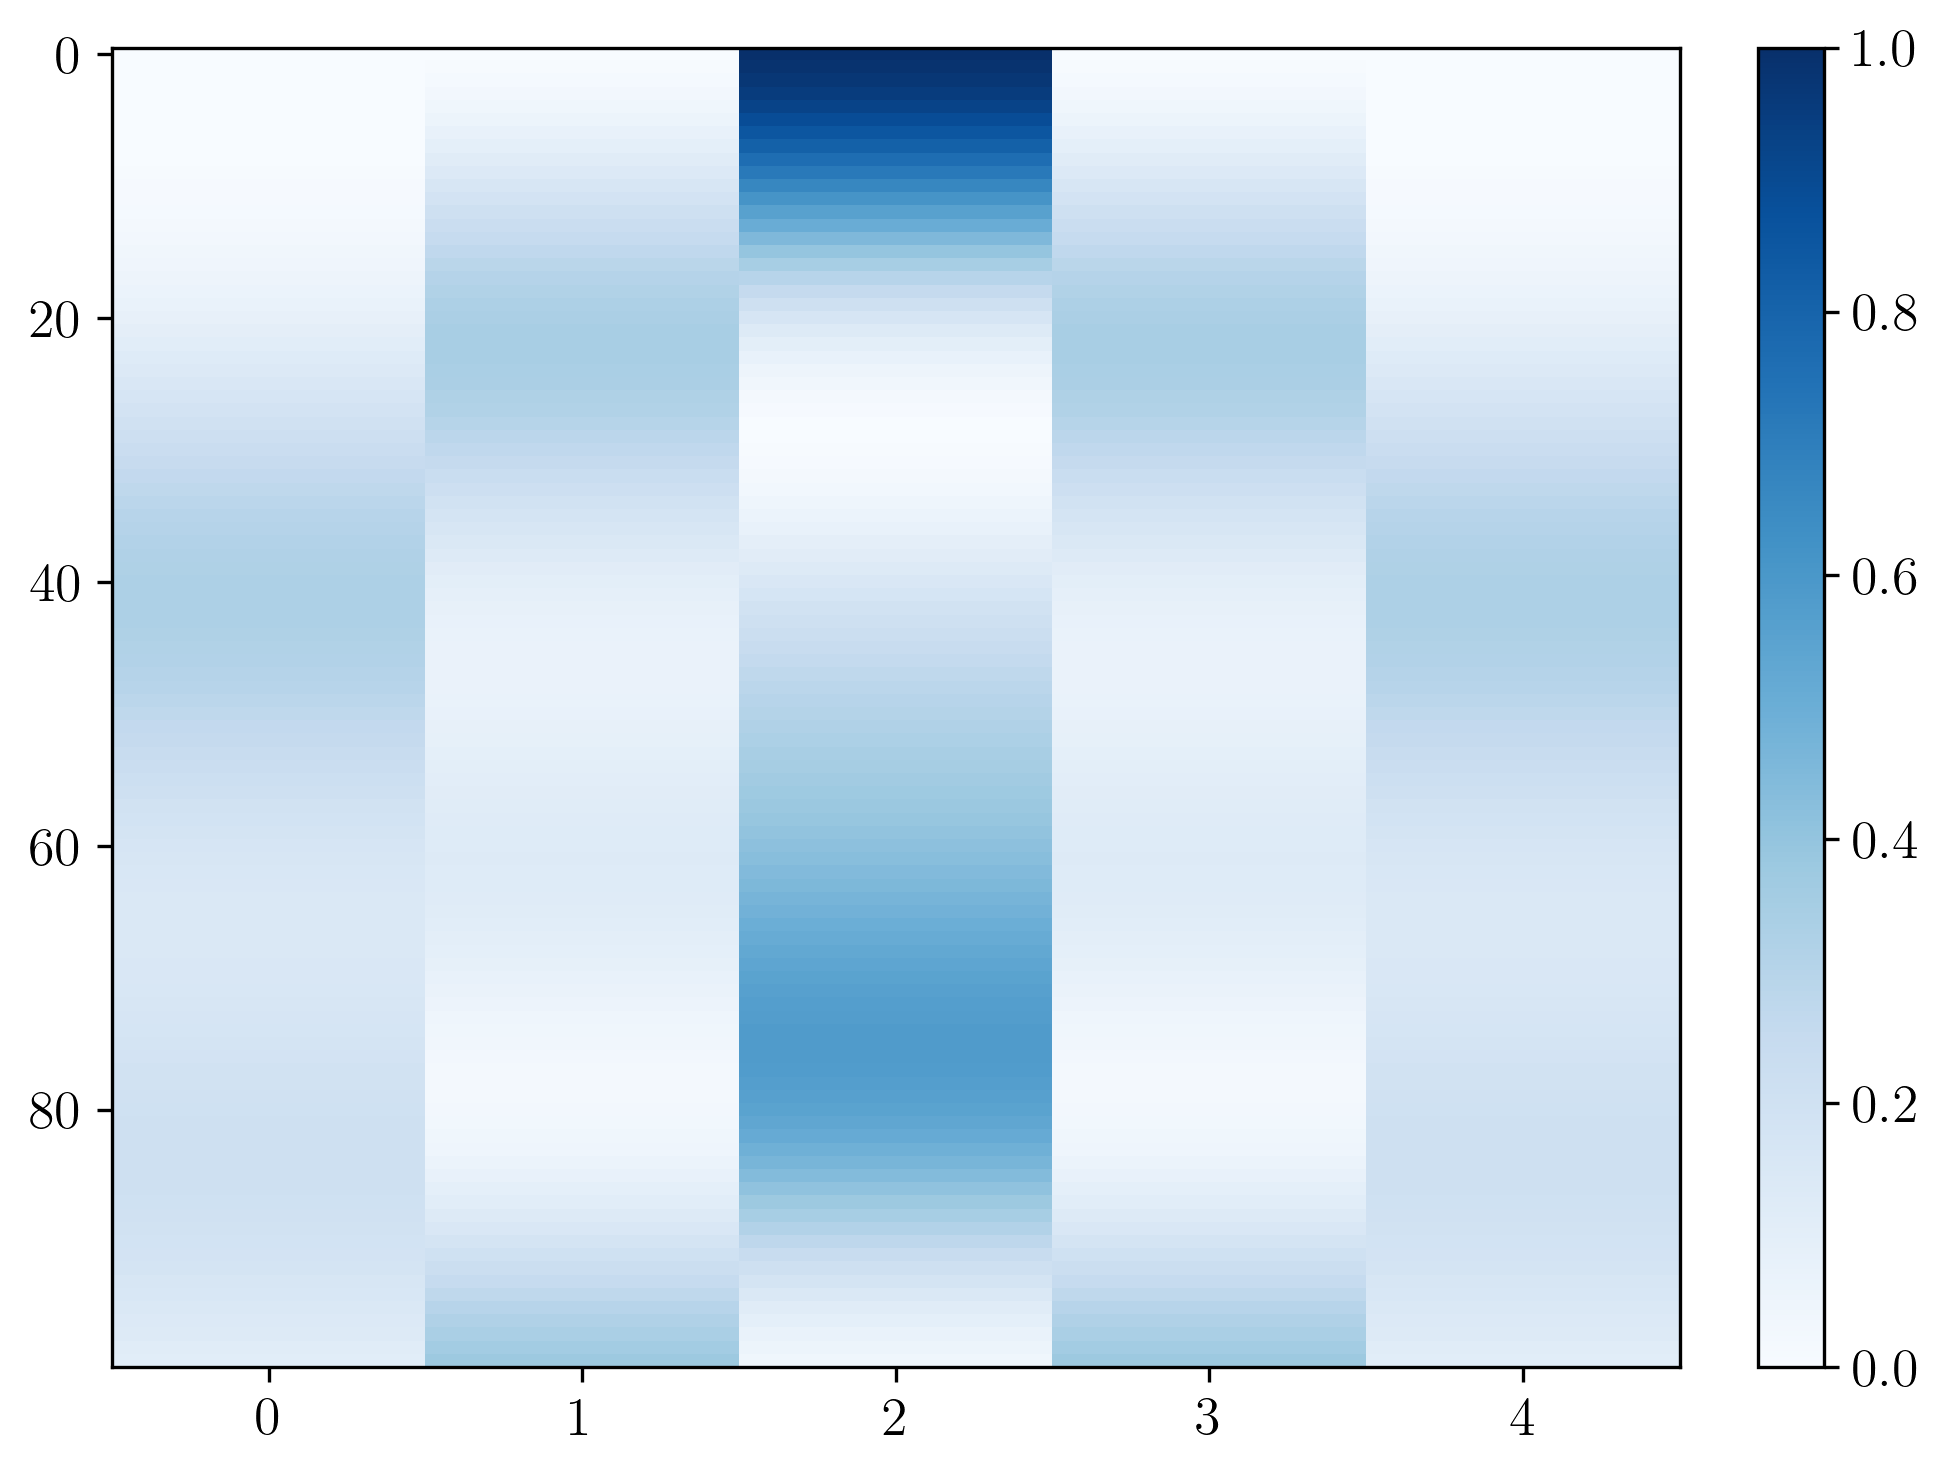

In [9]:
# plt.imshow(np.asarray(exp_vals[1]), vmin=-1, vmax=1, aspect='auto', cmap='seismic')
plt.imshow(np.asarray(exp_vals[0]), vmin=0, vmax=1, aspect='auto', cmap='Blues')
plt.colorbar()

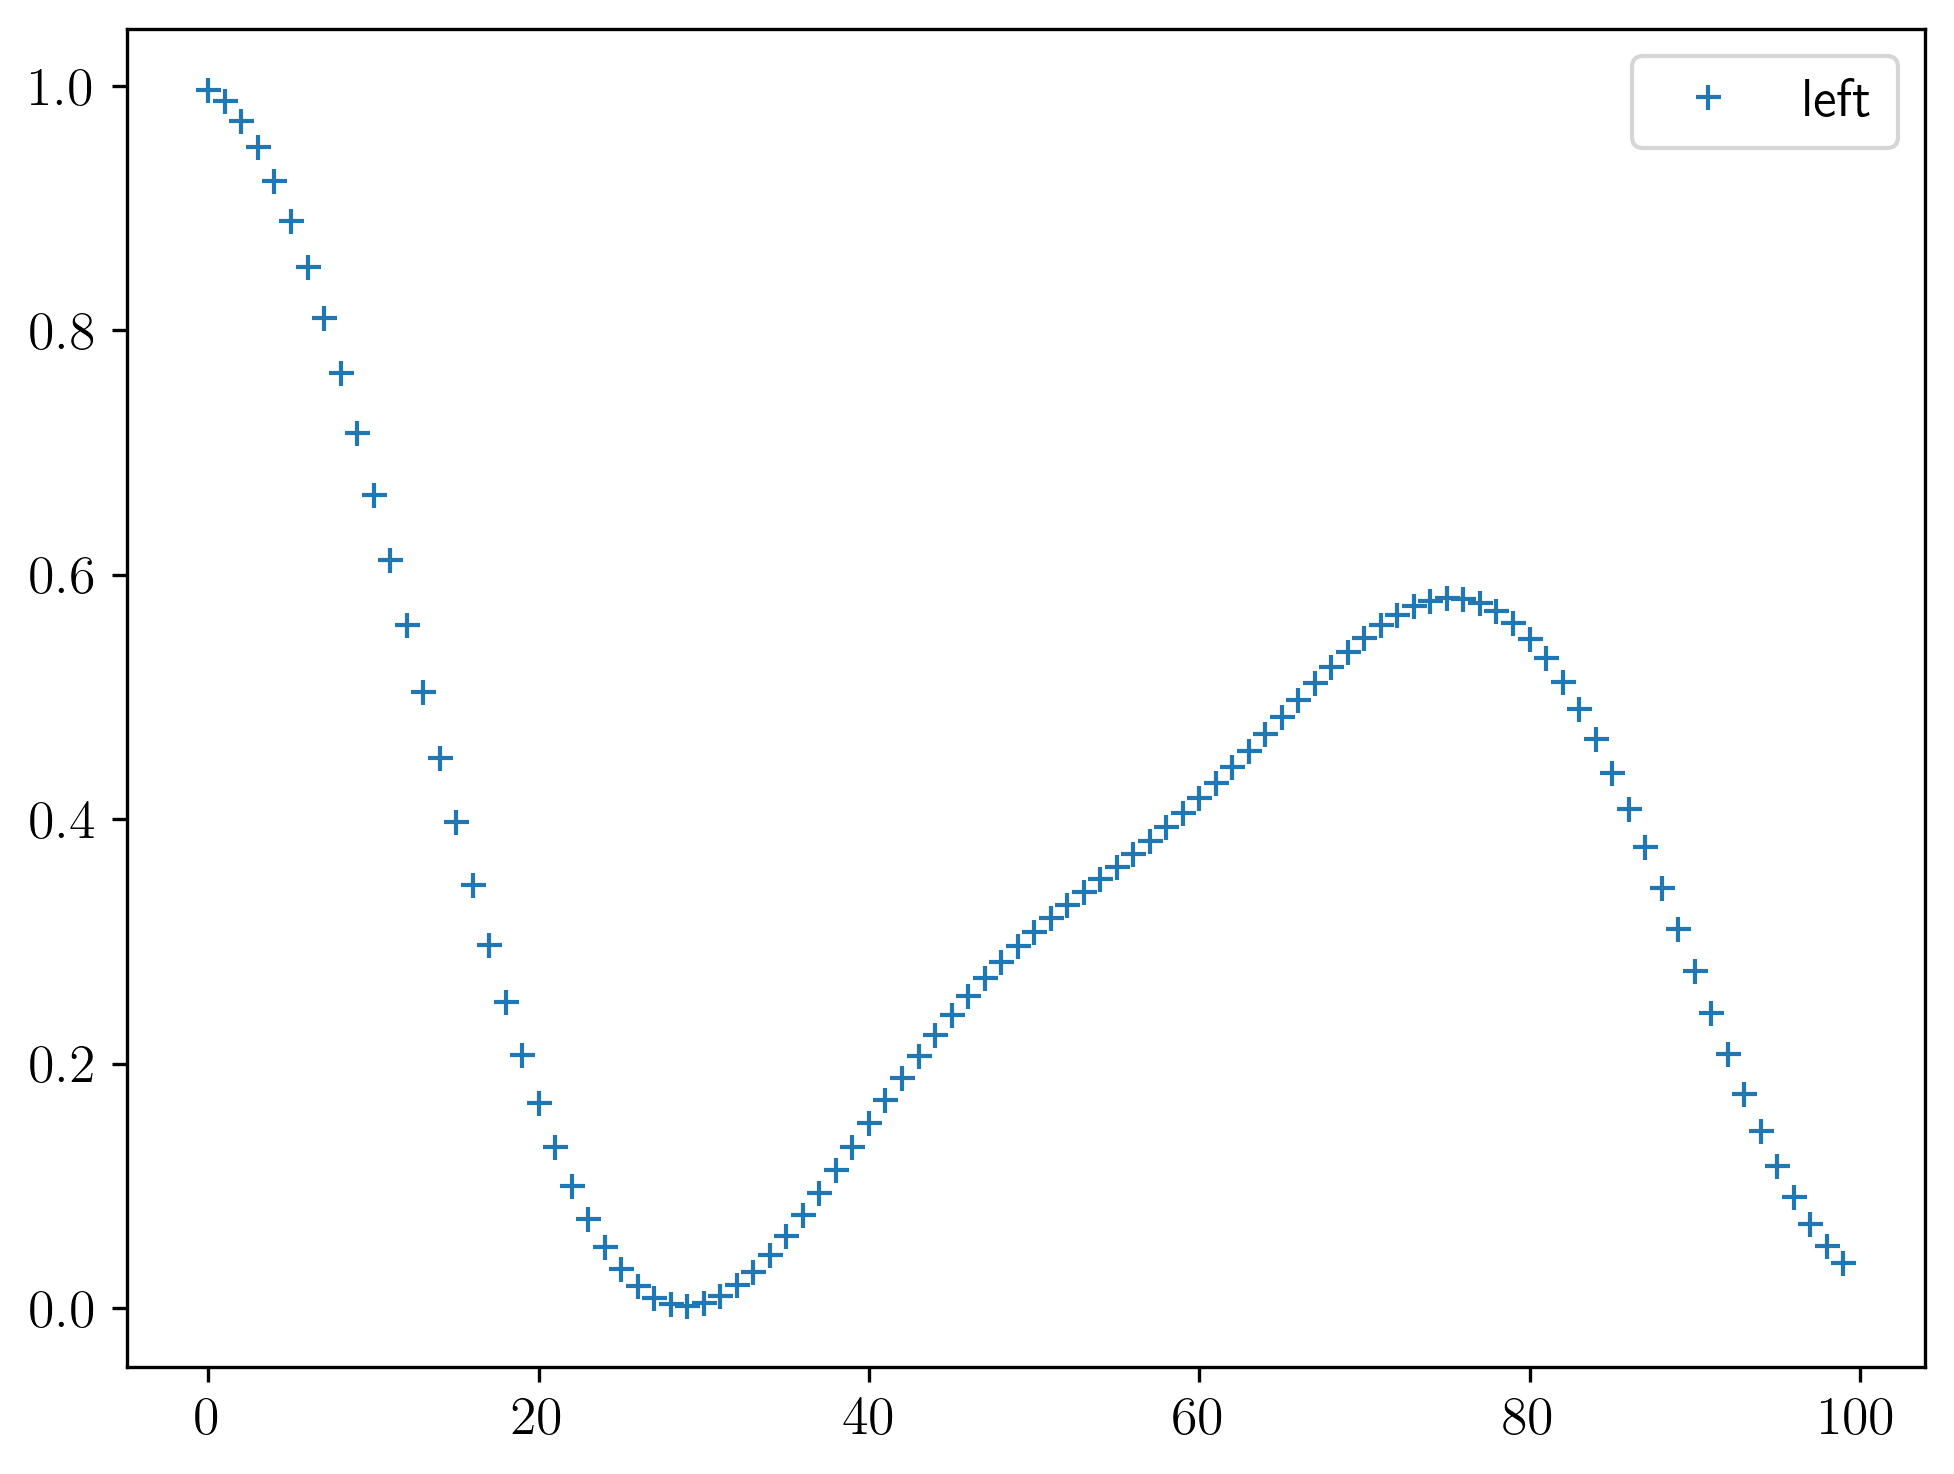

In [10]:
plt.plot(np.asarray(exp_vals[0])[:,2],'+', label='left')
# plt.plot(np.asarray(exp_vals[0])[:,5],'x', label='right')
# plt.plot(np.abs(np.asarray(exp_vals[0])[:,0] - np.asarray(exp_vals[0])[:,4]),'x', label='left - right')
plt.legend()

Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

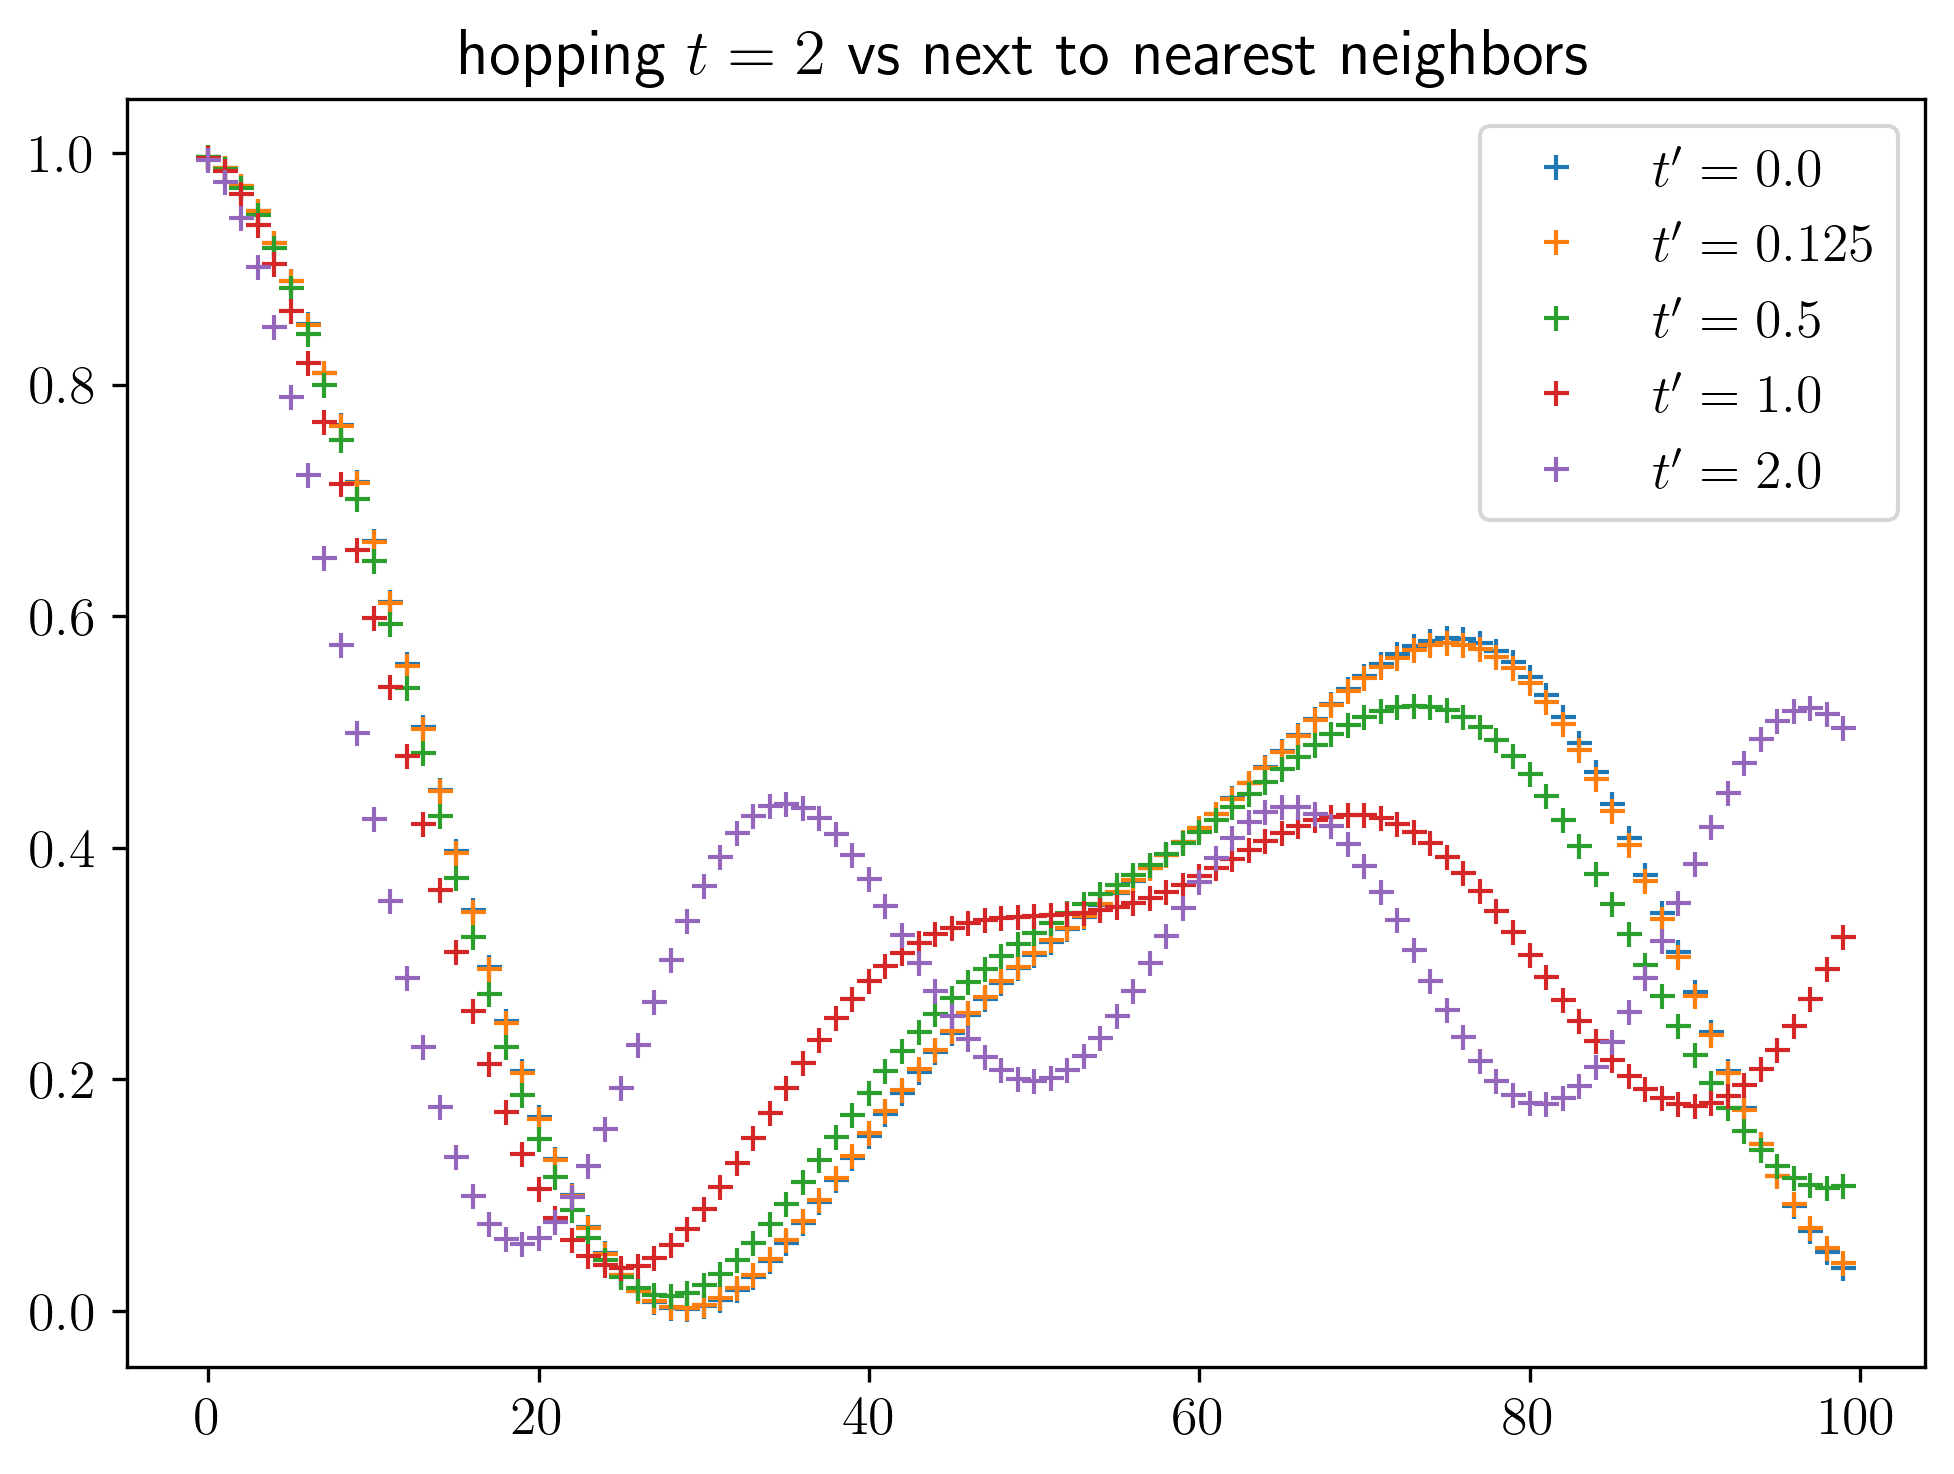

In [11]:
tp_ups = [0,1,4,8,16]
tp_downs = [0,1,4,8,16]
for tp_up, tp_down in zip(tp_ups, tp_downs):
    H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, tp_up=tp_up, tp_down=tp_down)
    occup_tot, _ = half_hole_quench_evolution(half_chain_length, H_ev, psi_init, trotter_steps, final_time)
    plt.plot(np.asarray(occup_tot[0])[:,2],'+', label=f'$t\' ={tp_up/8}$')

plt.title("hopping $t=2$ vs next to nearest neighbors")
plt.legend()

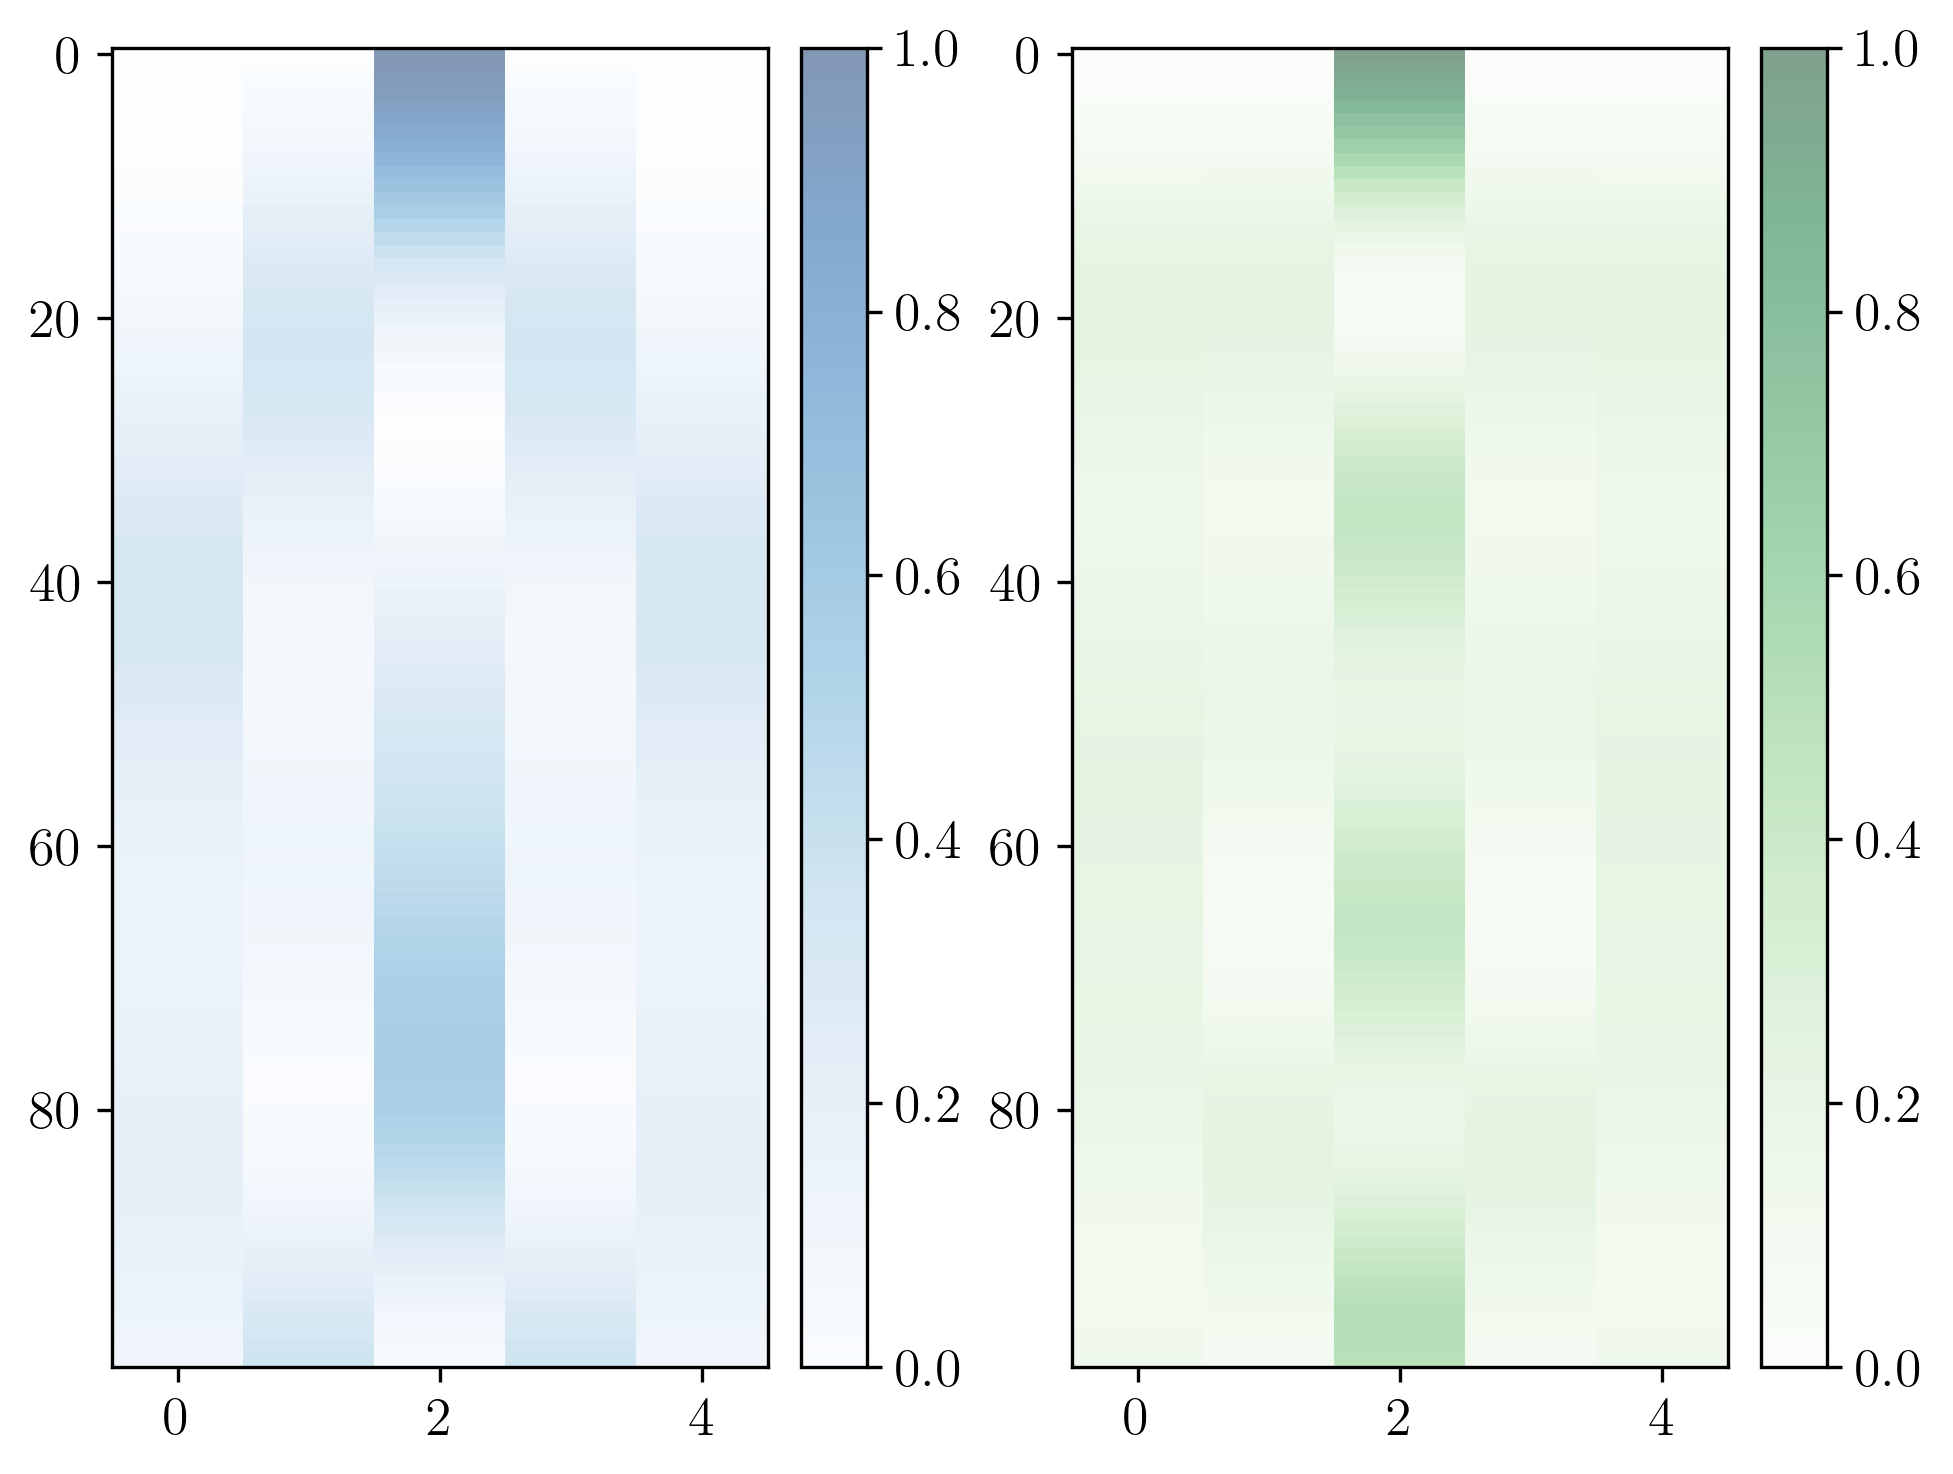

In [12]:
fig, ax = plt.subplots(1,2)
im1 = ax[0].imshow(np.asarray(exp_vals[0]), vmin=0, vmax=1, aspect='auto', alpha=0.5, cmap='Blues')
fig.colorbar(im1)
im2 = ax[1].imshow(np.asarray(occup_tot[0]), vmin=0, vmax=1, aspect='auto', alpha=0.5, cmap='Greens')
fig.colorbar(im2)


Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

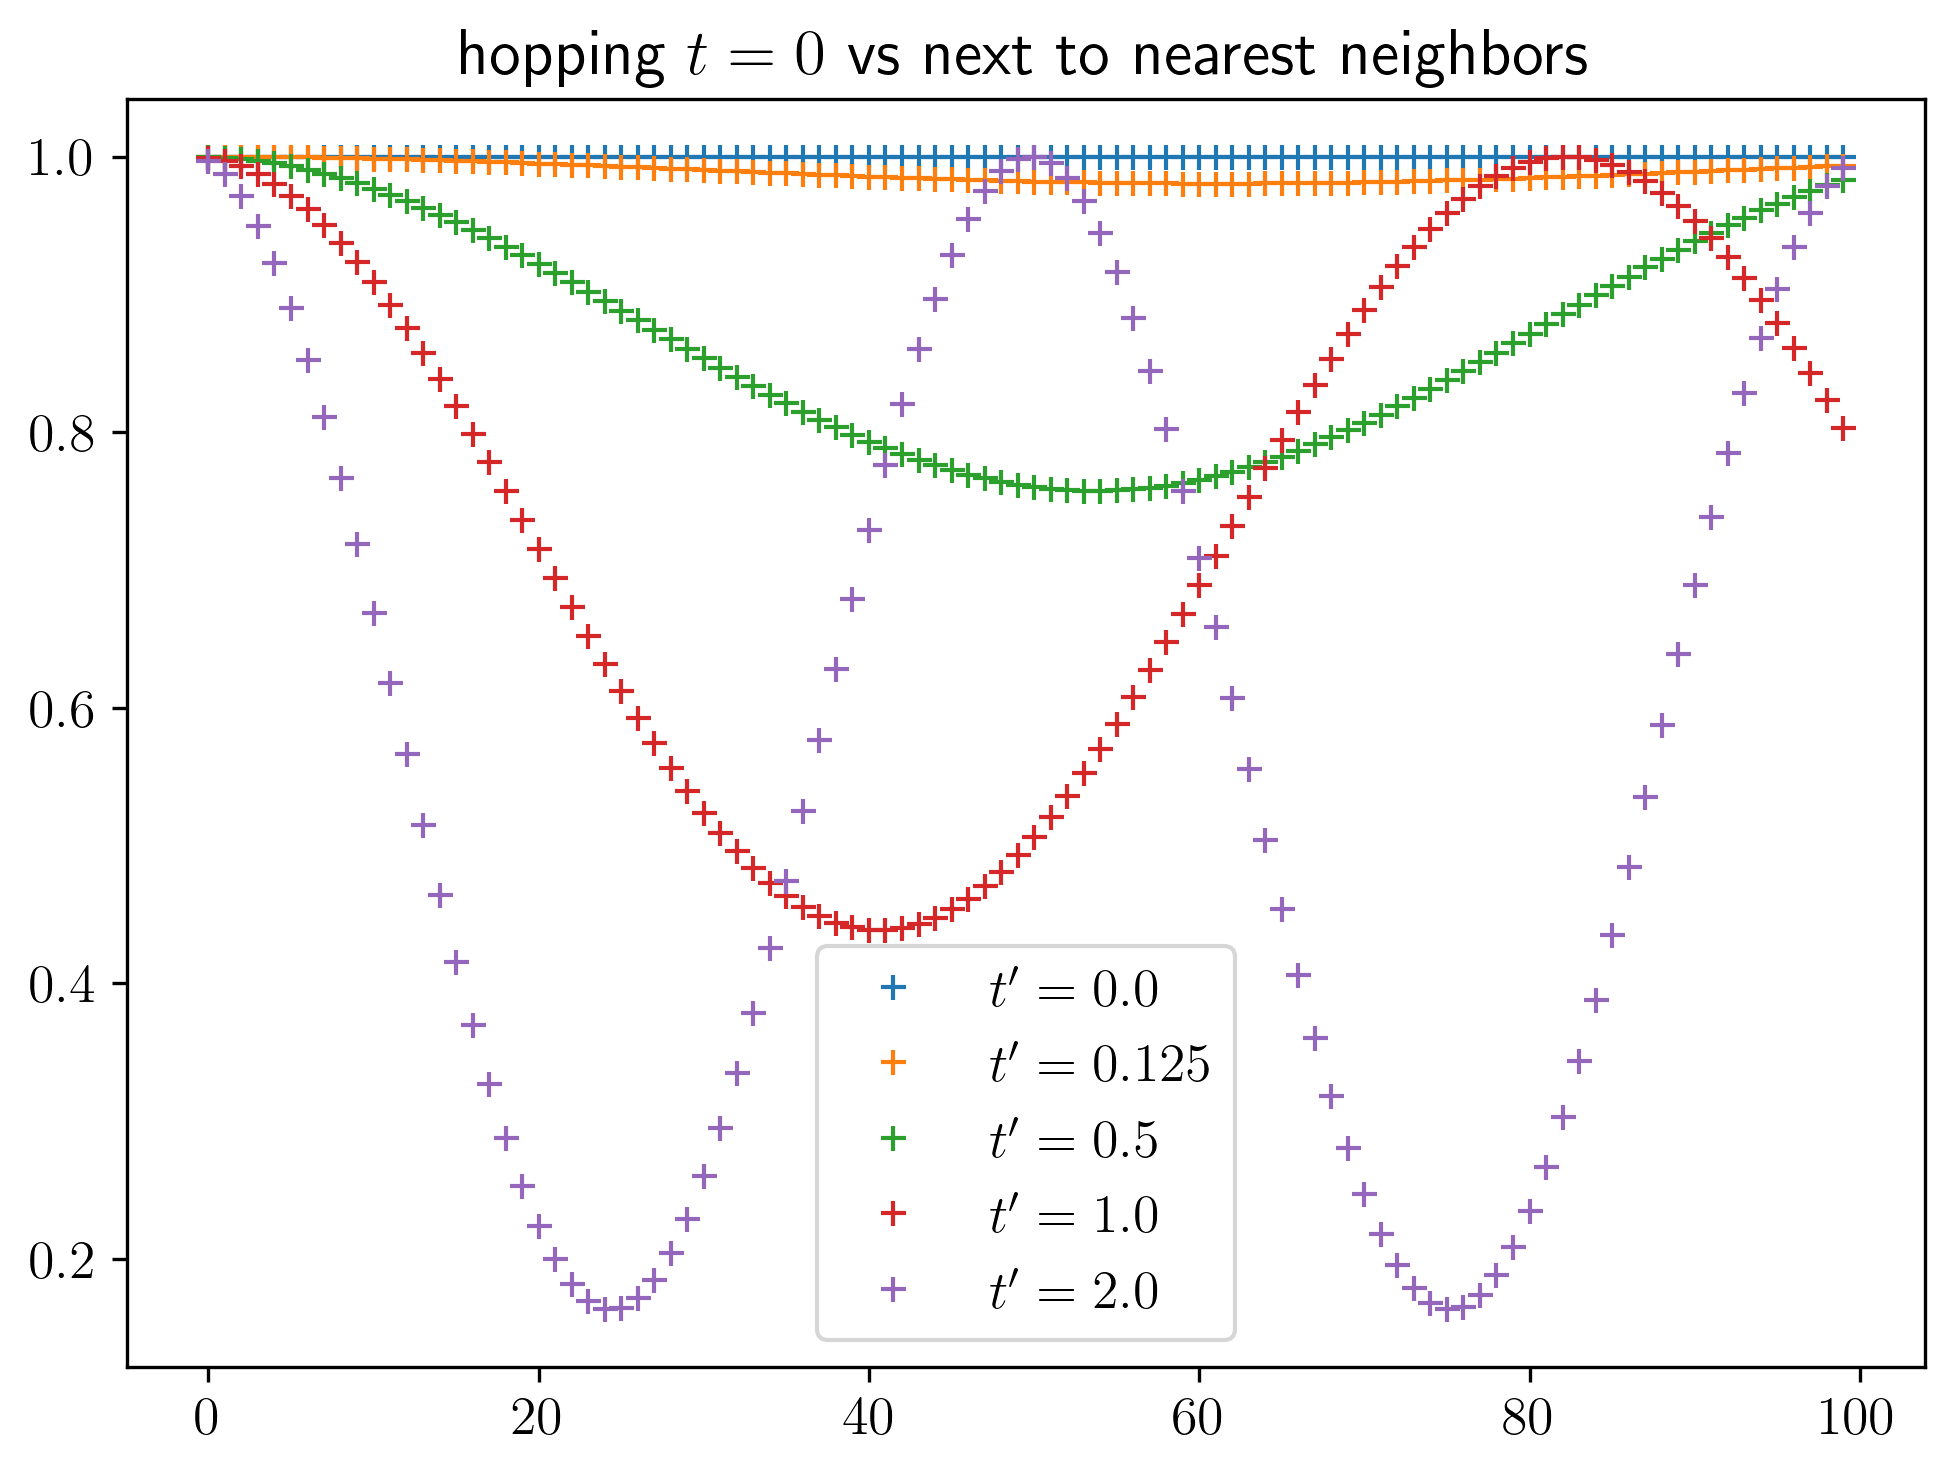

In [13]:
tp_ups = [0,1,4,8,16]
tp_downs = [0,1,4,8,16]
t_up = 0
t_down = 0
for tp_up, tp_down in zip(tp_ups, tp_downs):
    H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, tp_up=tp_up, tp_down=tp_down)
    occup_tot, _ = half_hole_quench_evolution(half_chain_length, H_ev, psi_init, trotter_steps, final_time)
    plt.plot(np.asarray(occup_tot[0])[:,2],'+', label=f'$t\' ={tp_up/8}$')

plt.title("hopping $t=0$ vs next to nearest neighbors")
plt.legend()

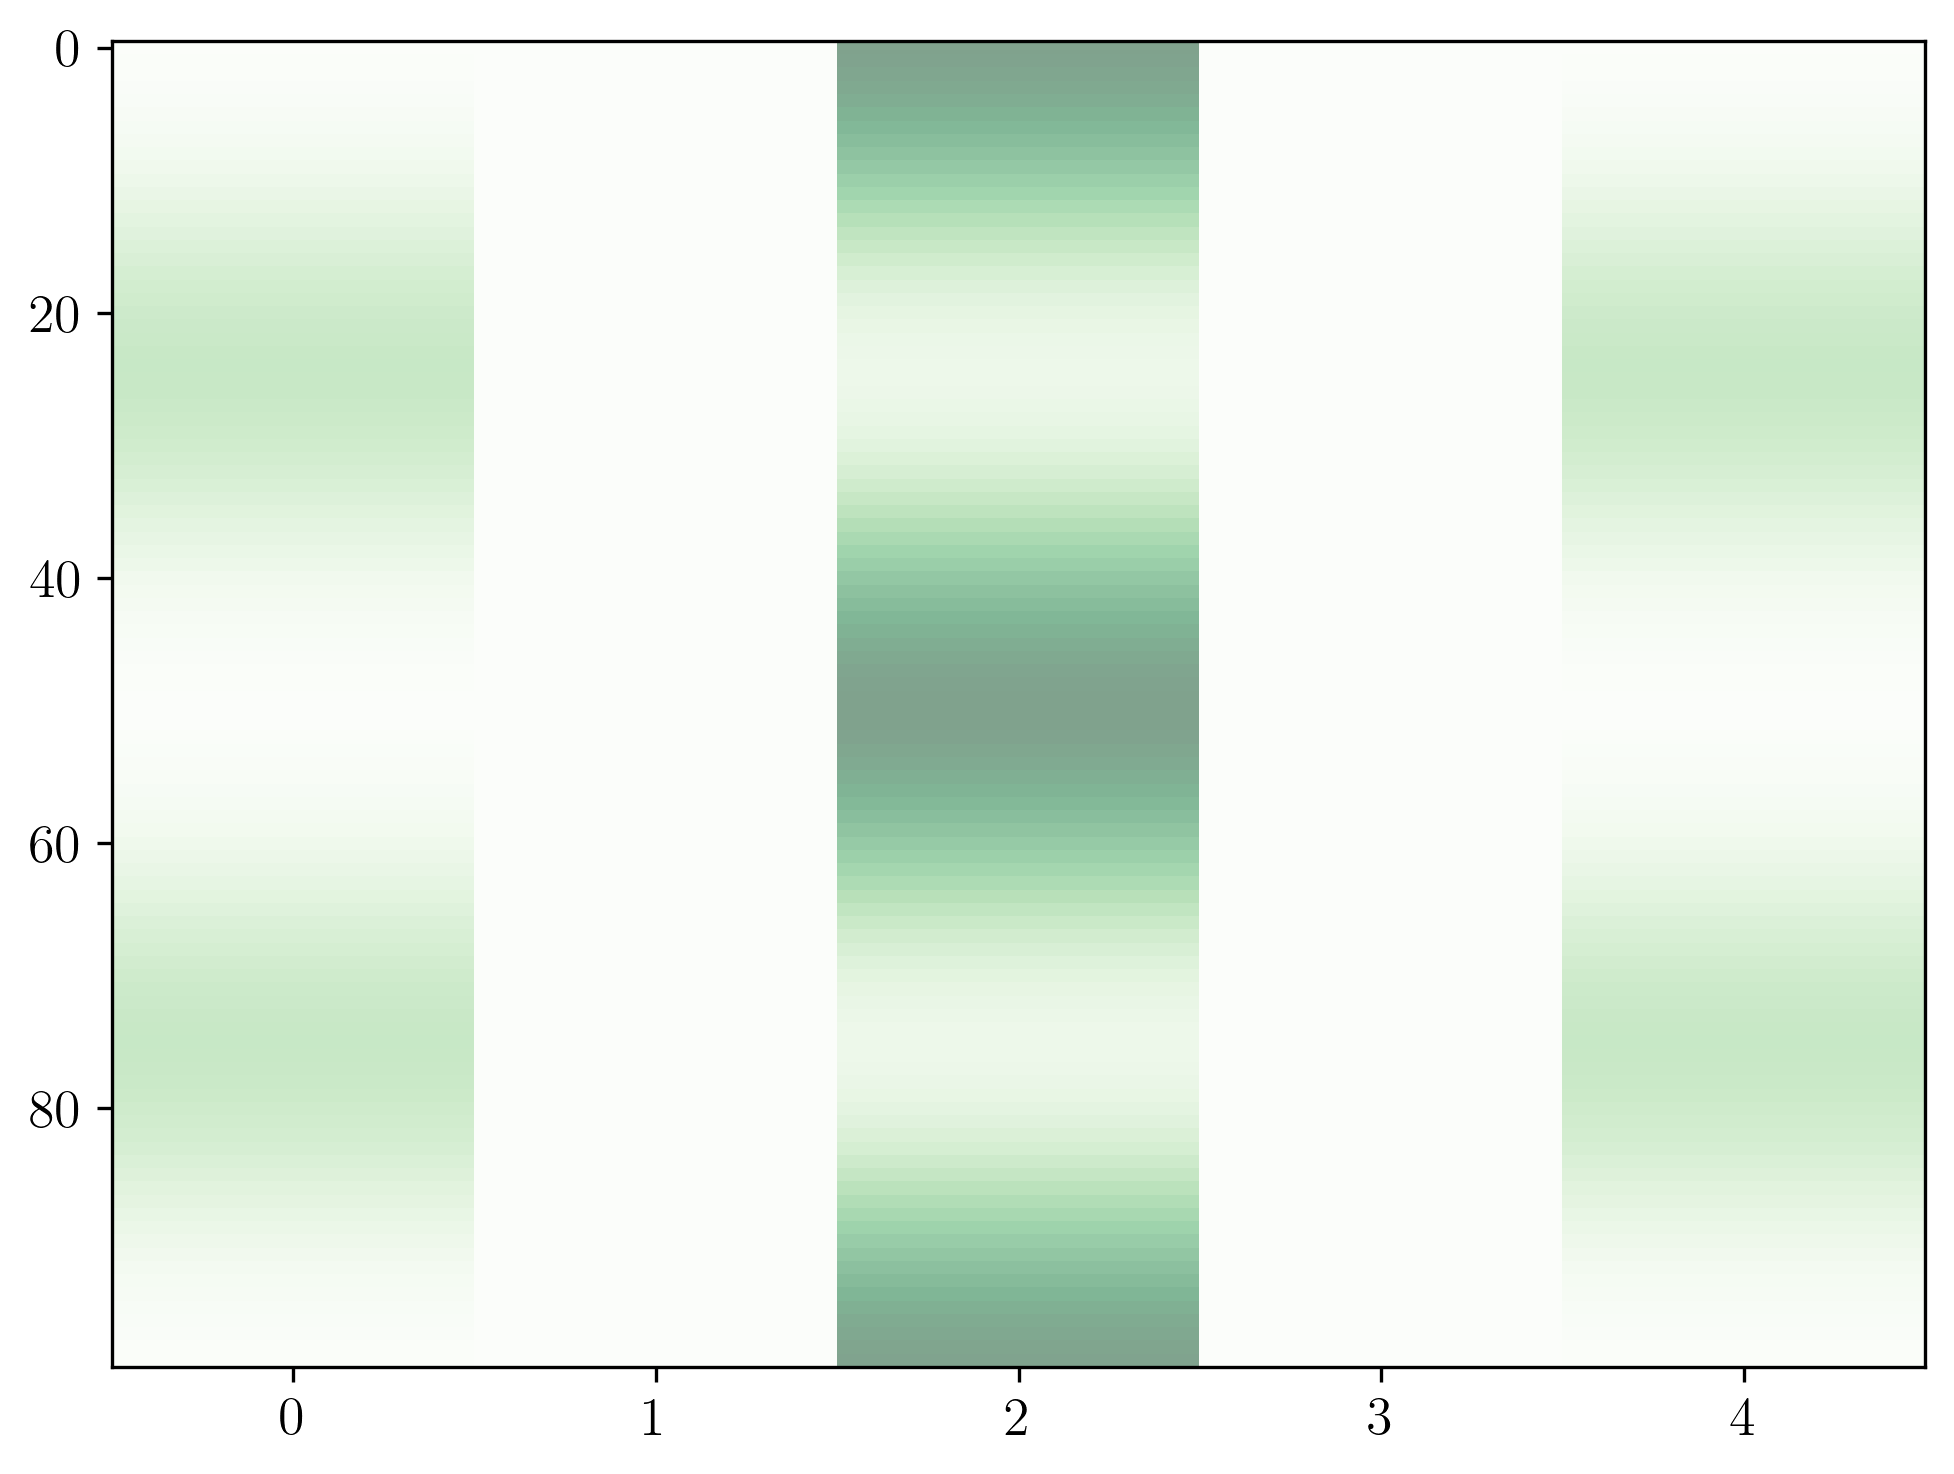

In [14]:
plt.imshow(np.asarray(occup_tot[0]), vmin=0, vmax=1, aspect='auto', alpha=0.5, cmap='Greens')

In [15]:
half_chain_length = 2
t_up = 0.1
t_down = 0.1
Jz = 10
J_perp = 1
eps = 0
V = 0
trotter_steps = 100
final_time = 2

In [16]:
H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V)
occup_tot, _ = half_hole_quench_evolution(half_chain_length, H_ev, psi_init, trotter_steps, final_time)

Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

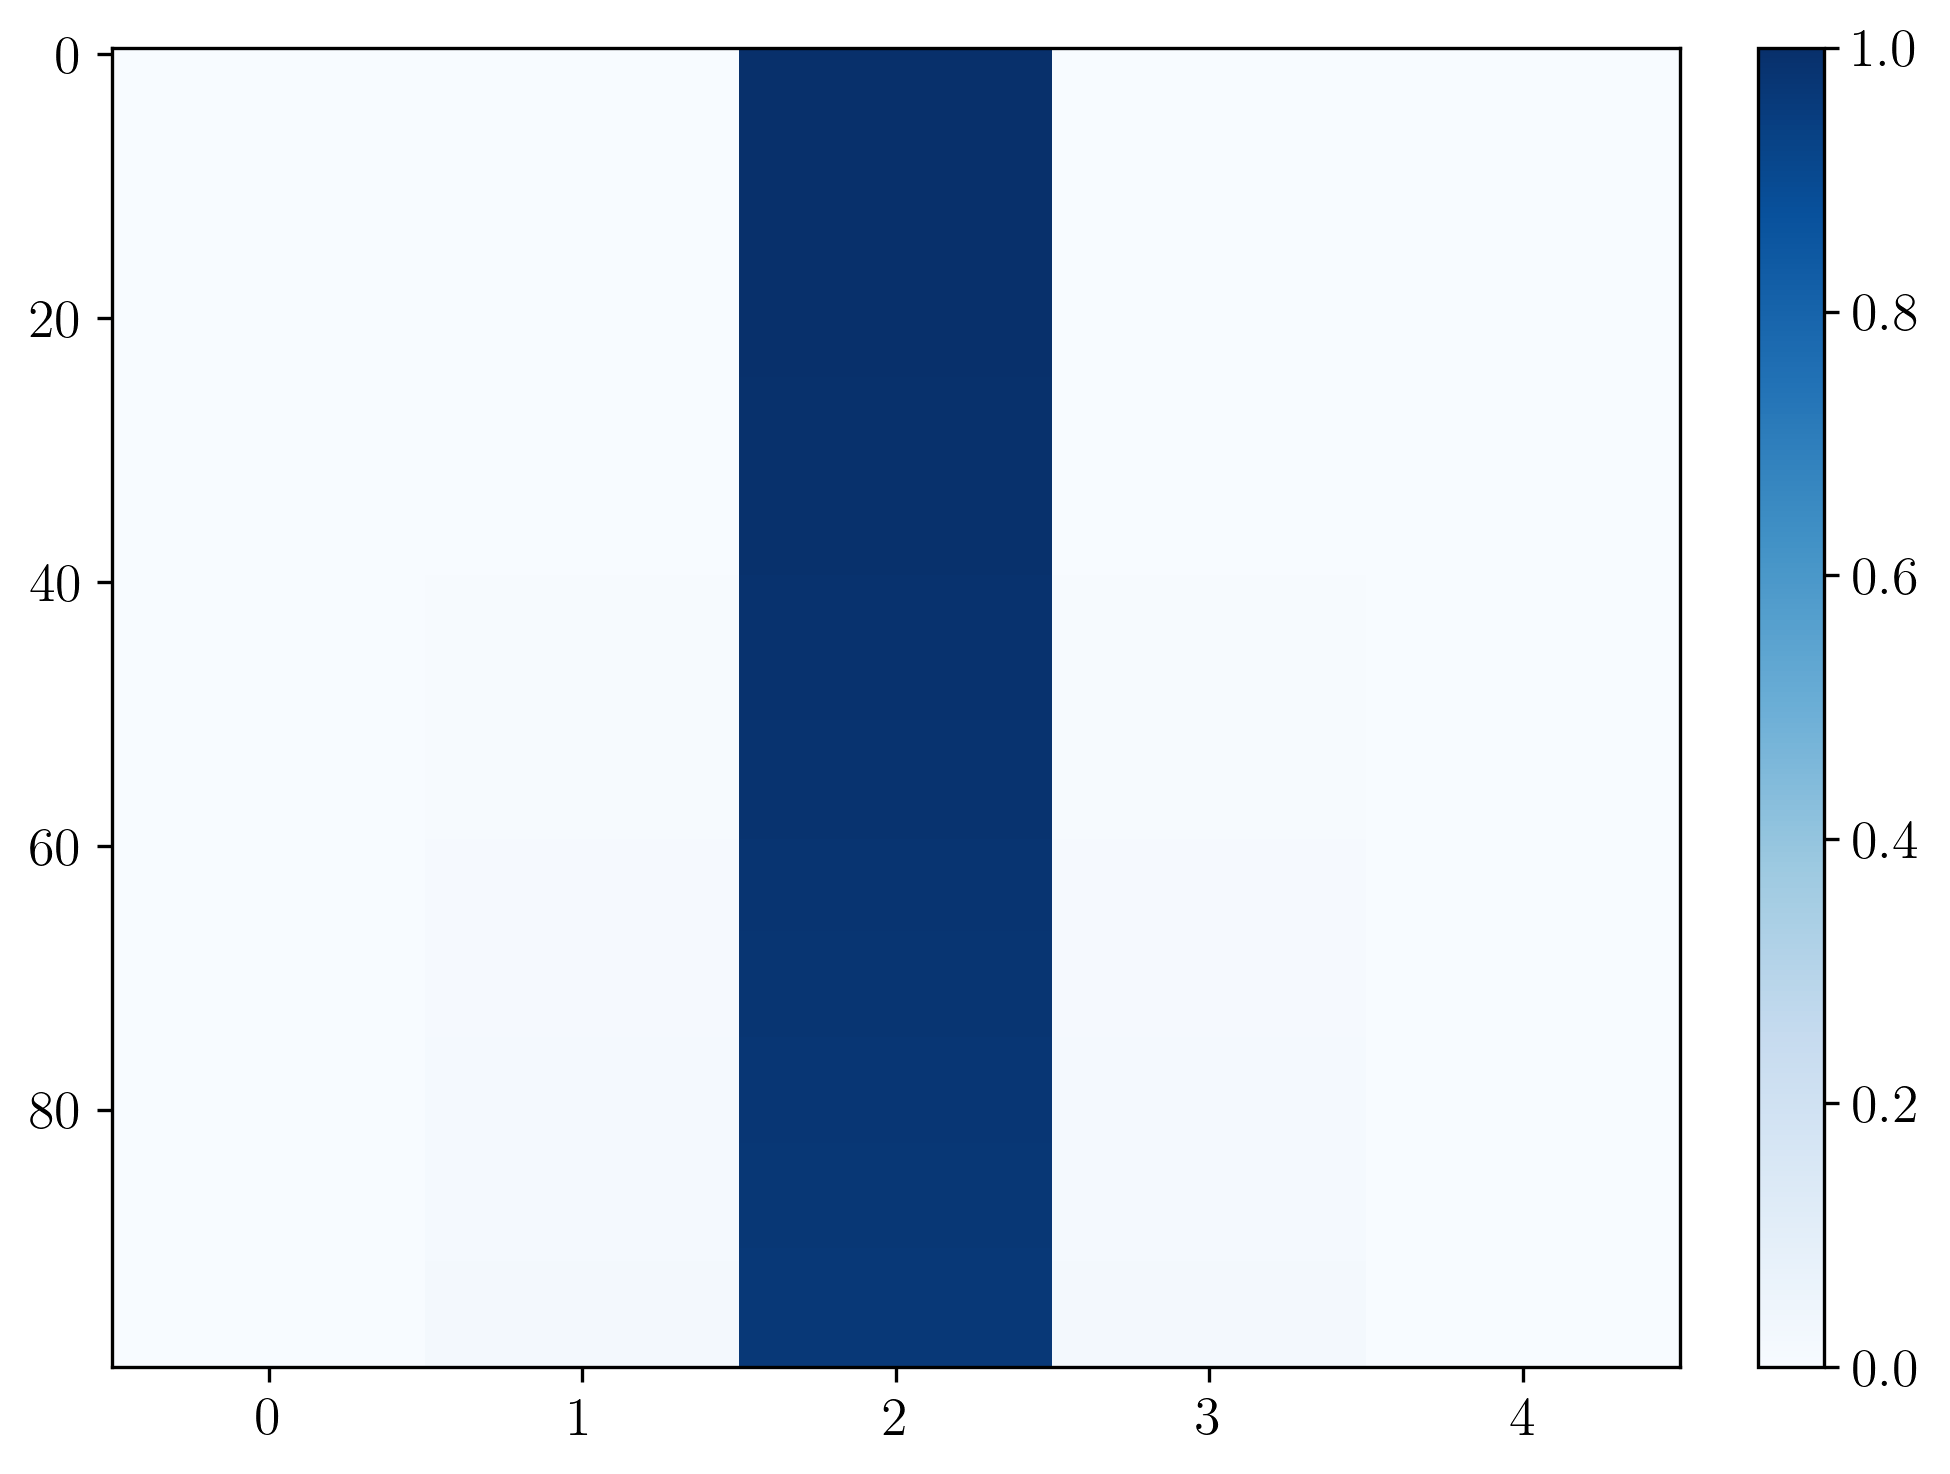

In [17]:
plt.imshow(np.asarray(occup_tot[0]), vmin=0, vmax=1, aspect='auto', cmap="Blues")
plt.colorbar()

## MPS

### test

In [18]:
half_chain_length = 2
t_up = 1
t_down = 1
Jz = 10
J_perp = 0
eps = 0
V = 0
trotter_steps = 100
final_time = 2

delta = trotter_steps/final_time

H_i_ip1 = Jz * kron(Sz, Sz) 
+ (J_perp/2) * kron(S_plus, S_minus)
+ (J_perp/2) * kron(S_minus, S_plus)
- (t_up) * kron(T_up_h, T_h_up)
- (t_up) * kron(T_h_up, T_up_h)
- (t_down) * kron(T_down_h, T_h_down)
- (t_down) * kron(T_h_down, T_down_h)

mat_ev_if = sp.linalg.expm(-1j * delta/2 * H_i_ip1.toarray())
mat_ev_bulk = sp.linalg.expm(-1j * delta * H_i_ip1.toarray())

In [19]:
op_ev_if = sp.linalg.expm(-1j * delta/2 * H_i_ip1.toarray())
op_ev_bulk = sp.linalg.expm(-1j * delta * H_i_ip1.toarray())

d = 3
schmidt_tol = 1e-15

# op_ev_if = np.swapaxes(op_ev_if, axis1=1, axis2=2)
original_matrix = op_ev_if
scaled_matrix = original_matrix / np.max(np.abs(original_matrix))
lambda_ = 1e-15
regularized_matrix = scaled_matrix + lambda_ * np.eye(
    scaled_matrix.shape[0], scaled_matrix.shape[1]
)

op_ev_if = op_ev_if.reshape(d,d,d,d)
# op_ev_if = op_ev_if.transpose(0,2,1,3)
op_ev_if = np.swapaxes(op_ev_if,2,1)
op_ev_if = op_ev_if.reshape(d*d,d*d)
u, s, v = svd(op_ev_if, full_matrices=False)

# print(s)
# condition = s >= schmidt_tol
# s_trunc = np.extract(condition, s)
# s = s_trunc / norm(s_trunc)

# print(s)

u = u[:, :len(s)]
site_i_if = u.reshape(d,d,len(s))
print(site_i_if.shape)
# site_i_if = site_i_if.transpose(2,0,1)
site_i_if = np.swapaxes(site_i_if, axis1=0, axis2=2)
print(site_i_if.shape)
site_i_if = np.swapaxes(site_i_if, axis1=1, axis2=2)
print(site_i_if.shape)
site_i_if = site_i_if[None,:,:,:]
print(site_i_if.shape)
# site_i_if = site_i_if.reshape(1,u.shape[1],d,d)
# site_i_if = site_i_if[:,:len(s),:,:]

print("\n---------")
v = v[:len(s),:]
site_ip1_if = ncon([np.diag(s), v],[[-1, 1],[1, -2]]).reshape(len(s),d,d)
print(site_ip1_if.shape)
site_ip1_if = site_ip1_if[:,:,:,None]
print(site_ip1_if.shape)
site_ip1_if = site_ip1_if.transpose(0,3,1,2)
print(site_ip1_if.shape)
# site_ip1_if = site_ip1_if.reshape(1,v.shape[0],d,d)
# site_ip1_if = np.swapaxes(site_ip1_if, axis1=0, axis2=1)


# op_ev_bulk = op_ev_bulk.reshape(d,d,d,d)
# op_ev_bulk = np.swapaxes(op_ev_bulk, axis1=1, axis2=2)
# op_ev_bulk = op_ev_bulk.reshape(d*d,d*d)

op_ev_bulk = op_ev_bulk.reshape(d,d,d,d)
op_ev_bulk = op_ev_bulk.transpose(0,2,1,3)
op_ev_bulk = op_ev_bulk.reshape(d*d,d*d)

# original_matrix = op_ev_bulk
# scaled_matrix = original_matrix / np.max(np.abs(original_matrix))
# lambda_ = 1e-10
# regularized_matrix = scaled_matrix + lambda_ * np.eye(
#     scaled_matrix.shape[0], scaled_matrix.shape[1]
# )
u, s, v = svd(op_ev_bulk, full_matrices=False)

# print(s)
# condition = s >= schmidt_tol
# s_trunc = np.extract(condition, s)
# s = s_trunc / norm(s_trunc)

print(s)

u = u[:, :len(s)]
site_i_b = u.reshape(d,d,len(s))
print(site_i_b.shape)
site_i_b = site_i_b.transpose(2,0,1)
print(site_i_b.shape)
site_i_b = site_i_b[None,:,:,:]
print(site_i_b.shape)

# site_i_b = u.reshape(d,d,u.shape[1])
# site_i_b = np.swapaxes(site_i_b, axis1=2, axis2=0)
# site_i_b = site_i_b.reshape(1,u.shape[1],d,d)
# site_i_b = site_i_b[:,:len(s),:,:]

v = v[:len(s),:]
site_ip1_b = ncon([np.diag(s), v],[[-1, 1],[1, -2]]).reshape(len(s),d,d)
print(site_ip1_b.shape)
site_ip1_b = site_ip1_b[:,:,:,None]
print(site_ip1_b.shape)
site_ip1_b = site_ip1_b.transpose(0,3,1,2)
print(site_ip1_b.shape)

# site_ip1_b = ncon([np.diag(s), v],[[-1, 1],[1, -2]]).reshape(v.shape[0],d,d)
# site_ip1_b = site_ip1_b.reshape(1,v.shape[0],d,d)
# site_ip1_b = np.swapaxes(site_ip1_b, axis1=0, axis2=1)

(3, 3, 9)
(9, 3, 3)
(9, 3, 3)
(1, 9, 3, 3)

---------
(9, 3, 3)
(9, 3, 3, 1)
(9, 1, 3, 3)
[2.73089837e+00 1.23208092e+00 1.55469343e-01 3.82453817e-17
 6.22012615e-33 5.93749578e-34 0.00000000e+00 0.00000000e+00
 0.00000000e+00]
(3, 3, 9)
(9, 3, 3)
(1, 9, 3, 3)
(9, 3, 3)
(9, 3, 3, 1)
(9, 1, 3, 3)


In [20]:
op_rec_if = ncon([site_i_if,site_ip1_if],[[-1,1,-3,-5],[1,-2,-4,-6]]).reshape((1,1,d*d,d*d))
mat_rec_if = op_rec_if[0,0,:,:]
print(mat_rec_if.shape)
i = 4
mat_rec_if[i], mat_ev_if[i]

(9, 9)


(array([-2.44348554e-034+9.34930118e-035j,
        -2.67964888e-050+8.01868925e-051j,
        -2.31968254e-082-1.26186174e-082j,
        -2.31840957e-048+6.69637346e-049j,
         1.00000000e+000+3.36722052e-017j,
         5.71732905e-101-2.38842526e-099j,
         1.16747705e-082-6.11169062e-083j,
         1.33661083e-113-1.52611618e-113j,
         2.19258302e-067-1.16651898e-066j]),
 array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
        0.+0.j]))

In [21]:
def U_i_ip1_tJ(Jz, t_up, t_down, J_perp, delta):
    """
    U_i_ip1

    This function computes the exponential of the 2-site hamiltonian for the t-J model.
    It returns to versions: 
    1. one with a time step delta/2 to use at the initial and final step
    of the trotterization
    2. one with a time step delta to use in the bulk steps of the trotterization

    """

    # choose the hamiltonian parameters
    H_i_ip1 = (Jz * kron(Sz, Sz) 
    + (J_perp/2) * kron(S_plus, S_minus) 
    + (J_perp/2) * kron(S_minus, S_plus) 
    - (t_up) * kron(T_up_h, T_h_up) 
    - (t_up) * kron(T_h_up, T_up_h) 
    - (t_down) * kron(T_down_h, T_h_down) 
    - (t_down) * kron(T_h_down, T_down_h)).toarray()

    # initial and final 2-site evolution operator
    op_ev_if = sp.linalg.expm(-1j * delta/2 * H_i_ip1)

    # bulk 2-site evolution operator
    op_ev_bulk = sp.linalg.expm(-1j * delta * H_i_ip1)
    
    return op_ev_if, op_ev_bulk

def evolution_mpo_svd_tJ(op_ev_if: np.ndarray, op_ev_bulk: np.ndarray, d: int=3, schmidt_tol: float=1e-15, trunc: bool=False):
    """
    evolution_mpo_svd

    This function takes the edges, and bulk 2-site evolution operators (of the t-J model) and performs an svd
    to separate the matrix into site i and site i+1. Reshaping the results of the svd
    we can obtain the mpo for those evolution operators (with bounded bond dimension D<=d^2)

    """
    op_ev_if = op_ev_if.reshape(d,d,d,d)
    op_ev_if = op_ev_if.transpose(0,2,1,3)
    op_ev_if = op_ev_if.reshape(d*d,d*d)

    u, s, v = svd(op_ev_if, full_matrices=False)

    if trunc:
        condition = s >= schmidt_tol
        s_trunc = np.extract(condition, s)
        s = s_trunc
        v = v[:len(s),:]

    site_i_if = u.reshape(d,d,u.shape[1])
    site_i_if = site_i_if[:, :, :len(s)]
    site_i_if = site_i_if.transpose(2,0,1)
    site_i_if = site_i_if.reshape(1,len(s),d,d)

    site_ip1_if = ncon([np.diag(s), v],[[-1, 1],[1, -2]]).reshape(v.shape[0],d,d)
    site_ip1_if = site_ip1_if.reshape(1,v.shape[0],d,d)
    site_ip1_if = site_ip1_if.transpose(1,0,2,3)


    op_ev_bulk = op_ev_bulk.reshape(d,d,d,d)
    op_ev_bulk = op_ev_bulk.transpose(0,2,1,3)
    op_ev_bulk = op_ev_bulk.reshape(d*d,d*d)

    u, s, v = svd(op_ev_bulk, full_matrices=False)

    if trunc:
        condition = s >= schmidt_tol
        s_trunc = np.extract(condition, s)
        s = s_trunc
        v = v[:len(s),:]

    site_i_b = u.reshape(d,d,u.shape[1])
    site_i_b = site_i_b[:, :, :len(s)]
    site_i_b = site_i_b.transpose(2,0,1)
    site_i_b = site_i_b.reshape(1,len(s),d,d)

    site_ip1_b = ncon([np.diag(s), v],[[-1, 1],[1, -2]]).reshape(v.shape[0],d,d)
    site_ip1_b = site_ip1_b.reshape(1,v.shape[0],d,d)
    site_ip1_b = site_ip1_b.transpose(1,0,2,3)

    tol = 1e-15 * np.max(np.abs(site_i_if))
    site_i_if.real[np.abs(site_i_if.real) < tol] = 0
    site_i_if.imag[np.abs(site_i_if.imag) < tol] = 0
    
    tol = 1e-15 * np.max(np.abs(site_ip1_if))
    site_ip1_if.real[np.abs(site_ip1_if.real) < tol] = 0
    site_ip1_if.imag[np.abs(site_ip1_if.imag) < tol] = 0
    
    tol = 1e-15 * np.max(np.abs(site_i_b))
    site_i_b.real[np.abs(site_i_b.real) < tol] = 0
    site_i_b.imag[np.abs(site_i_b.imag) < tol] = 0
    
    tol = 1e-15 * np.max(np.abs(site_ip1_b))
    site_ip1_b.real[np.abs(site_ip1_b.real) < tol] = 0
    site_ip1_b.imag[np.abs(site_ip1_b.imag) < tol] = 0

    return site_i_if, site_ip1_if, site_i_b, site_ip1_b

def evolution_mpo_step_tJ(n, site_i_if, site_ip1_if, site_i_b, site_ip1_b):
    """
    evolution_mpo_start_tJ

    This function finds the starting evolution mpo for a chain n of the t-J model.
    It is the first step of a second order trotterization.

    """
    # first site has one tensor only
    mpo_id = Id.reshape((1,1,3,3))
    mpo_start = ncon([site_i_if, mpo_id, site_i_if],[[-1,-4,-7,1],[-2,-5,1,2],[-3,-6,2,-8]]).reshape((site_i_if.shape[0]**2,site_i_if.shape[1]**2, 3, 3))
    # two bulk operators for even and odd sites
    mpo_bulk_odd = ncon([site_ip1_if, site_i_b, site_ip1_if],[[-1,-4,-7,1],[-2,-5,1,2],[-3,-6,2,-8]]).reshape((site_ip1_if.shape[0]**2*site_i_b.shape[0],site_ip1_if.shape[1]**2*site_i_b.shape[1], 3, 3))
    mpo_bulk_even = ncon([site_i_if, site_ip1_b, site_i_if],[[-1,-4,-7,1],[-2,-5,1,2],[-3,-6,2,-8]]).reshape((site_i_if.shape[0]**2*site_ip1_b.shape[0],site_i_if.shape[1]**2*site_ip1_b.shape[1], 3, 3))
    # two last-site operators depending on the parity of the chain
    mpo_end_n_odd = ncon([mpo_id, site_ip1_b, mpo_id],[[-1,-4,-7,1],[-2,-5,1,2],[-3,-6,2,-8]]).reshape((mpo_id.shape[0]**2*site_ip1_b.shape[0],mpo_id.shape[1]**2*site_ip1_b.shape[1], 3, 3)) # for odd chains
    mpo_end_n_even = ncon([site_ip1_if, mpo_id, site_ip1_if],[[-1,-4,-7,1],[-2,-5,1,2],[-3,-6,2,-8]]).reshape((site_ip1_if.shape[0]**2*mpo_id.shape[0],site_ip1_if.shape[1]**2*mpo_id.shape[1], 3, 3)) # for even chains
 
    mpo_step = []
    
    # left op
    mpo_step.append(mpo_start)
    
    # bulk ops
    for i in range(1,n-1):
        if (i%2) == 0:
            mpo_step.append(mpo_bulk_even)
        elif (i%2) == 1:
            mpo_step.append(mpo_bulk_odd)
    
    # right op
    if (n%2) == 0:
        mpo_step.append(mpo_end_n_even)
    elif (n%2) == 1:
        mpo_step.append(mpo_end_n_odd)
    
    return mpo_step

def evolution_mpo_start_tJ(n, site_i_if, site_ip1_if, site_i_b, site_ip1_b):
    """
    evolution_mpo_start_tJ

    This function finds the starting evolution mpo for a chain n of the t-J model.
    It is the first step of a second order trotterization.

    """
    # first site has one tensor only
    mpo_start_left = site_i_if.copy()
    # two bulk operators for even and odd sites
    mpo_start_bulk_odd = ncon([site_ip1_if, site_i_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_ip1_if.shape[0]*site_i_b.shape[0],site_ip1_if.shape[1]*site_i_b.shape[1],site_ip1_if.shape[2], site_i_b.shape[3]))
    mpo_start_bulk_even = ncon([site_i_if, site_ip1_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_i_if.shape[0]*site_ip1_b.shape[0],site_i_if.shape[1]*site_ip1_b.shape[1],site_i_if.shape[2], site_ip1_b.shape[3]))
    # two last-site operators depending on the parity of the chain
    mpo_start_right_b = site_ip1_b.copy() # for odd chains
    mpo_start_right_if = site_ip1_if.copy() # for even chains

    mpo_start = []
    
    # left op
    mpo_start.append(mpo_start_left)
    
    # bulk ops
    for i in range(1,n-1):
        if (i%2) == 0:
            mpo_start.append(mpo_start_bulk_even)
        elif (i%2) == 1:
            mpo_start.append(mpo_start_bulk_odd)
    
    # right op
    if (n%2) == 0:
        mpo_start.append(mpo_start_right_if)
    elif (n%2) == 1:
        mpo_start.append(mpo_start_right_b)
    
    return mpo_start


def evolution_mpo_ev_tJ(n, site_i_b, site_ip1_b):
    """
    evolution_mpo_ev_tJ

    This function finds the bulk evolution mpo for a chain n of the t-J model.
    The mpo found can be used in all the steps of a second order trotterization
    after the starting step and before the last step.

    """
    # first site has one tensor only
    mpo_ev_left = site_i_b.copy()
    # two bulk operators for even and odd sites
    mpo_ev_bulk_odd = ncon([site_ip1_b, site_i_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_ip1_b.shape[0]*site_i_b.shape[0],site_ip1_b.shape[1]*site_i_b.shape[1],site_ip1_b.shape[2], site_i_b.shape[3]))
    mpo_ev_bulk_even = ncon([site_i_b, site_ip1_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_i_b.shape[0]*site_ip1_b.shape[0],site_i_b.shape[1]*site_ip1_b.shape[1],site_i_b.shape[2], site_ip1_b.shape[3]))
    # last site has one tensor only
    mpo_ev_right = site_ip1_b.copy()

    mpo_ev = []
    
    # left op
    mpo_ev.append(mpo_ev_left)
    
    # bulk ops
    for i in range(1,n-1):
        if (i%2) == 0:
            mpo_ev.append(mpo_ev_bulk_even)
        elif (i%2) == 1:
            mpo_ev.append(mpo_ev_bulk_odd)

    # right op
    mpo_ev.append(mpo_ev_right)
    
    return mpo_ev

def evolution_mpo_end_tJ(n, site_i_if, site_ip1_if):
    """
    evolution_mpo_end_tJ

    This function finds the ending evolution mpo for a chain n of the t-J model.
    It is the last step of a second order trotterization.

    """
    # both even and odd sites have one tensor only
    mpo_end_even = site_i_if.copy()
    mpo_end_odd = site_ip1_if.copy()

    mpo_end = []
    
    # bulk ops
    for i in range(n-1):
        if (i%2) == 0:
            mpo_end.append(mpo_end_even)
        elif (i%2) == 1:
            mpo_end.append(mpo_end_odd)
    
    # right op
    if (n%2) == 0:
        mpo_end.append(mpo_end_odd)
    elif (n%2) == 1:
        mpo_end.append(Id.reshape((1,1,3,3)))
    
    return mpo_end


In [22]:
half_chain_length = 2
t_up = 2
t_down = 2
Jz = 10
J_perp = 0
eps = 0
V = 0
trotter_steps = 100
final_time = 2
delta = final_time / trotter_steps

In [23]:
# spin_up = np.array([1,0,0])
# hole = np.array([0,1,0])
# spin_down = np.array([0,0,1])

# psi_init = kron(spin_down, kron(spin_up, kron(spin_down, kron(hole, kron(hole, kron(spin_up, kron(spin_down, spin_up))))))).T.toarray()
# psi_init = psi_init.reshape((3**(2*half_chain_length + 2)))

n = 2*half_chain_length + 1

op_ev_if, op_ev_bulk = U_i_ip1_tJ(Jz, t_up, t_down, J_perp, delta)
site_i_if, site_ip1_if, site_i_b, site_ip1_b = evolution_mpo_svd_tJ(op_ev_if, op_ev_bulk)
mpo_step = evolution_mpo_step_tJ(n, site_i_if, site_ip1_if, site_i_b, site_ip1_b)

U_step = mpo_to_matrix(mpo_step)

In [24]:
H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, n_holes=1)

psi_ev = psi_init.copy()

obs = ['h_loc', 'm_loc']
ops_h = local_hole_occupation(n)
ops_m = local_mag_occupation(n)

occup_tot_h = []
occup_tot_m = []
fidelity = []

for t in range(trotter_steps):
    print(f"trotter step: {t}")
    
    psi_ev = U_step @ psi_ev

    if 'h_loc' in obs:
        occup = []
        for op in ops_h:
            occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
            # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
        occup_tot_h.append(occup)

    if 'm_loc' in obs:
        occup = []
        for op in ops_m:
            occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
            # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
        occup_tot_m.append(occup)
    
    fidelity.append(abs(psi_ev.conjugate().T @ psi_save[t]))


trotter step: 0
trotter step: 1
trotter step: 2
trotter step: 3
trotter step: 4
trotter step: 5
trotter step: 6
trotter step: 7
trotter step: 8
trotter step: 9
trotter step: 10
trotter step: 11
trotter step: 12
trotter step: 13
trotter step: 14
trotter step: 15
trotter step: 16
trotter step: 17
trotter step: 18
trotter step: 19
trotter step: 20
trotter step: 21
trotter step: 22
trotter step: 23
trotter step: 24
trotter step: 25
trotter step: 26
trotter step: 27
trotter step: 28
trotter step: 29
trotter step: 30
trotter step: 31
trotter step: 32
trotter step: 33
trotter step: 34
trotter step: 35
trotter step: 36
trotter step: 37
trotter step: 38
trotter step: 39
trotter step: 40
trotter step: 41
trotter step: 42
trotter step: 43
trotter step: 44
trotter step: 45
trotter step: 46
trotter step: 47
trotter step: 48
trotter step: 49
trotter step: 50
trotter step: 51
trotter step: 52
trotter step: 53
trotter step: 54
trotter step: 55
trotter step: 56
trotter step: 57
trotter step: 58
trotter

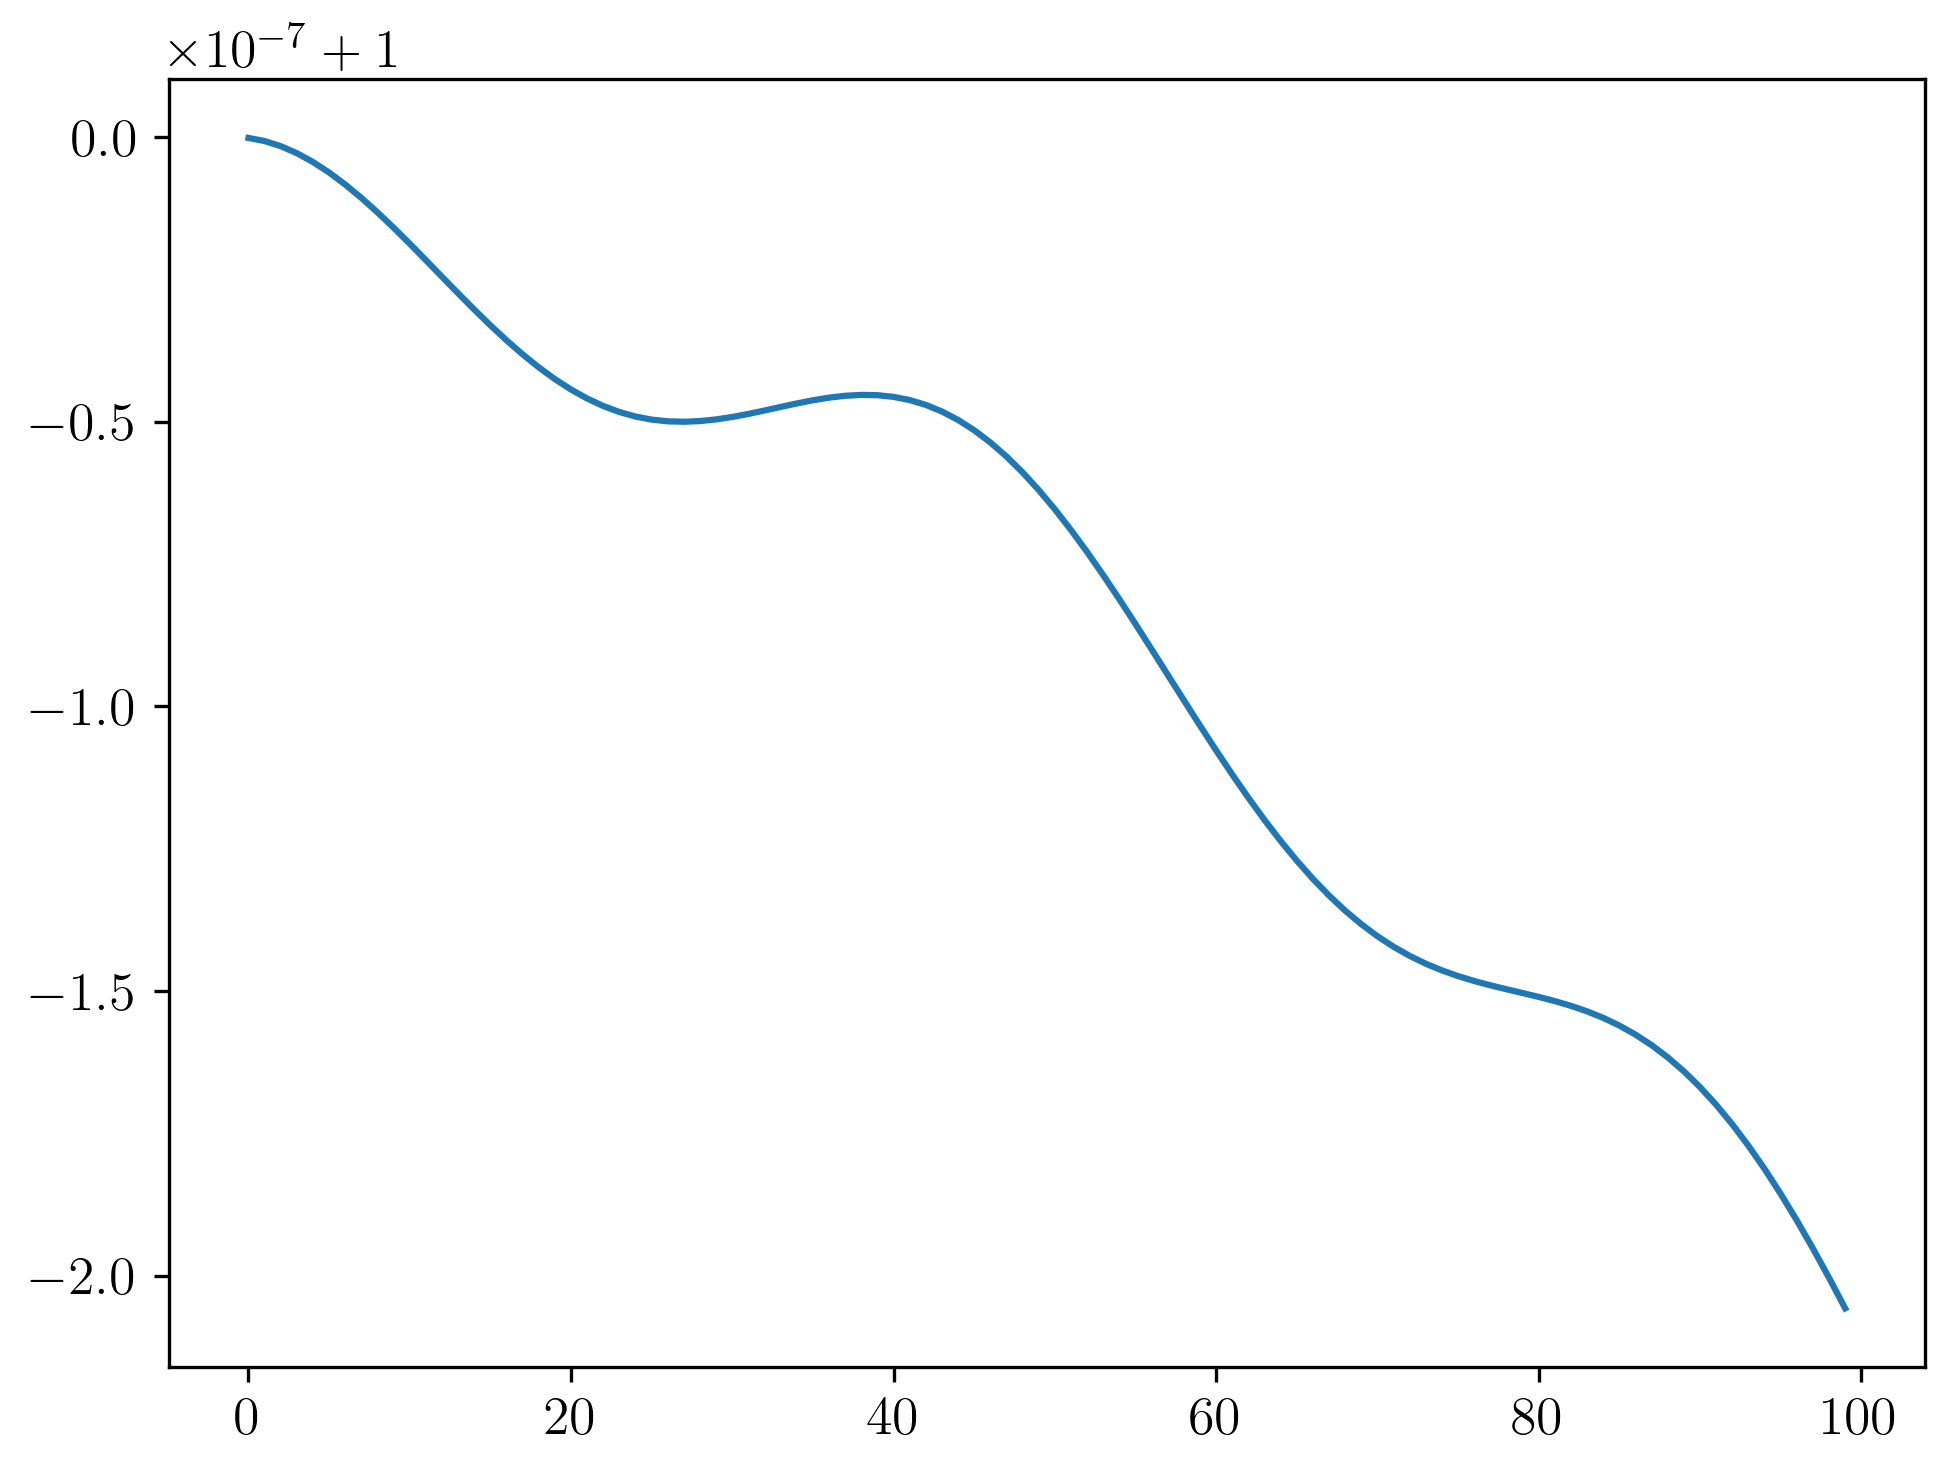

In [25]:
plt.plot(fidelity)

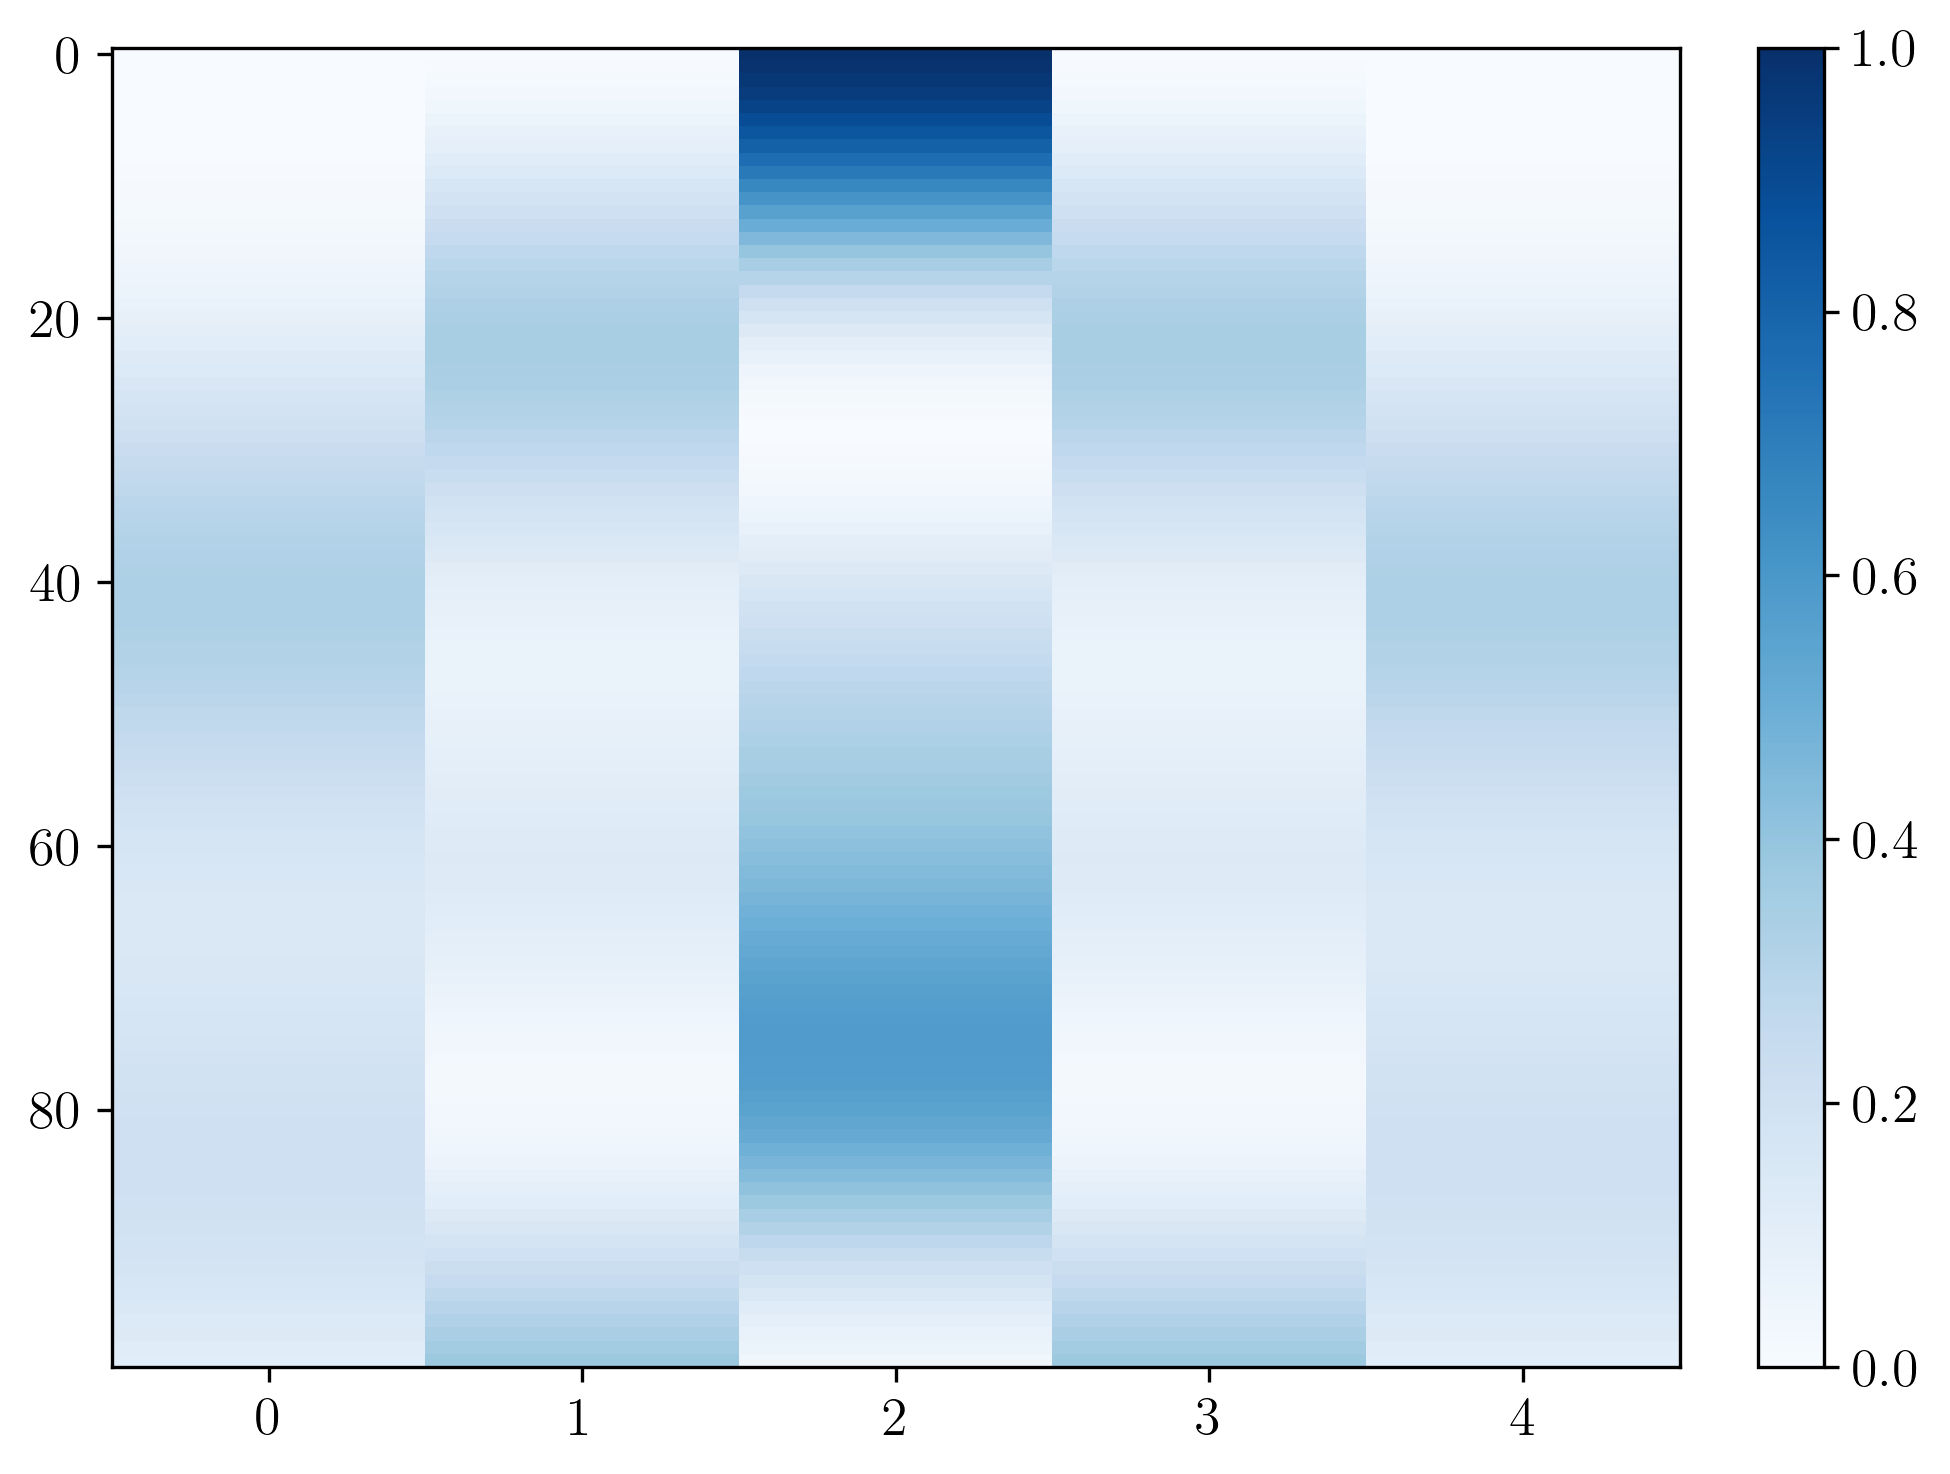

In [26]:
plt.imshow(np.asarray(occup_tot_h), vmin=0, vmax=1, aspect='auto', cmap="Blues")
plt.colorbar()

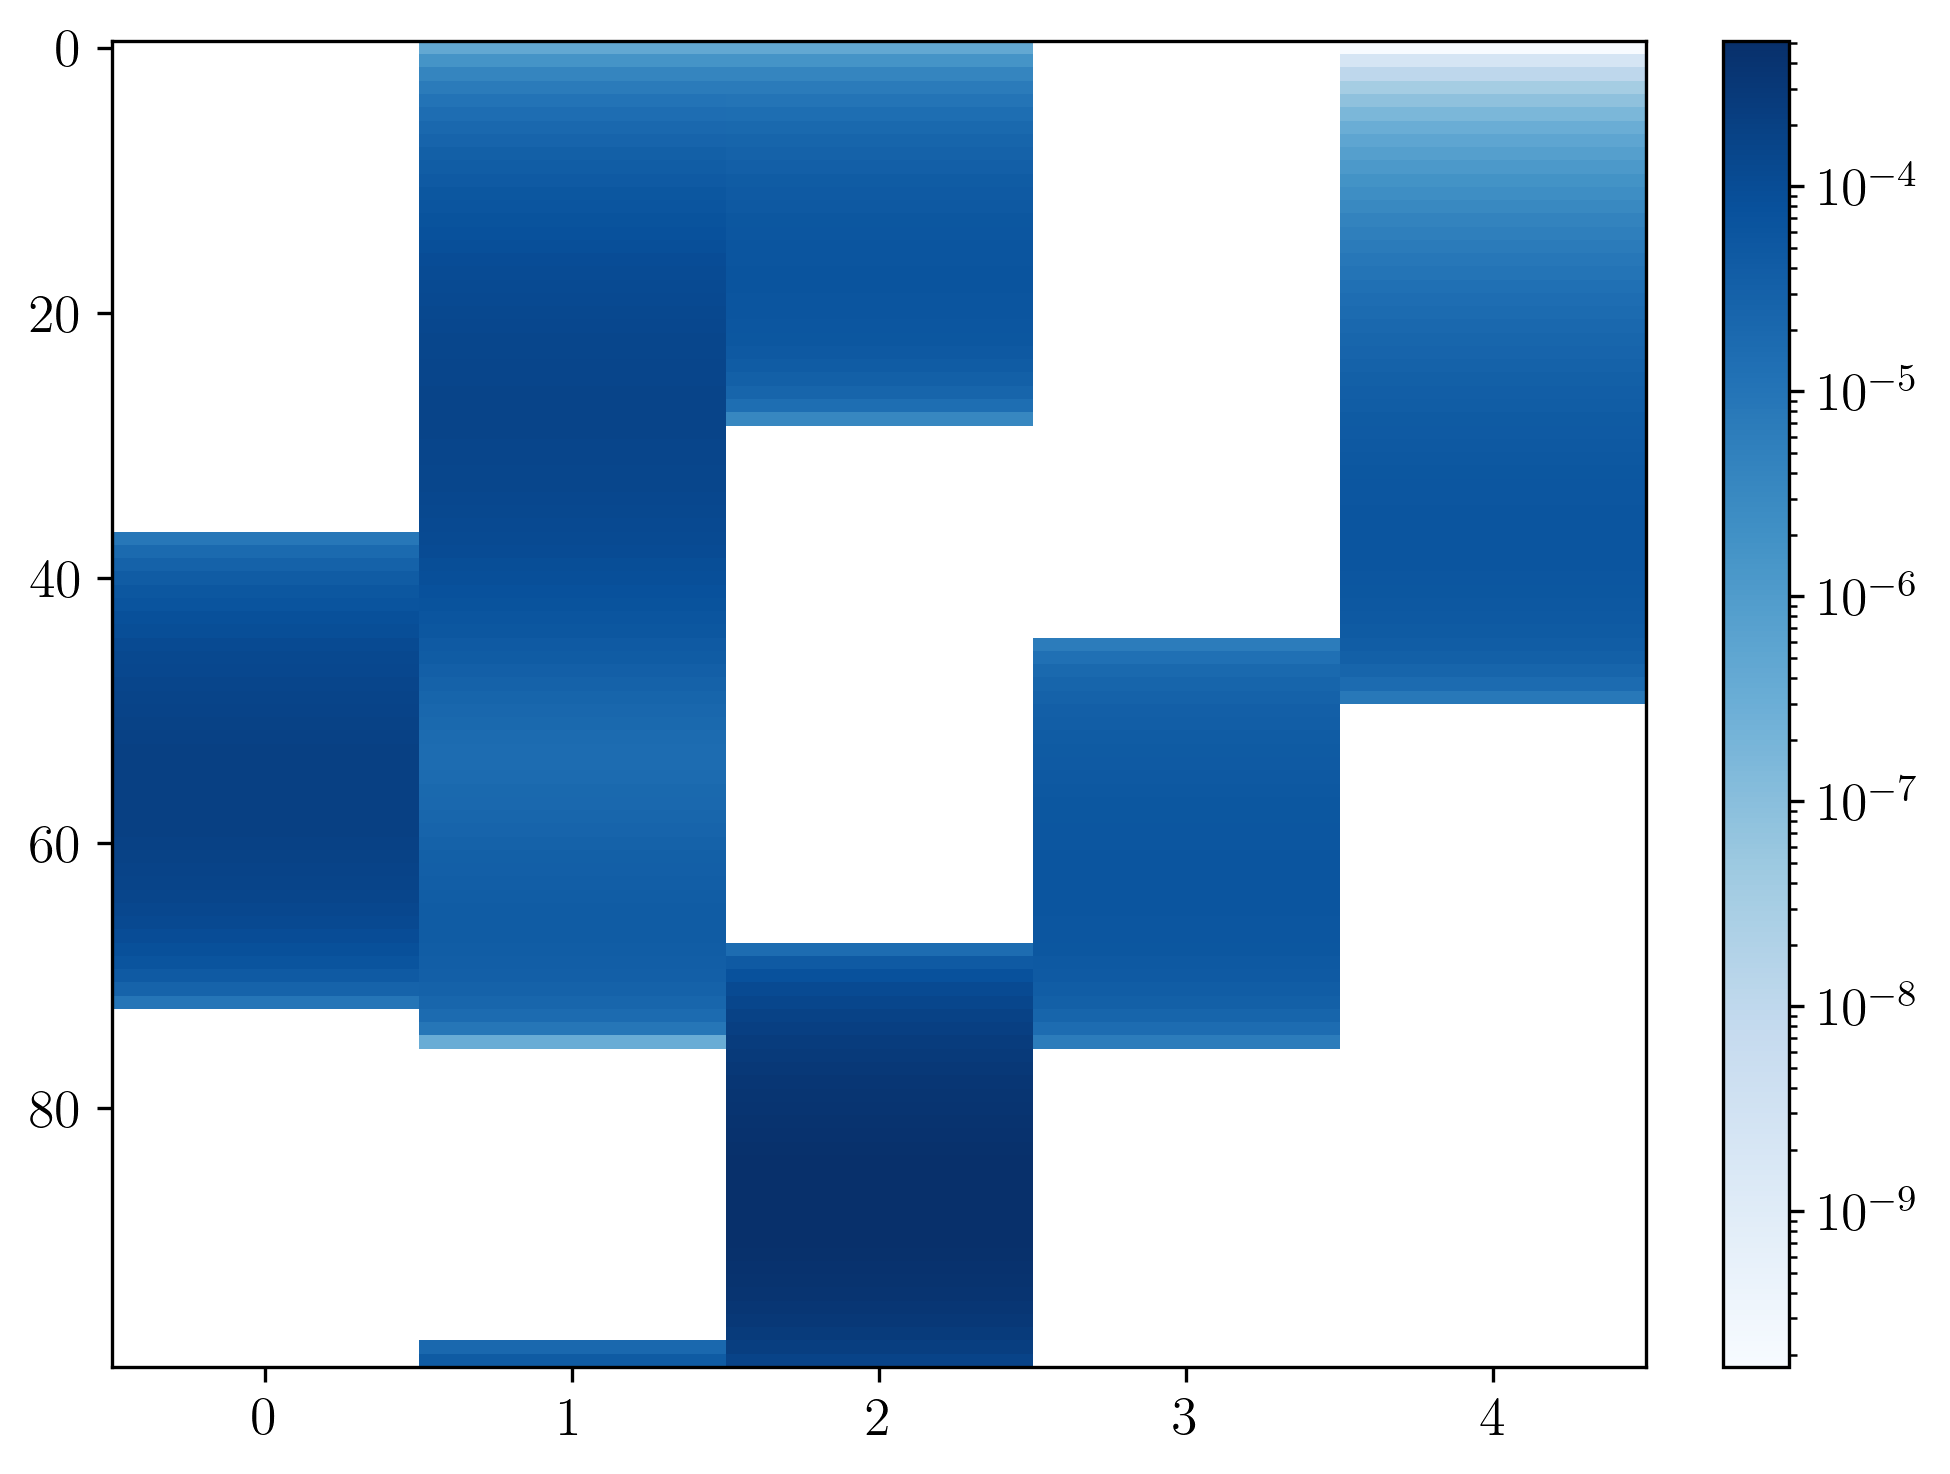

In [27]:
plt.imshow(np.asarray(occup_tot_h)-np.asarray(exp_vals[0]), aspect='auto', cmap="Blues", norm="log")
plt.colorbar()

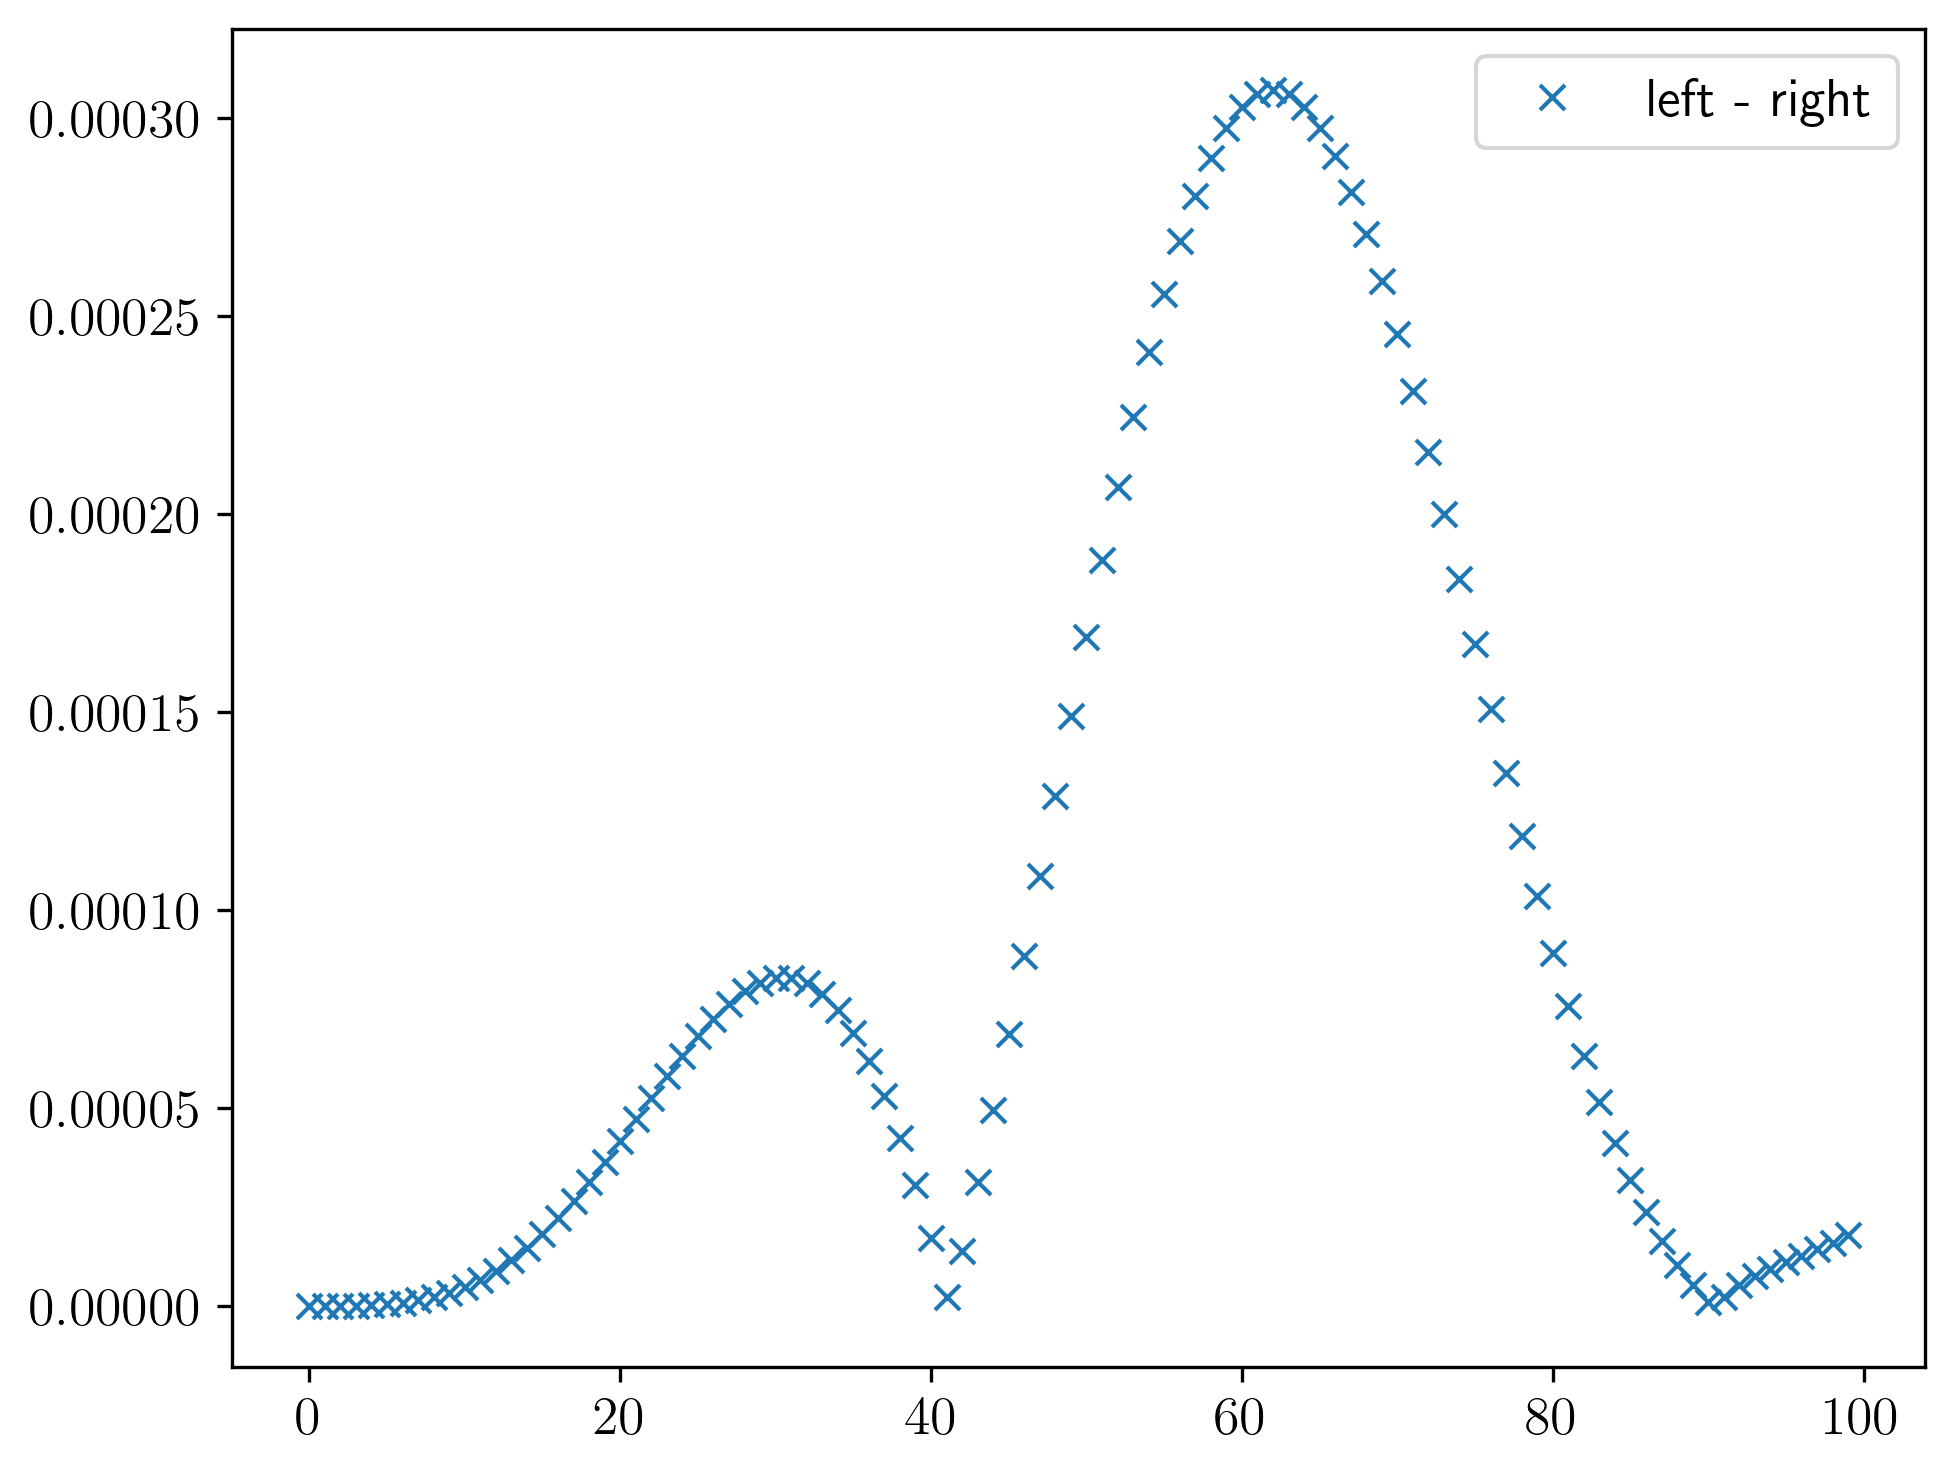

In [28]:
plt.plot(np.abs(np.asarray(occup_tot_h)[:,0] - np.asarray(occup_tot_h)[:,4]),'x', label='left - right')
plt.legend()

In [29]:
Jz = 10
t_up = 2
tdown = 2
final_time = 2
trotter_step = 100
J_perp = 0
delta = final_time/trotter_step
n = 5

In [30]:
def trotter(n, Jz, t_up, t_down, J_perp, delta):
    op_ev_delta_half, op_ev_delta = U_i_ip1_tJ(Jz, t_up, t_down, J_perp, delta)
    site_i_delta_half, site_ip1_delta_half, site_i_delta, site_ip1_delta = evolution_mpo_svd_tJ(op_ev_delta_half, op_ev_delta, d=3)
    mpo_ev_trotter = evolution_mpo_step_tJ(n, site_i_delta_half, site_ip1_delta_half, site_i_delta, site_ip1_delta)
    op_ev_trotter = mpo_to_matrix(mpo_ev_trotter)
    return op_ev_trotter

In [31]:
def exact(n, t_up, t_down, Jz, delta):
    H_ev = tJV_ham(n, t_up, t_down, Jz, 0, 0, 0)
    op_ev_exact = sp.linalg.expm(-1j * delta * H_ev)
    return op_ev_exact.toarray()

In [32]:
def error(Ue, Ut):
    return np.linalg.norm(Ue - Ut, ord='fro')

deltas = np.logspace(-3, -1, 10)
errors = []

for d in deltas:
    Ue = exact(n, t_up, t_down, Jz, d)
    Ut = trotter(n, Jz, t_up, t_down, J_perp, d)
    errors.append(error(Ue, Ut))

print(errors)
slope = np.polyfit(np.log(deltas), np.log(errors), 1)[0]
print("Scaling exponent:", slope)


c:\Users\HP\anaconda3\envs\mps\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:412: SparseEfficiencyWarning: splu converted its input to CSC format
  warn('splu converted its input to CSC format', SparseEfficiencyWarning)
c:\Users\HP\anaconda3\envs\mps\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:302: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  warn('spsolve is more efficient when sparse b '


[5.655603369711497e-08, 2.625092105701388e-07, 1.2184515039608244e-06, 5.655443485701425e-06, 2.624885614678366e-05, 0.00012181848351352546, 0.0005652000198424153, 0.0026204415731712317, 0.012124563810638, 0.05578416493718318]
Scaling exponent: 2.997997621134881


## full TEBD

In [33]:
spin_up_tn = np.array([1,0,0]).reshape((1,3,1))
hole_tn = np.array([0,1,0]).reshape((1,3,1))
spin_down_tn = np.array([0,0,1]).reshape((1,3,1))
L = 12

mps_chain = MPS(L=L, d=3, model='tj', chi=1)
init_state = [hole_tn]*(L//2 - 1) + [spin_up_tn]*2 + [hole_tn]*(L//2 - 1)
mps_chain.sites = init_state.copy()

loc_mag = []
for i in range(1,mps_chain.L+1):
    mps_chain.local_param(site=i, op="Z")
    loc_mag.append(mps_chain.mpo_first_moment().real)

loc_mag

[array(0.),
 array(0.),
 array(0.),
 array(0.),
 array(0.),
 array(1.),
 array(1.),
 array(0.),
 array(0.),
 array(0.),
 array(0.),
 array(0.)]

In [34]:
op_ev_delta_half, op_ev_delta = U_i_ip1_tJ(Jz, t_up, t_down, J_perp, delta)
site_i_delta_half, site_ip1_delta_half, site_i_delta, site_ip1_delta = evolution_mpo_svd_tJ(op_ev_delta_half, op_ev_delta, d=3)
mpo_ev_trotter = evolution_mpo_step_tJ(mps_chain.L, site_i_delta_half, site_ip1_delta_half, site_i_delta, site_ip1_delta)
mps_chain.w_dag = mpo_ev_trotter.copy()

In [35]:
(
errs,
entrs,
svs,
local_magnetization,
ovlps,
chi_sat,
        ) = mps_chain.TEBD_variational_tJ(trotter_steps=trotter_steps, where=mps_chain.L//2, chi_max=8, obs=['lm'])


*** Computing local magnetization in date: 2026-04-17 13:43:33.635625 ***

Total time for the local magnetization is: 0:00:00.075442

*** Starting the 0-th trotter step in date: 2026-04-17 13:43:33.711067 ***

Sweep n: 0

Sweep n: 1

##############################
The error between the two last updated states converged
to an order of 1e-08 after:
1 sweeps at site 11
total iterations 23
##############################
Bond dim ancilla: 8
Bond dim site: 8
Compress the ising evolution operator: 0:00:00.228155
Total time for the 0-th trotter step is: 0:00:00.228155
Computing observables for this trotter step

*** Computing local magnetization in date: 2026-04-17 13:43:33.939222 ***

Total time for the local magnetization is: 0:00:00.066641

*** Starting the 1-th trotter step in date: 2026-04-17 13:43:34.005863 ***

Sweep n: 0

Sweep n: 1

##############################
The error between the two last updated states converged
to an order of 1e-08 after:
1 sweeps at site 11
total iterations 2

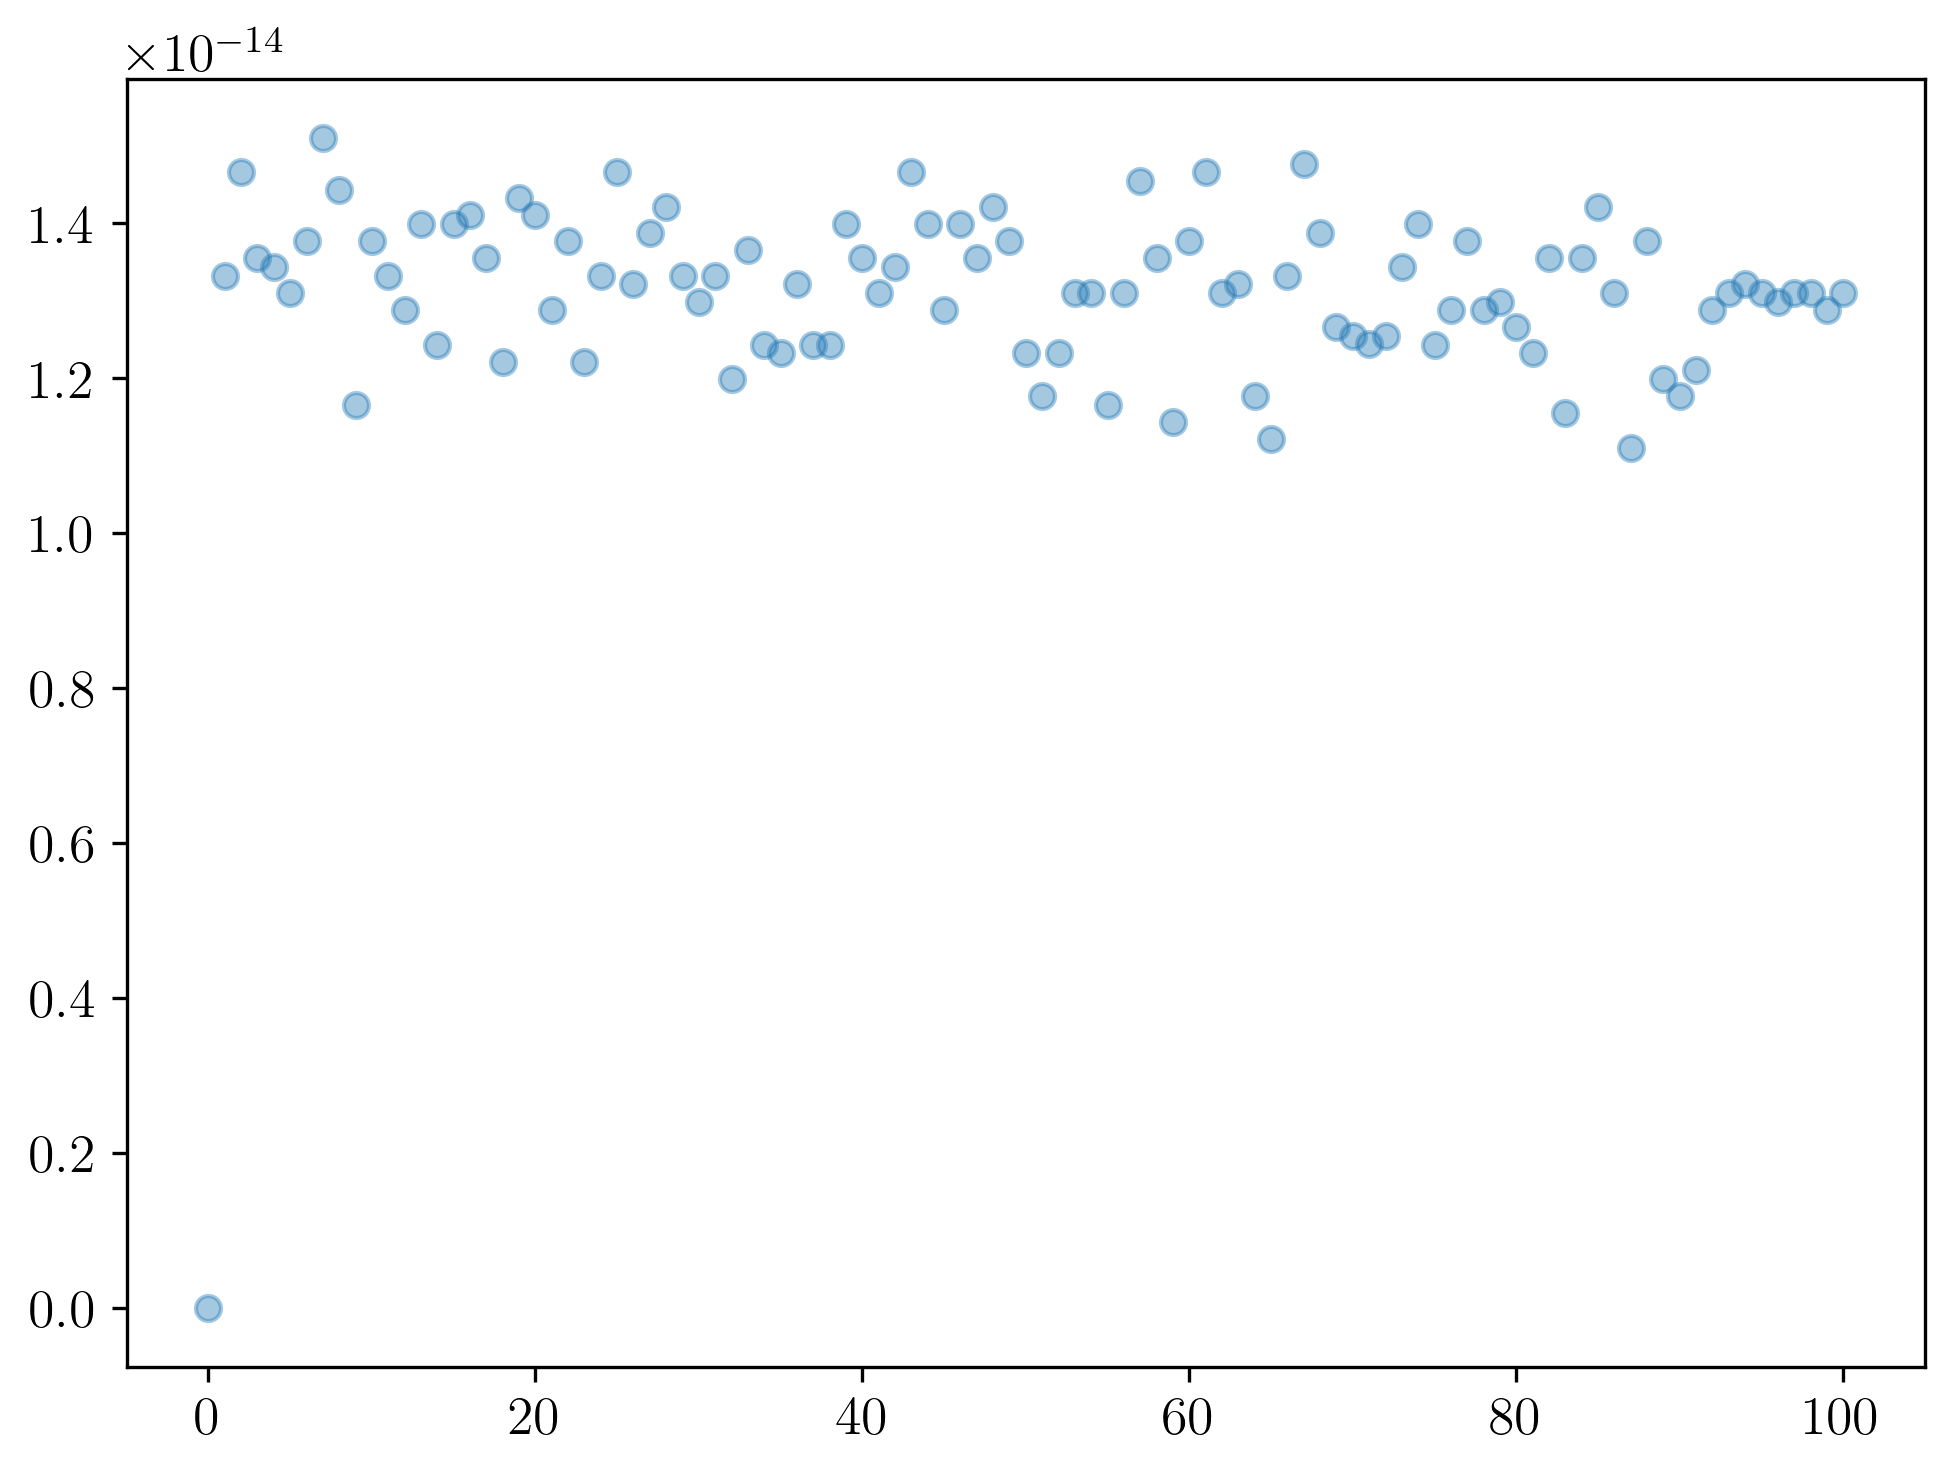

In [36]:
plt.plot(errs, 'o', alpha=0.4)

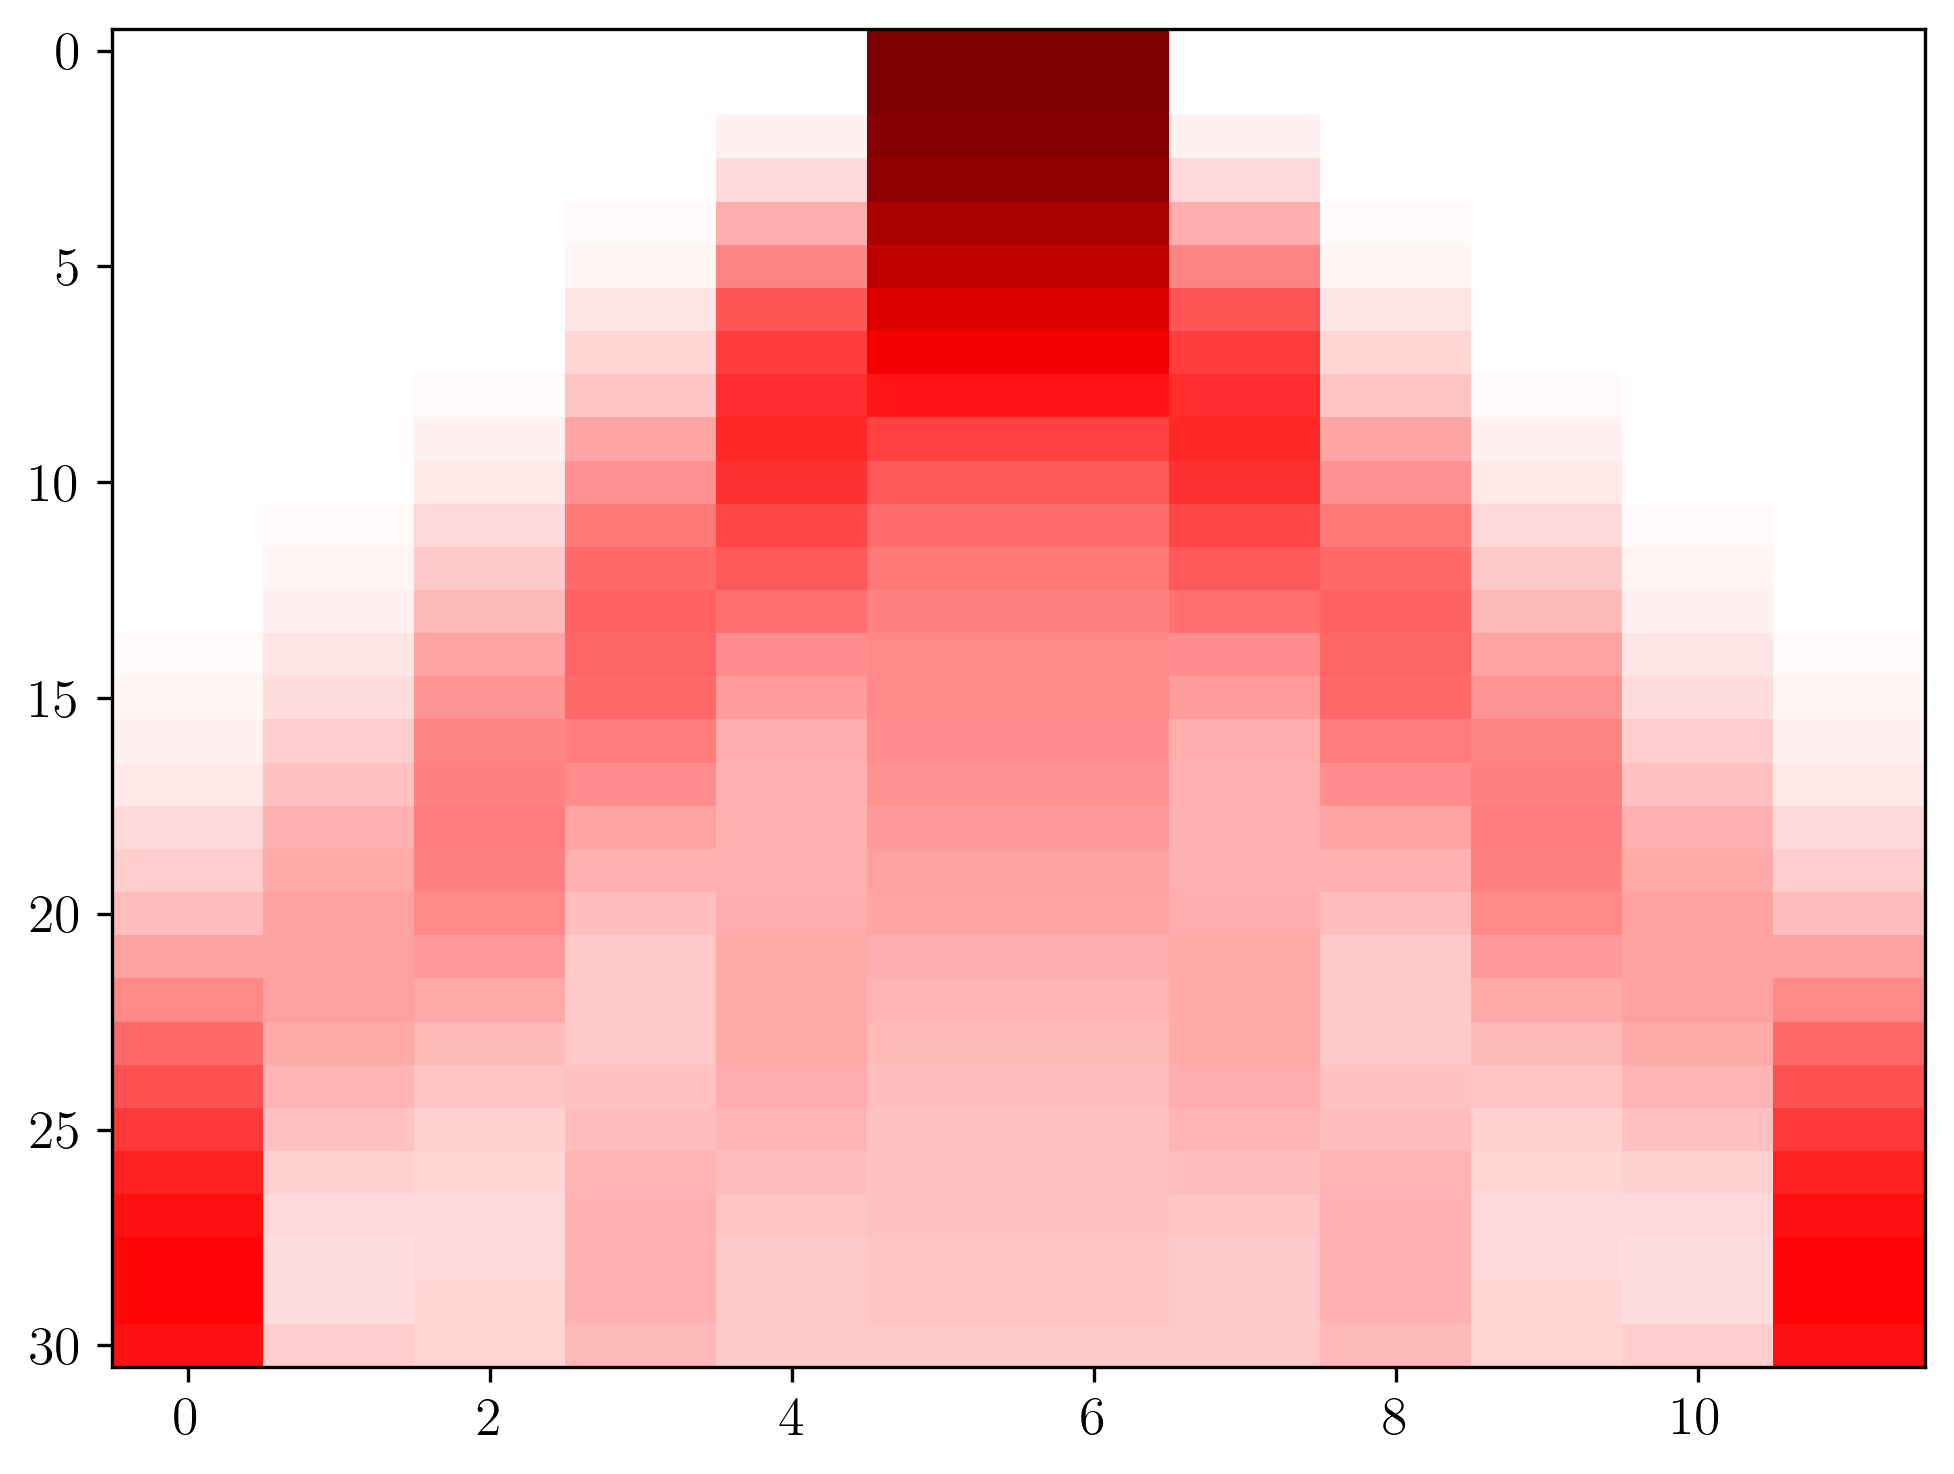

In [37]:
plt.imshow(np.asarray(local_magnetization), vmin=-1, vmax=1, aspect='auto', cmap='seismic')

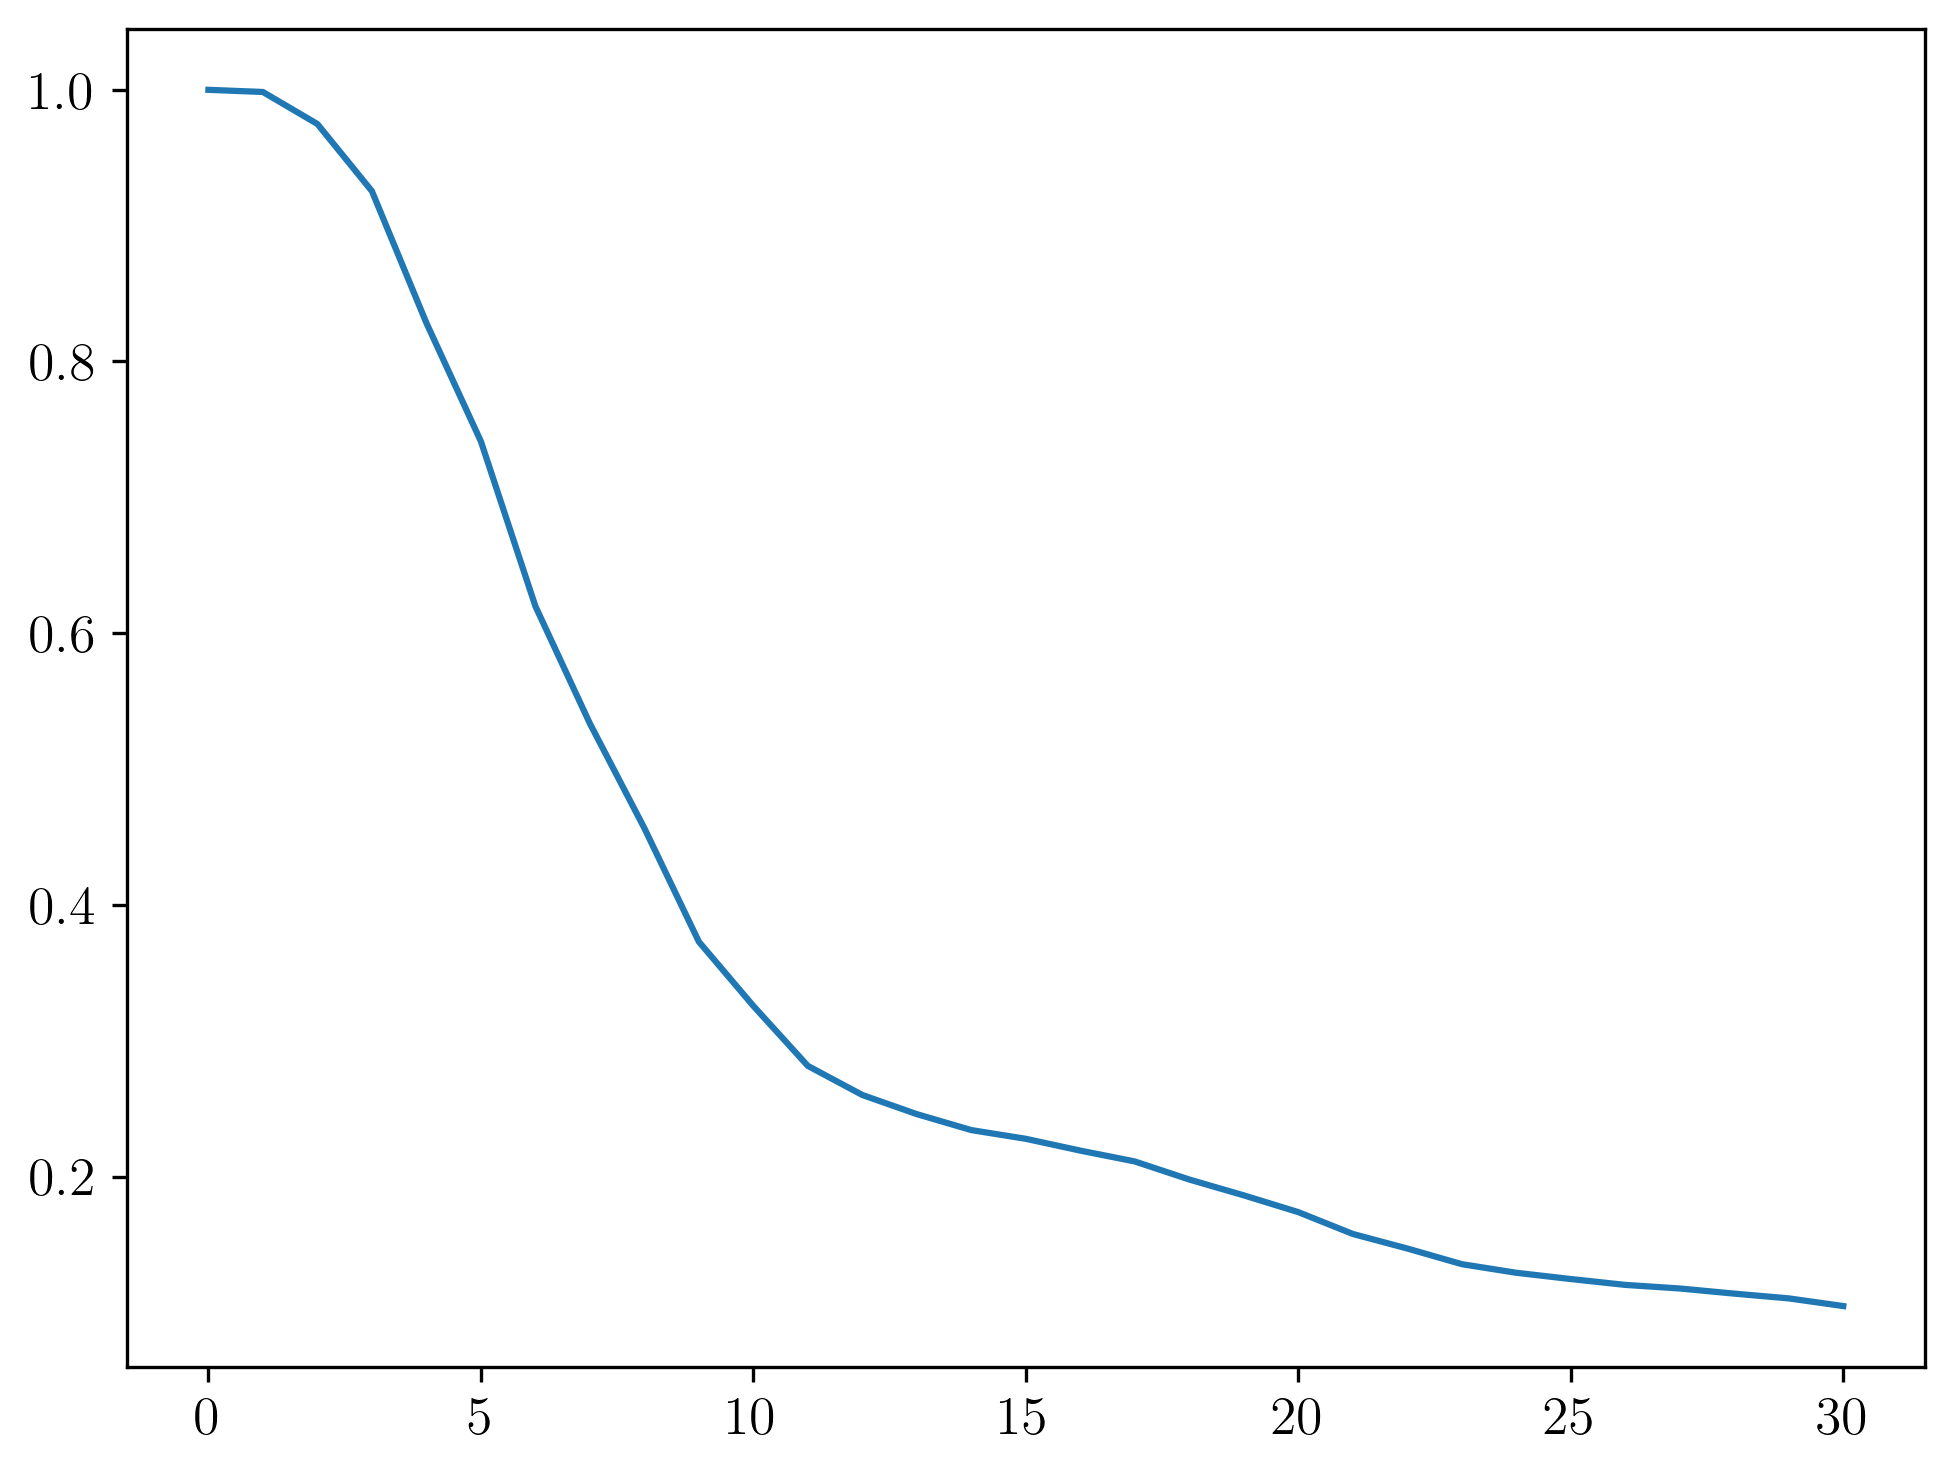

In [38]:
plt.plot(np.asarray(local_magnetization)[:,L//2])

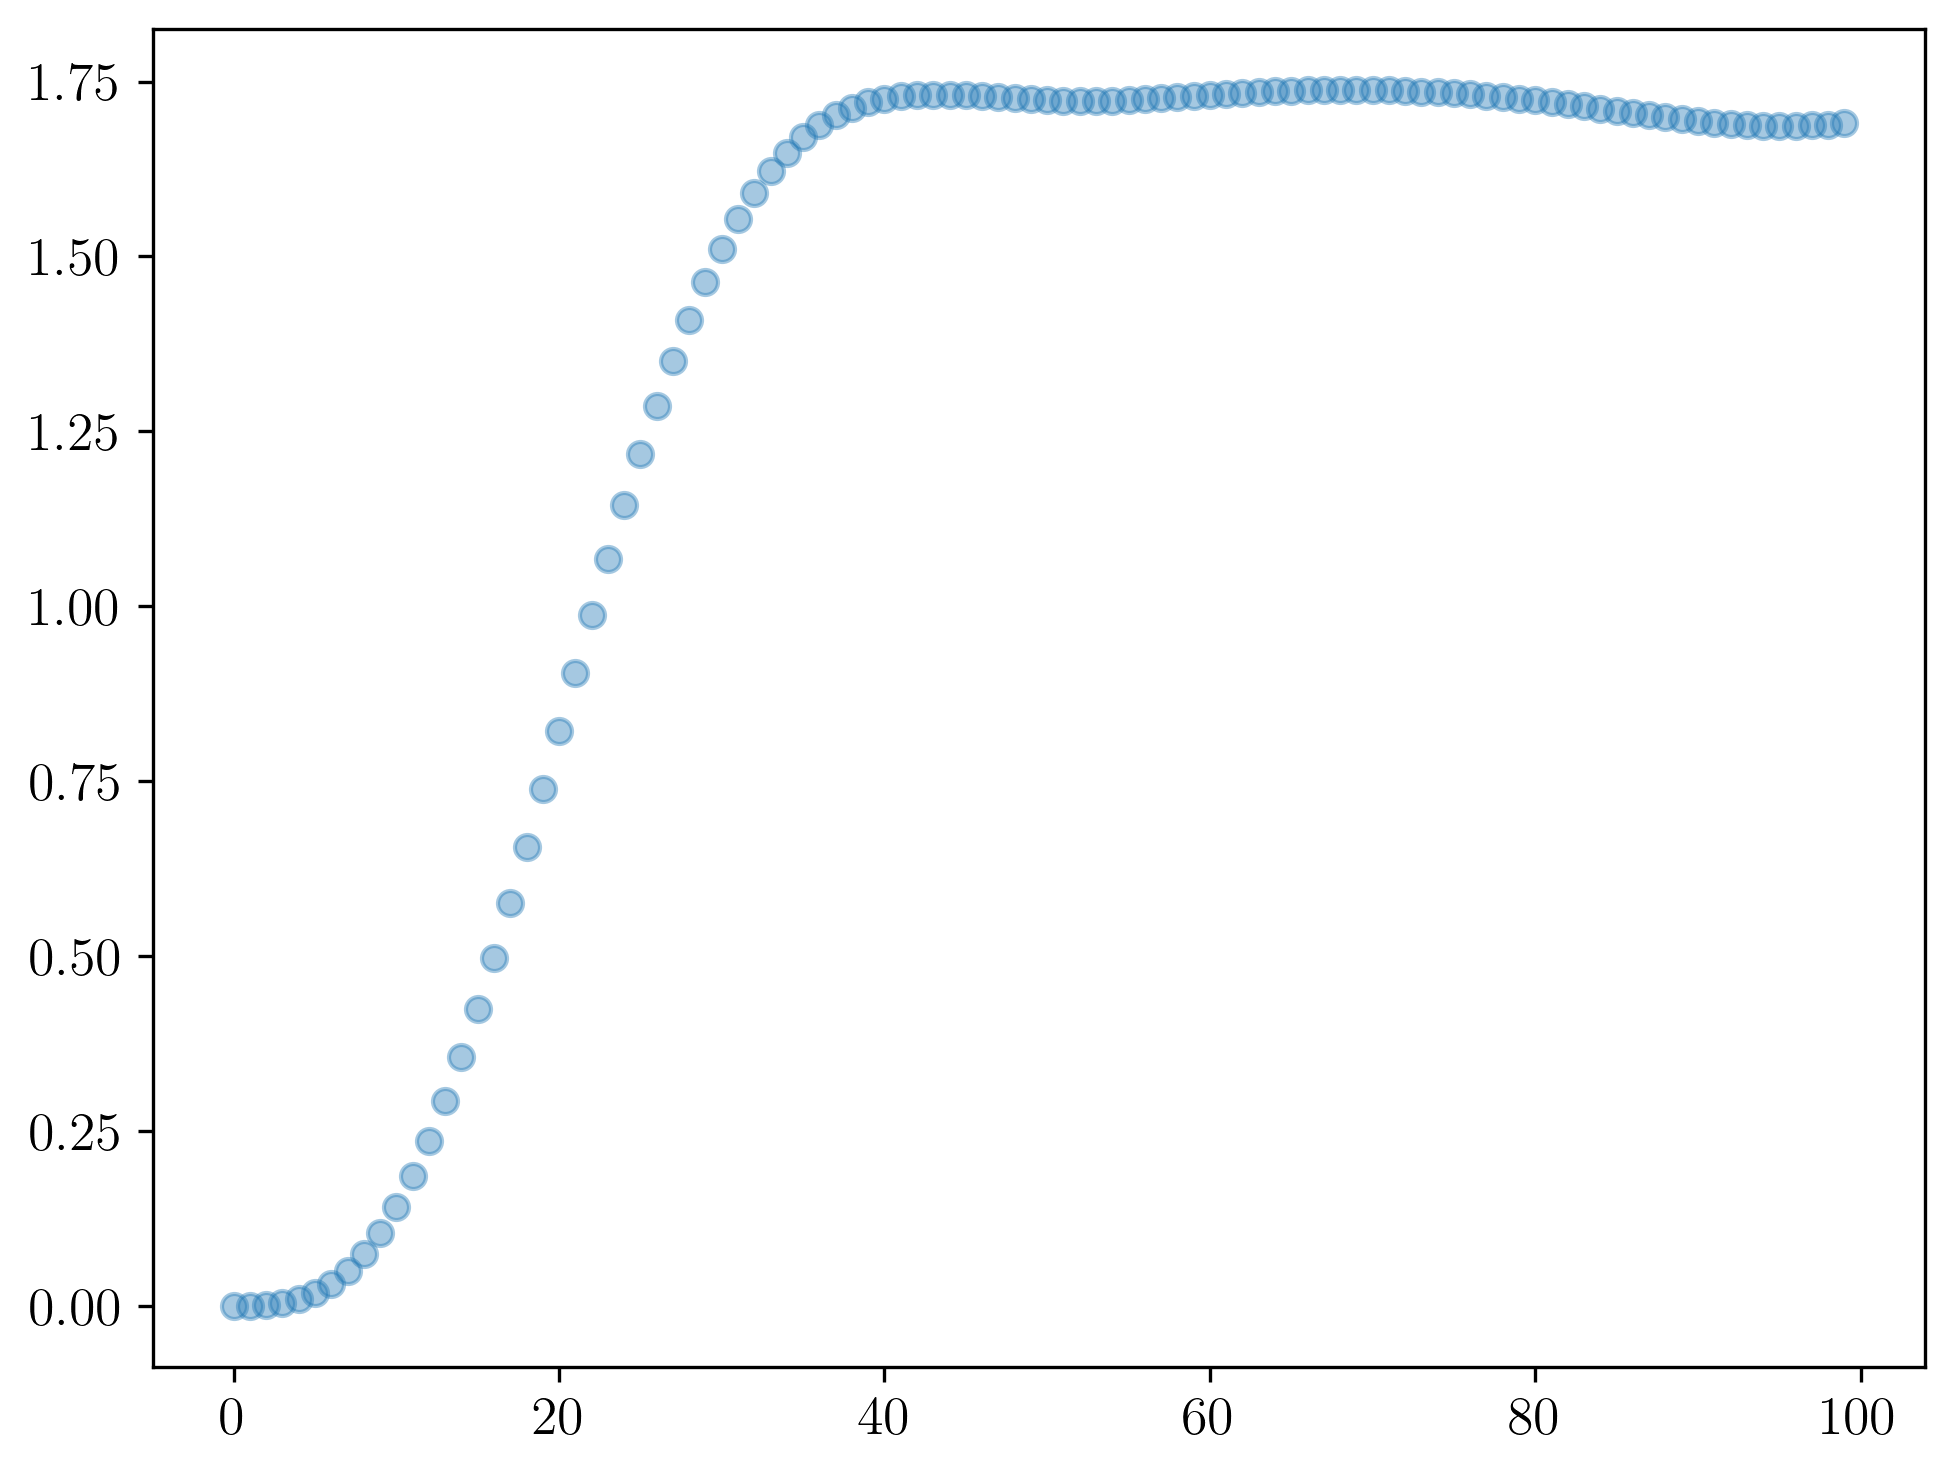

In [39]:
plt.plot(np.asarray(entrs)[:,0,0], 'o', alpha=0.4)

In [40]:
svs[0], svs[-1]

(array([9.99999361e-01, 7.99573424e-04, 7.99505416e-04, 1.99815086e-05]),
 array([0.73486289, 0.45125193, 0.45125193, 0.19746169, 0.11126034,
        0.03108309, 0.01955699, 0.00113927]))

In [41]:
def evol(chis):
    spin_up_tn = np.array([1,0,0]).reshape((1,3,1))
    hole_tn = np.array([0,1,0]).reshape((1,3,1))
    spin_down_tn = np.array([0,0,1]).reshape((1,3,1))
    L = 12

    mps_chain = MPS(L=L, d=3, model='tj', chi=1)
    init_state = [hole_tn]*(L//2 - 1) + [spin_up_tn]*2 + [hole_tn]*(L//2 - 1)
    mps_chain.sites = init_state.copy()

    op_ev_delta_half, op_ev_delta = U_i_ip1_tJ(Jz, t_up, t_down, J_perp, delta)
    site_i_delta_half, site_ip1_delta_half, site_i_delta, site_ip1_delta = evolution_mpo_svd_tJ(op_ev_delta_half, op_ev_delta, d=3)
    mpo_ev_trotter = evolution_mpo_step_tJ(mps_chain.L, site_i_delta_half, site_ip1_delta_half, site_i_delta, site_ip1_delta)
    mps_chain.w_dag = mpo_ev_trotter.copy()

    errs_chi, entrs_chi, loc_mag_chi, svs_chi = [], [], [], []
    for chi in chis:
        print("--------------")
        print(f"chi: {chi}")
        print("--------------")
        (
        errs,
        entrs,
        svs,
        local_magnetization,
        ovlps,
        chi_sat,
                ) = mps_chain.TEBD_variational_tJ(trotter_steps=trotter_steps, where=mps_chain.L//2, chi_max=chi, obs=['lm'], obs_freq=1)
        
        errs_chi.append(errs)
        entrs_chi.append(entrs)
        loc_mag_chi.append(local_magnetization)
        svs_chi.append(svs)
        
        mps_chain.sites = init_state.copy()
        mps_chain.w_dag = mpo_ev_trotter.copy()

    return errs_chi, entrs_chi, loc_mag_chi, svs_chi


In [42]:
err, entr, loc, svs = evol([2,4,8,16])

--------------
chi: 2
--------------

*** Computing local magnetization in date: 2026-04-17 13:44:09.164058 ***

Total time for the local magnetization is: 0:00:00.093198

*** Starting the 0-th trotter step in date: 2026-04-17 13:44:09.257256 ***

Sweep n: 0

Sweep n: 1

##############################
The error between the two last updated states converged
to an order of 1e-08 after:
1 sweeps at site 11
total iterations 23
##############################
Bond dim ancilla: 2
Bond dim site: 2
Compress the ising evolution operator: 0:00:00.112309
Total time for the 0-th trotter step is: 0:00:00.112309
Computing observables for this trotter step

*** Computing local magnetization in date: 2026-04-17 13:44:09.369565 ***

Total time for the local magnetization is: 0:00:00.110322

*** Starting the 1-th trotter step in date: 2026-04-17 13:44:09.479887 ***

Sweep n: 0

Sweep n: 1

##############################
The error between the two last updated states converged
to an order of 1e-08 after:
1

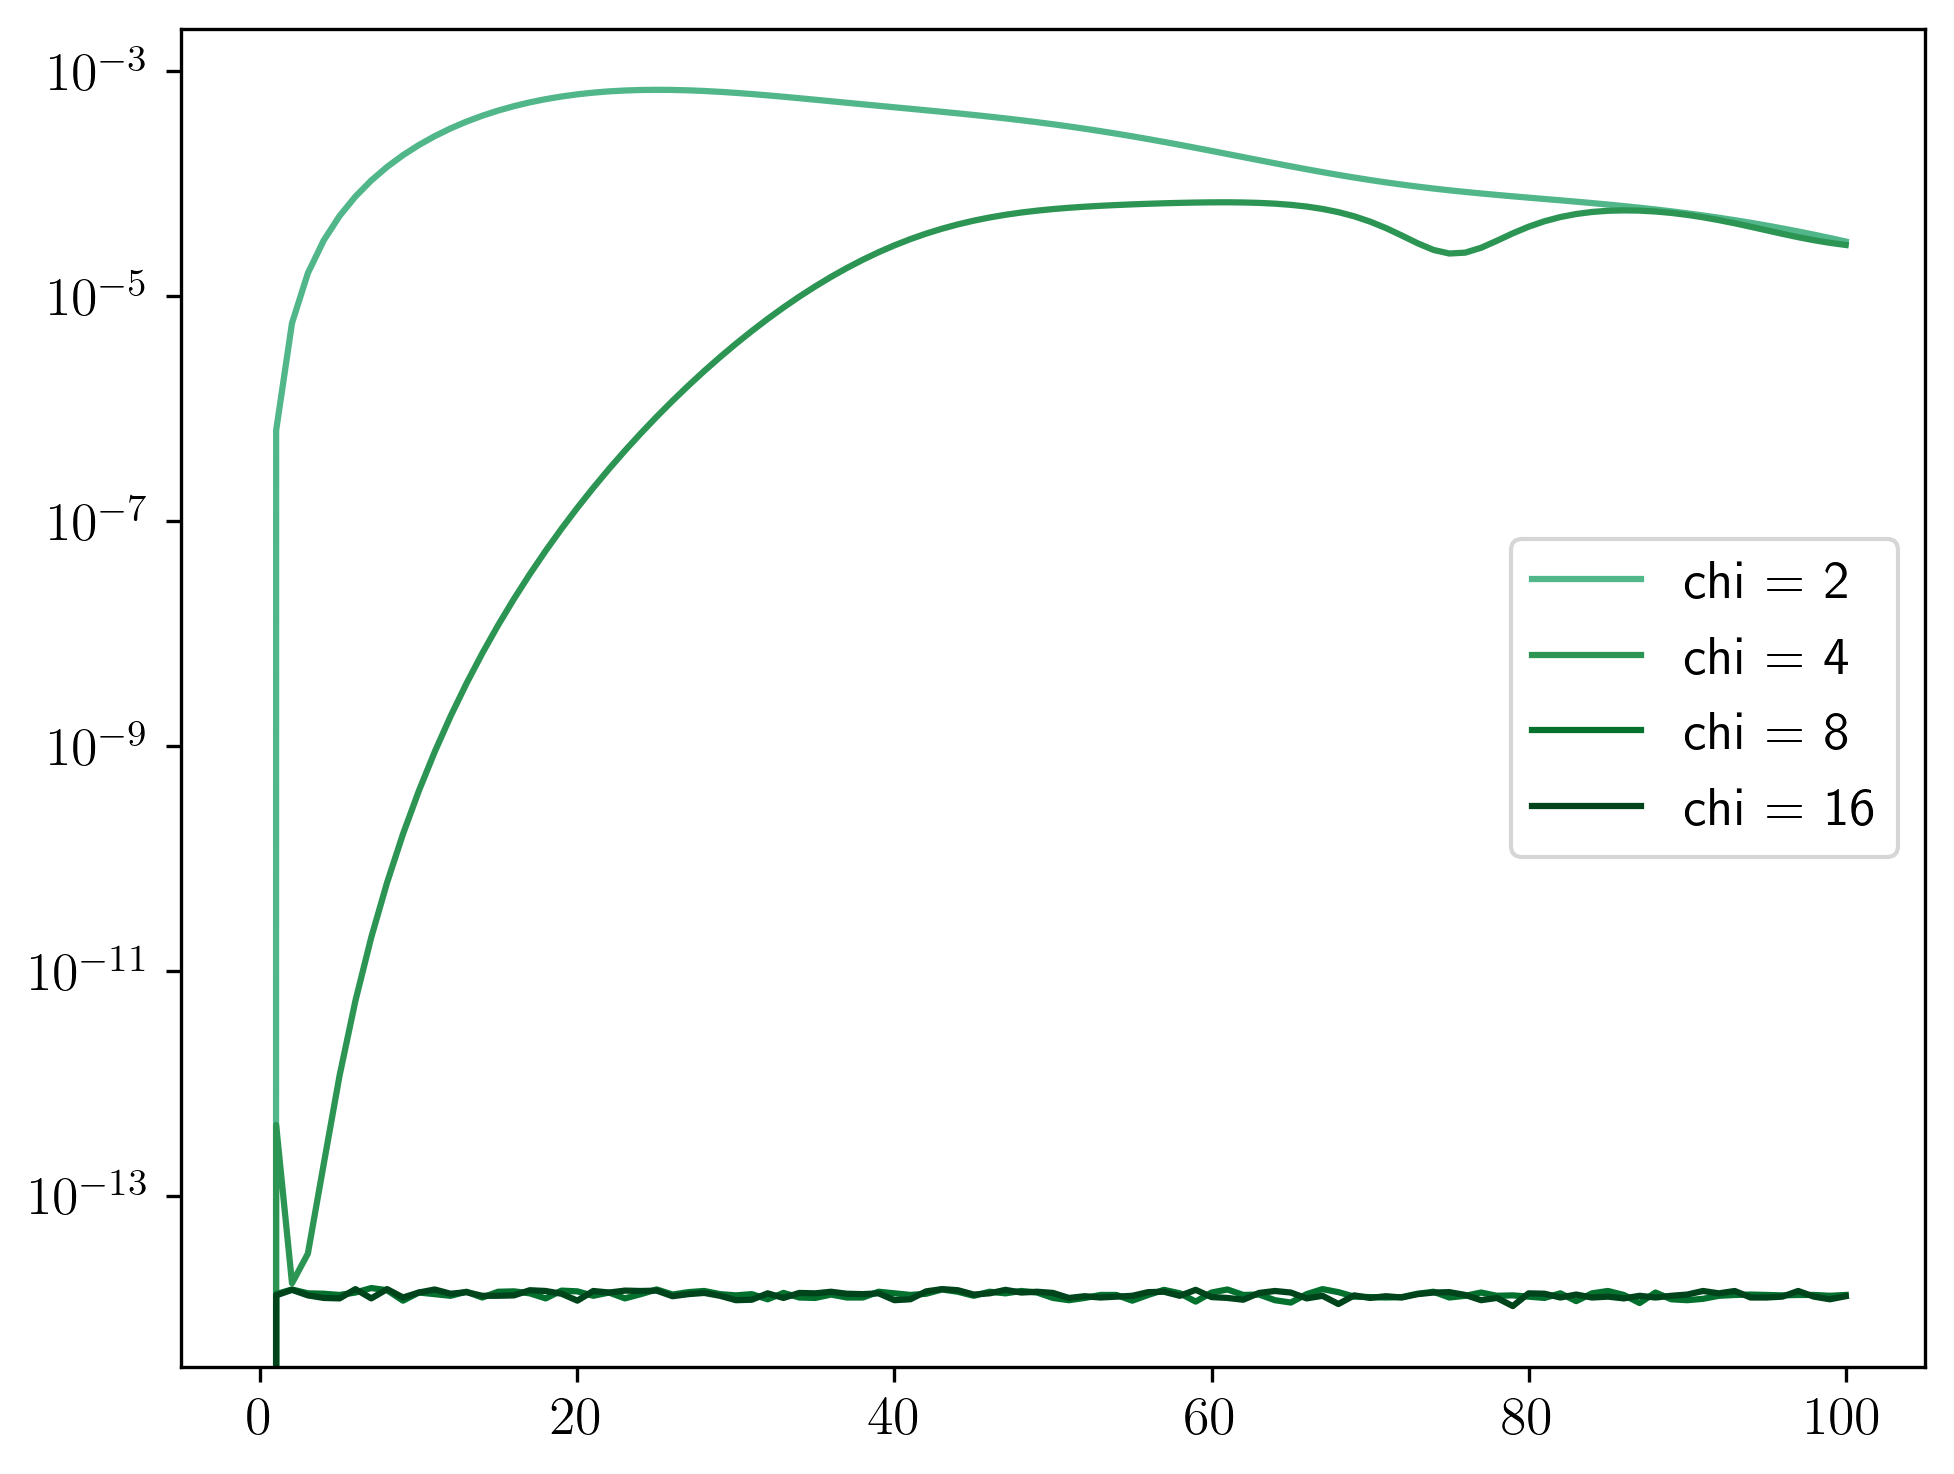

In [43]:
from qs_mps.utils import create_sequential_colors
chis = [2,4,8,16]
colors = create_sequential_colors(2*len(chis), "BuGn")

for i, er in enumerate(err):
    plt.plot(er, color=colors[len(chis)+i], label=f"chi = {chis[i]}")

plt.yscale('log')
plt.legend()

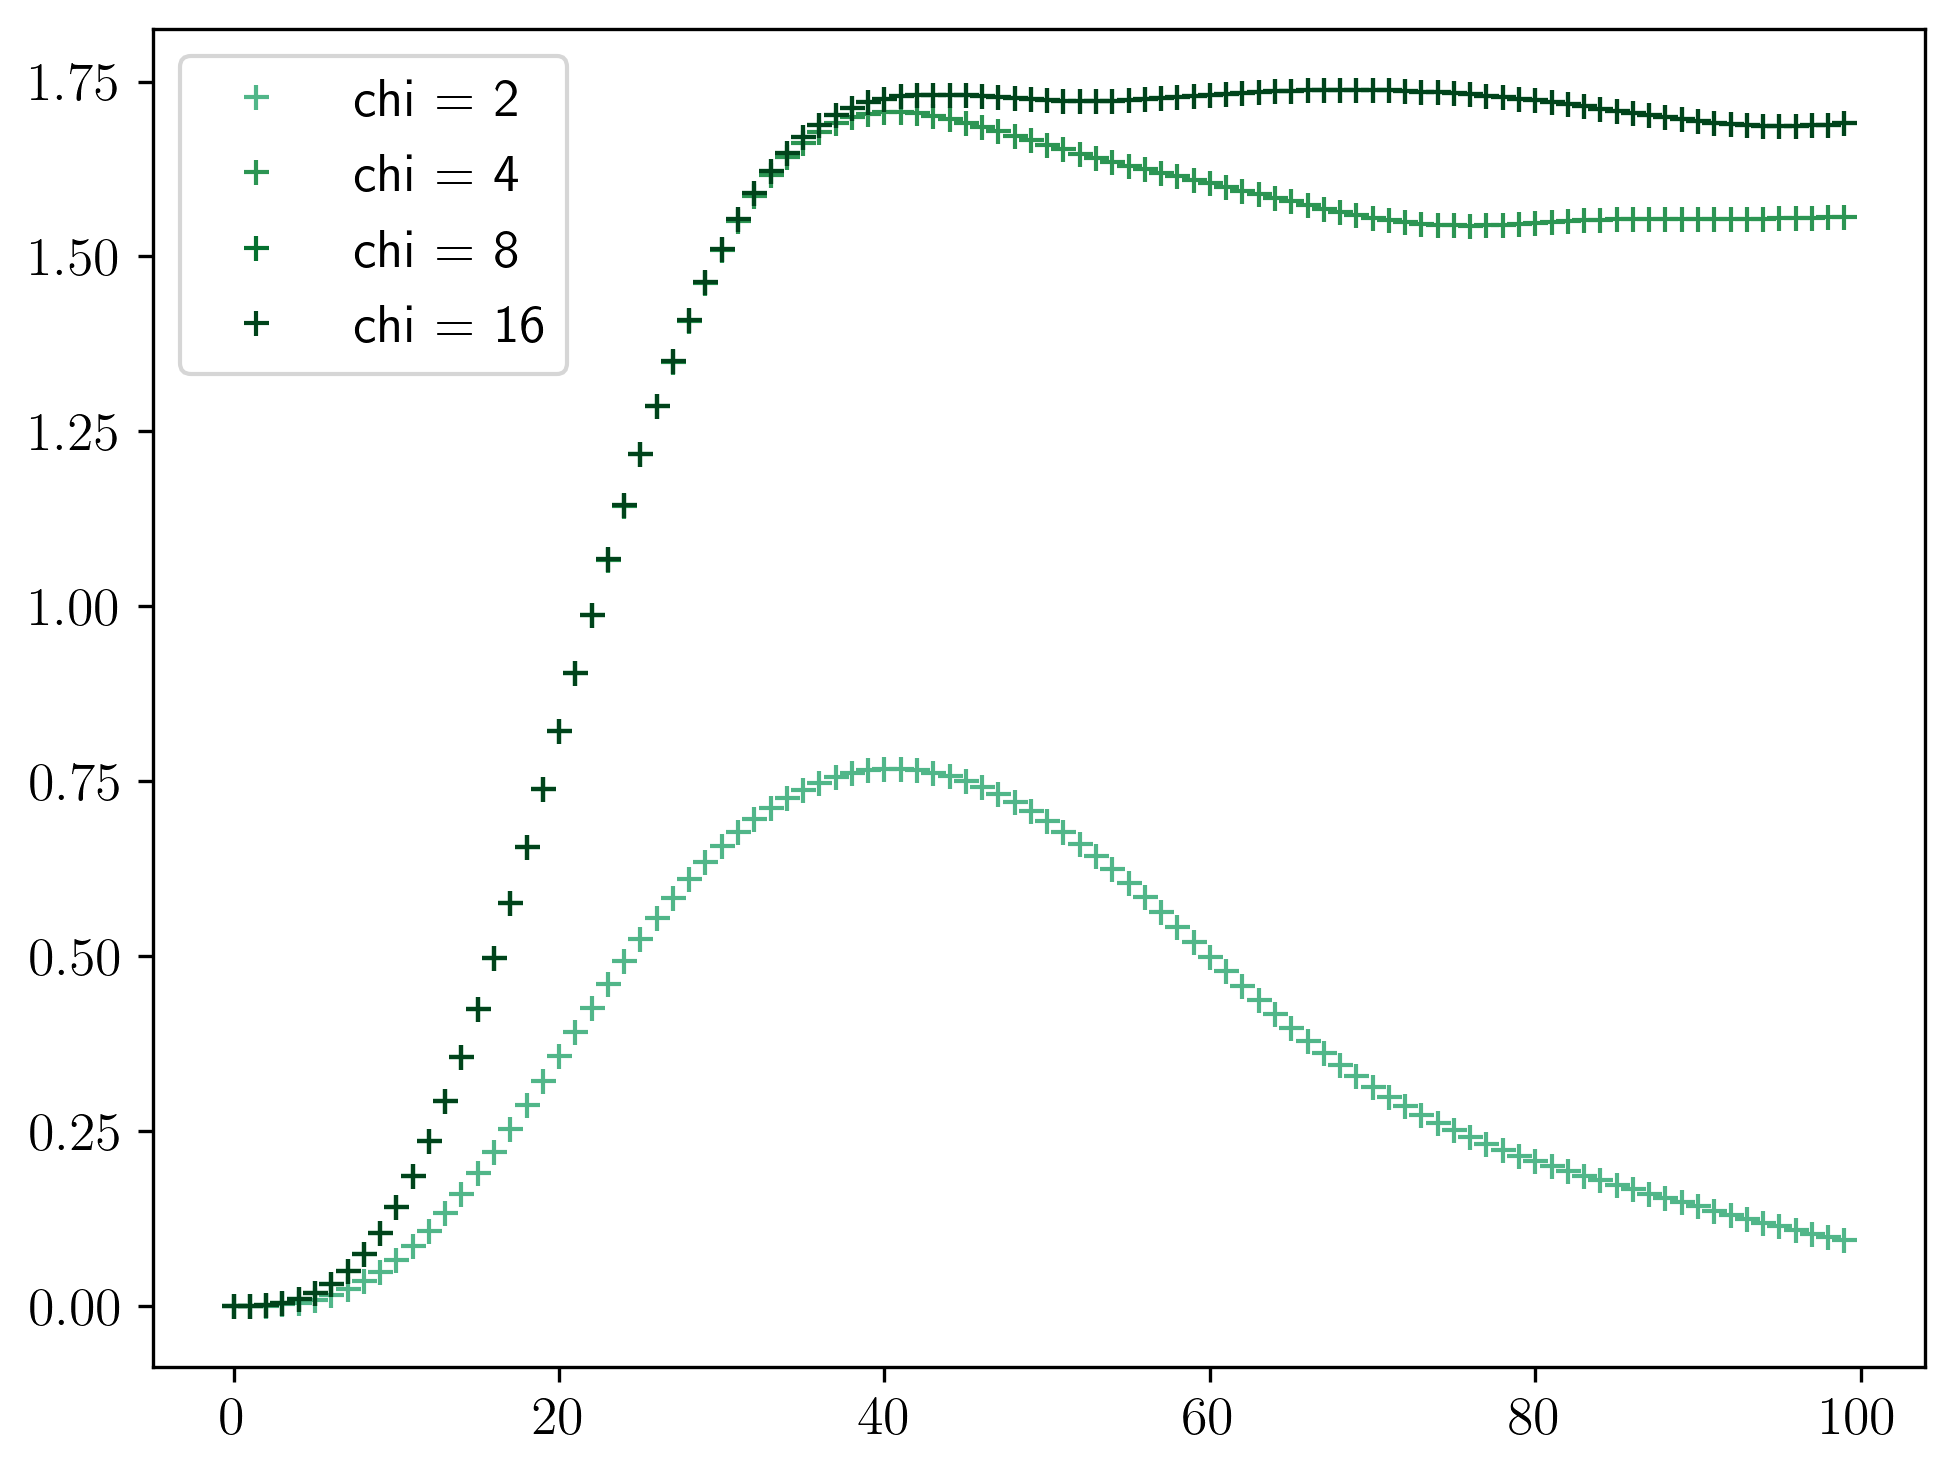

In [44]:
for i, ent in enumerate(entr):
    plt.plot(np.asarray(ent)[:,0,0], '+', alpha=1, color=colors[len(chis)+i], label=f"chi = {chis[i]}")

# plt.yscale('log')
plt.legend()

In [45]:
svs[-1][-1]

array([7.34862893e-01, 4.51251932e-01, 4.51251932e-01, 1.97461694e-01,
       1.11260341e-01, 3.10830947e-02, 1.95569894e-02, 1.13927441e-03,
       1.04134502e-15])

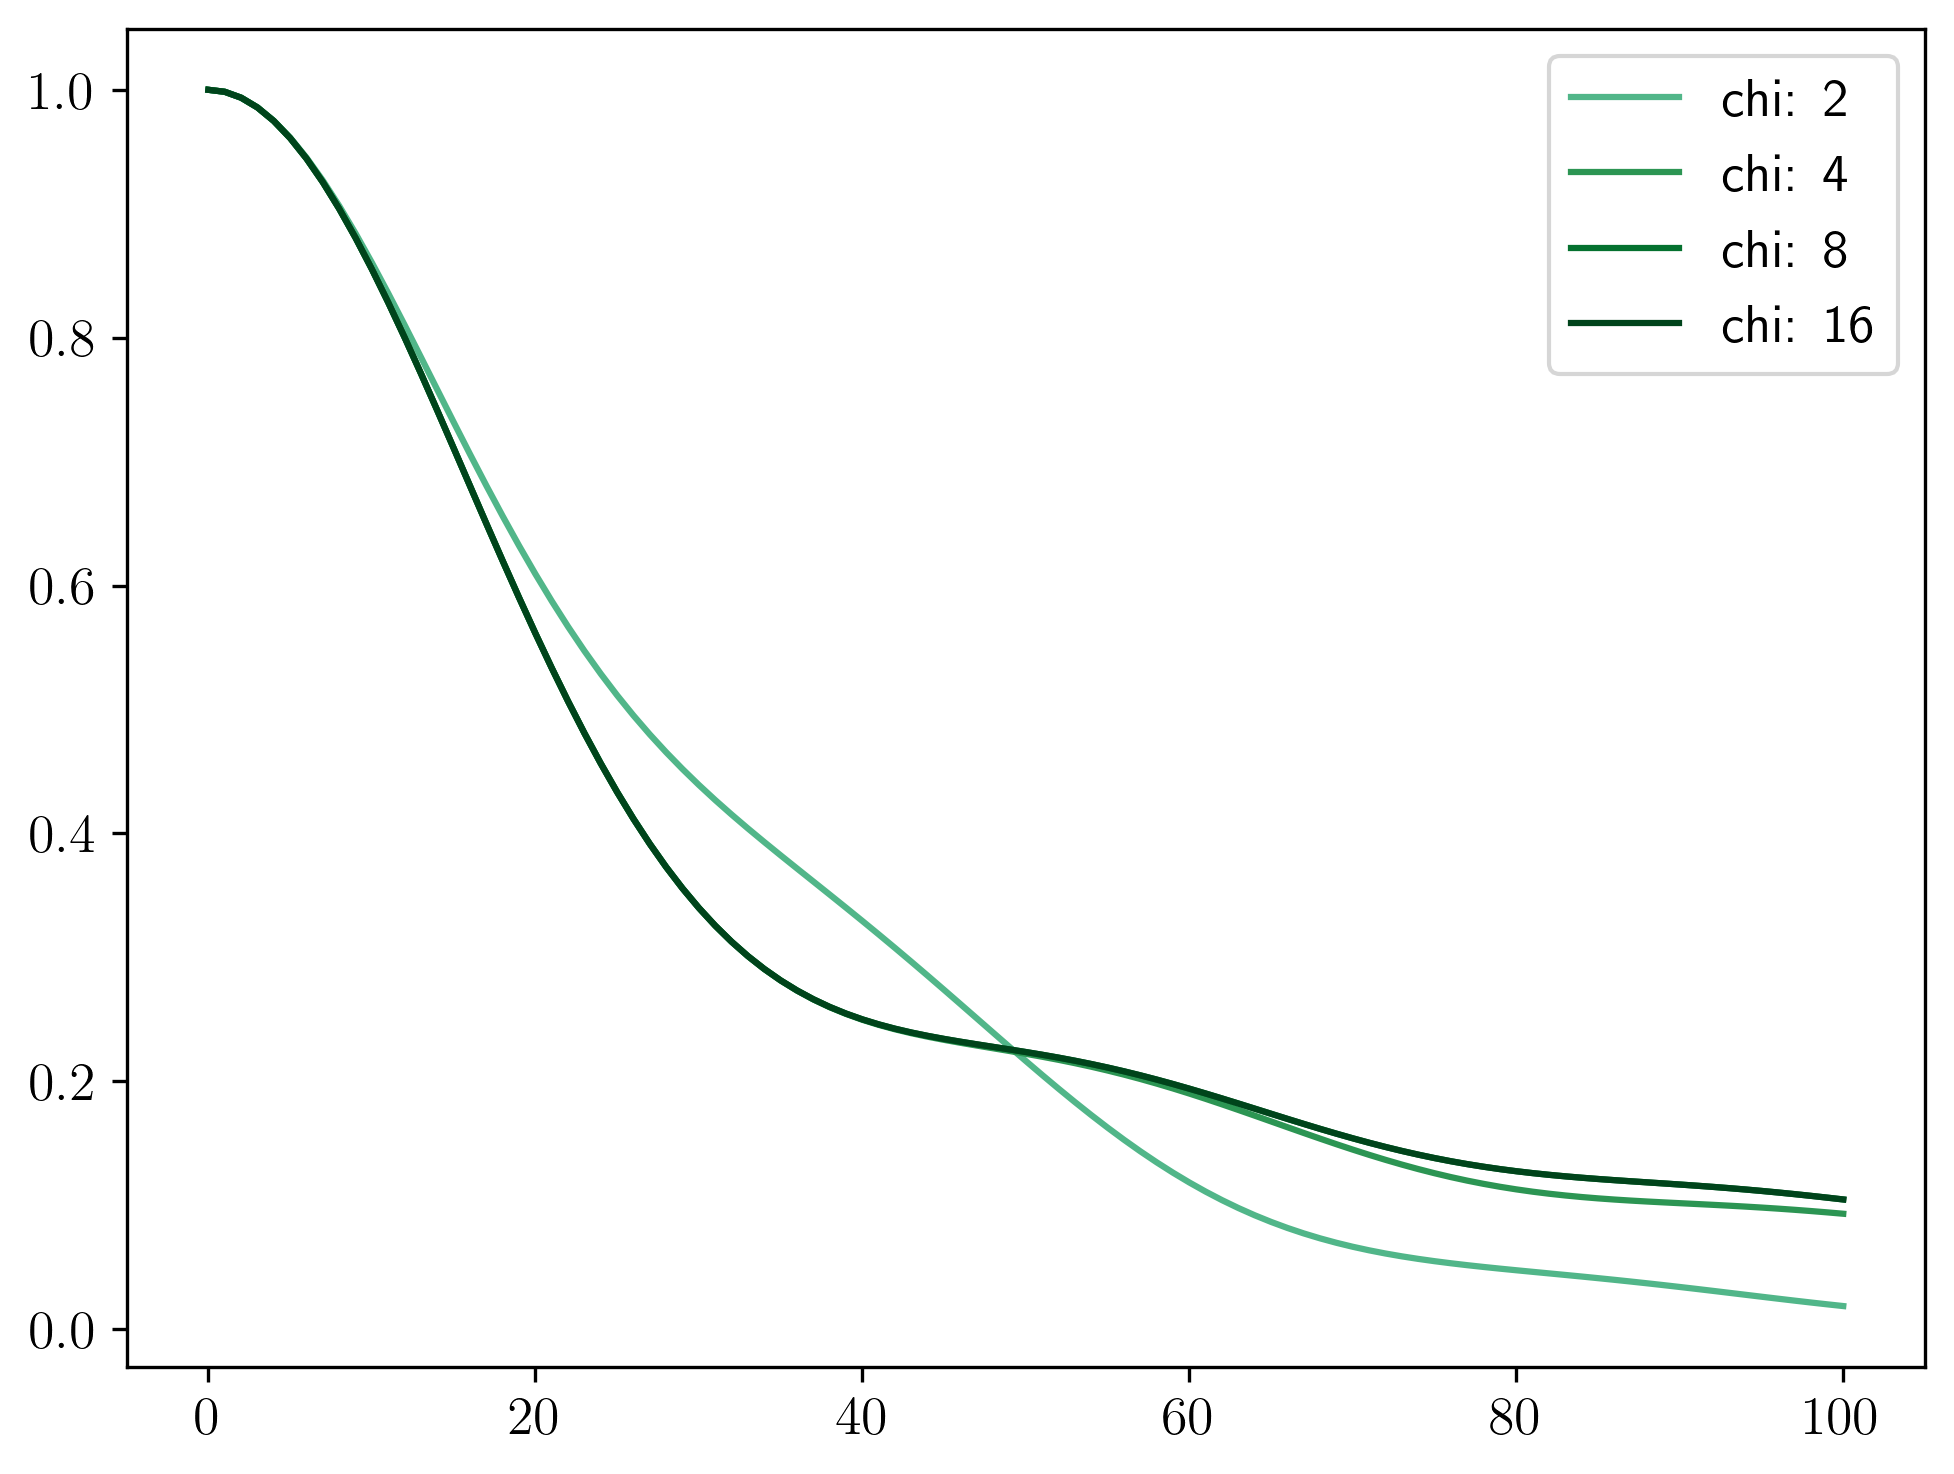

In [46]:
for i, local_magnetization in enumerate(loc):
    plt.plot(np.asarray(local_magnetization)[:,L//2], color=colors[len(chis)+i], label=f"chi: {chis[i]}")

plt.legend()

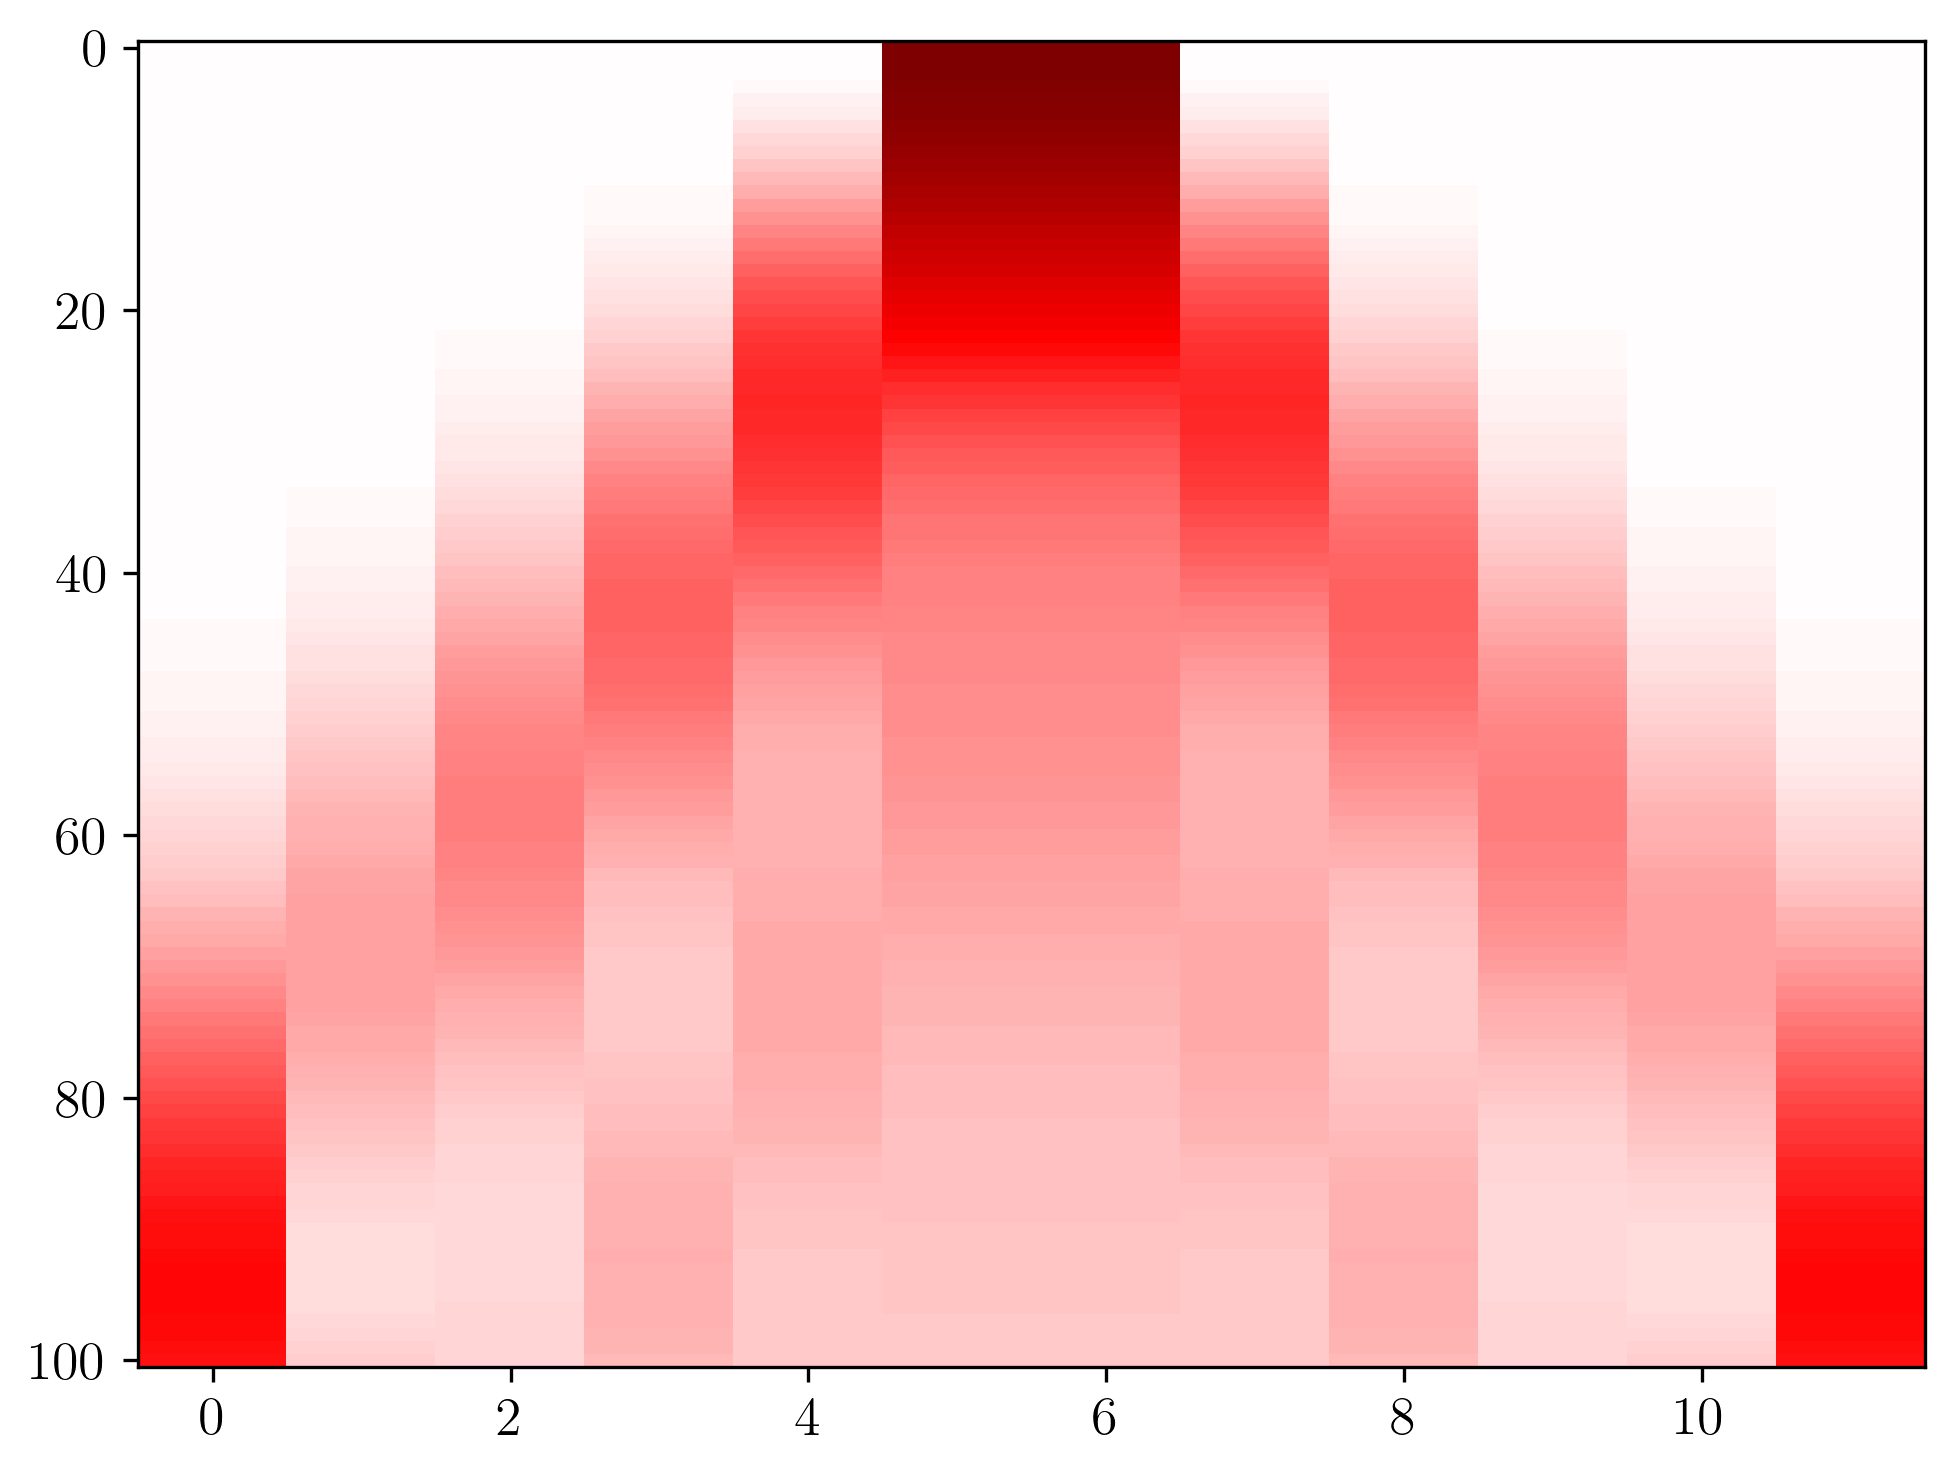

In [47]:
plt.imshow(np.asarray(loc)[-1], vmin=-1, vmax=1, aspect='auto', cmap='seismic')

In [48]:
half_chain_length = 5
t_up = 2
t_down = 2
Jz = 10
J_perp = 0
eps = 0
V = 0
trotter_steps = 100
final_time = 2

spin_up = np.array([1,0,0])
hole = np.array([0,1,0])
spin_down = np.array([0,0,1])

H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, n_holes=2)

# psi_init = kron(spin_up, kron(spin_down, kron(spin_up, kron(hole, kron(hole, kron(spin_up, kron(spin_down, spin_up))))))).T.toarray()
# psi_init = kron(spin_down, kron(spin_up, kron(spin_down, kron(hole, kron(hole, kron(spin_down, kron(spin_up, spin_down))))))).T.toarray()
# psi_init = kron(spin_up, kron(spin_down, kron(spin_up, kron(hole, kron(hole, kron(spin_down, kron(spin_up, spin_down))))))).T.toarray()
# psi_init = kron(spin_down, kron(spin_up, kron(spin_down, kron(hole, kron(hole, kron(spin_up, kron(spin_down, spin_up))))))).T.toarray()
# psi_init = kron(hole, kron(hole, kron(spin_up, kron(hole, hole)))).T.toarray()
# psi_init = kron(hole, kron(hole, kron(spin_up, kron(spin_up, kron(hole, hole))))).T.toarray()

psi_init = kron(hole, kron(hole, kron(hole, kron(hole, kron(hole, kron(spin_up, kron(spin_up, kron(hole, kron(hole, kron(hole, kron(hole, hole))))))))))).T.toarray()
# psi_init = psi_init.reshape((3**6))
psi_init = psi_init.reshape((3**(2*half_chain_length+2)))

# H_ev = tJV_ham(n=2*half_chain_length+2, t_up=t_up, t_down=t_down, Jz=Jz, J_perp=J_perp, eps=eps, V=V)
exp_vals, psi_save = half_hole_quench_evolution(half_chain_length, H_ev, psi_init, trotter_steps, final_time, obs=['m_loc'], n_holes=2, save=False)

Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

Text(0.5, 0, 'time $(\\delta T)$')

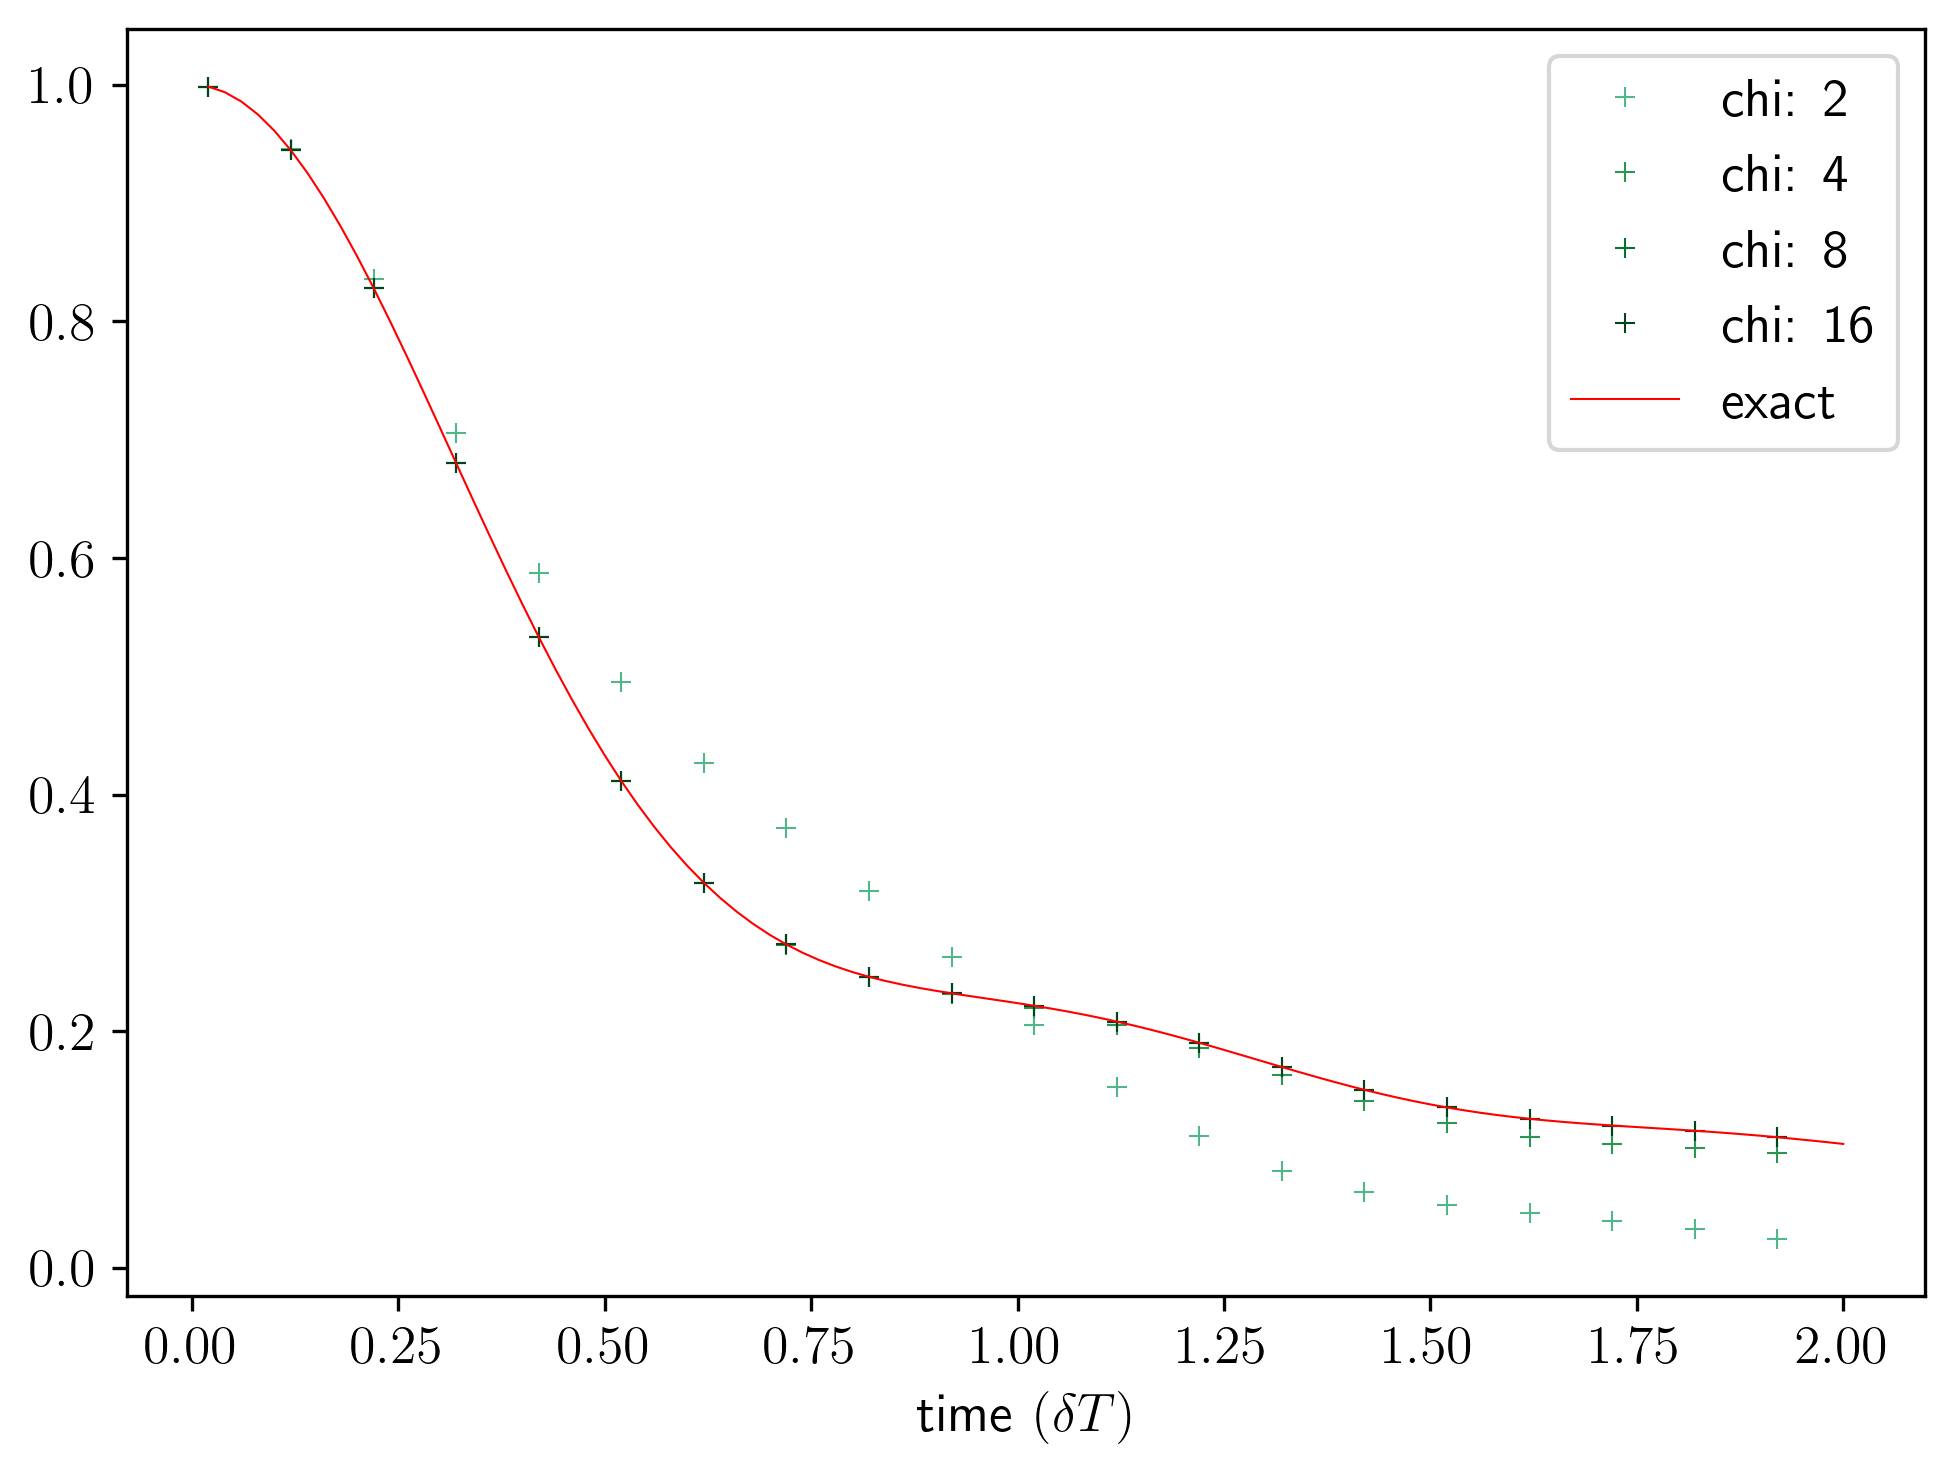

In [49]:
for i, local_magnetization in enumerate(loc):
    # plt.plot(np.linspace(0,trotter_steps-1, int(trotter_steps*0.3)), np.asarray(local_magnetization)[1:,L//2], '+', markersize=5, mew=0.5, color=colors[len(chis)+i], label=f"chi: {chis[i]}")
    plt.plot(np.linspace(delta,final_time,int(trotter_steps))[::5], np.asarray(local_magnetization)[1:,L//2][::5], '+', markersize=5, mew=0.5, color=colors[len(chis)+i], label=f"chi: {chis[i]}")

plt.plot(np.linspace(delta,final_time,trotter_steps), np.asarray(exp_vals[1])[:,L//2], 'r', linewidth=0.5, label='exact')
plt.legend()
plt.xlabel("time $(\\delta T)$")

Text(0.5, 0, 'trotter steps $(T)$')

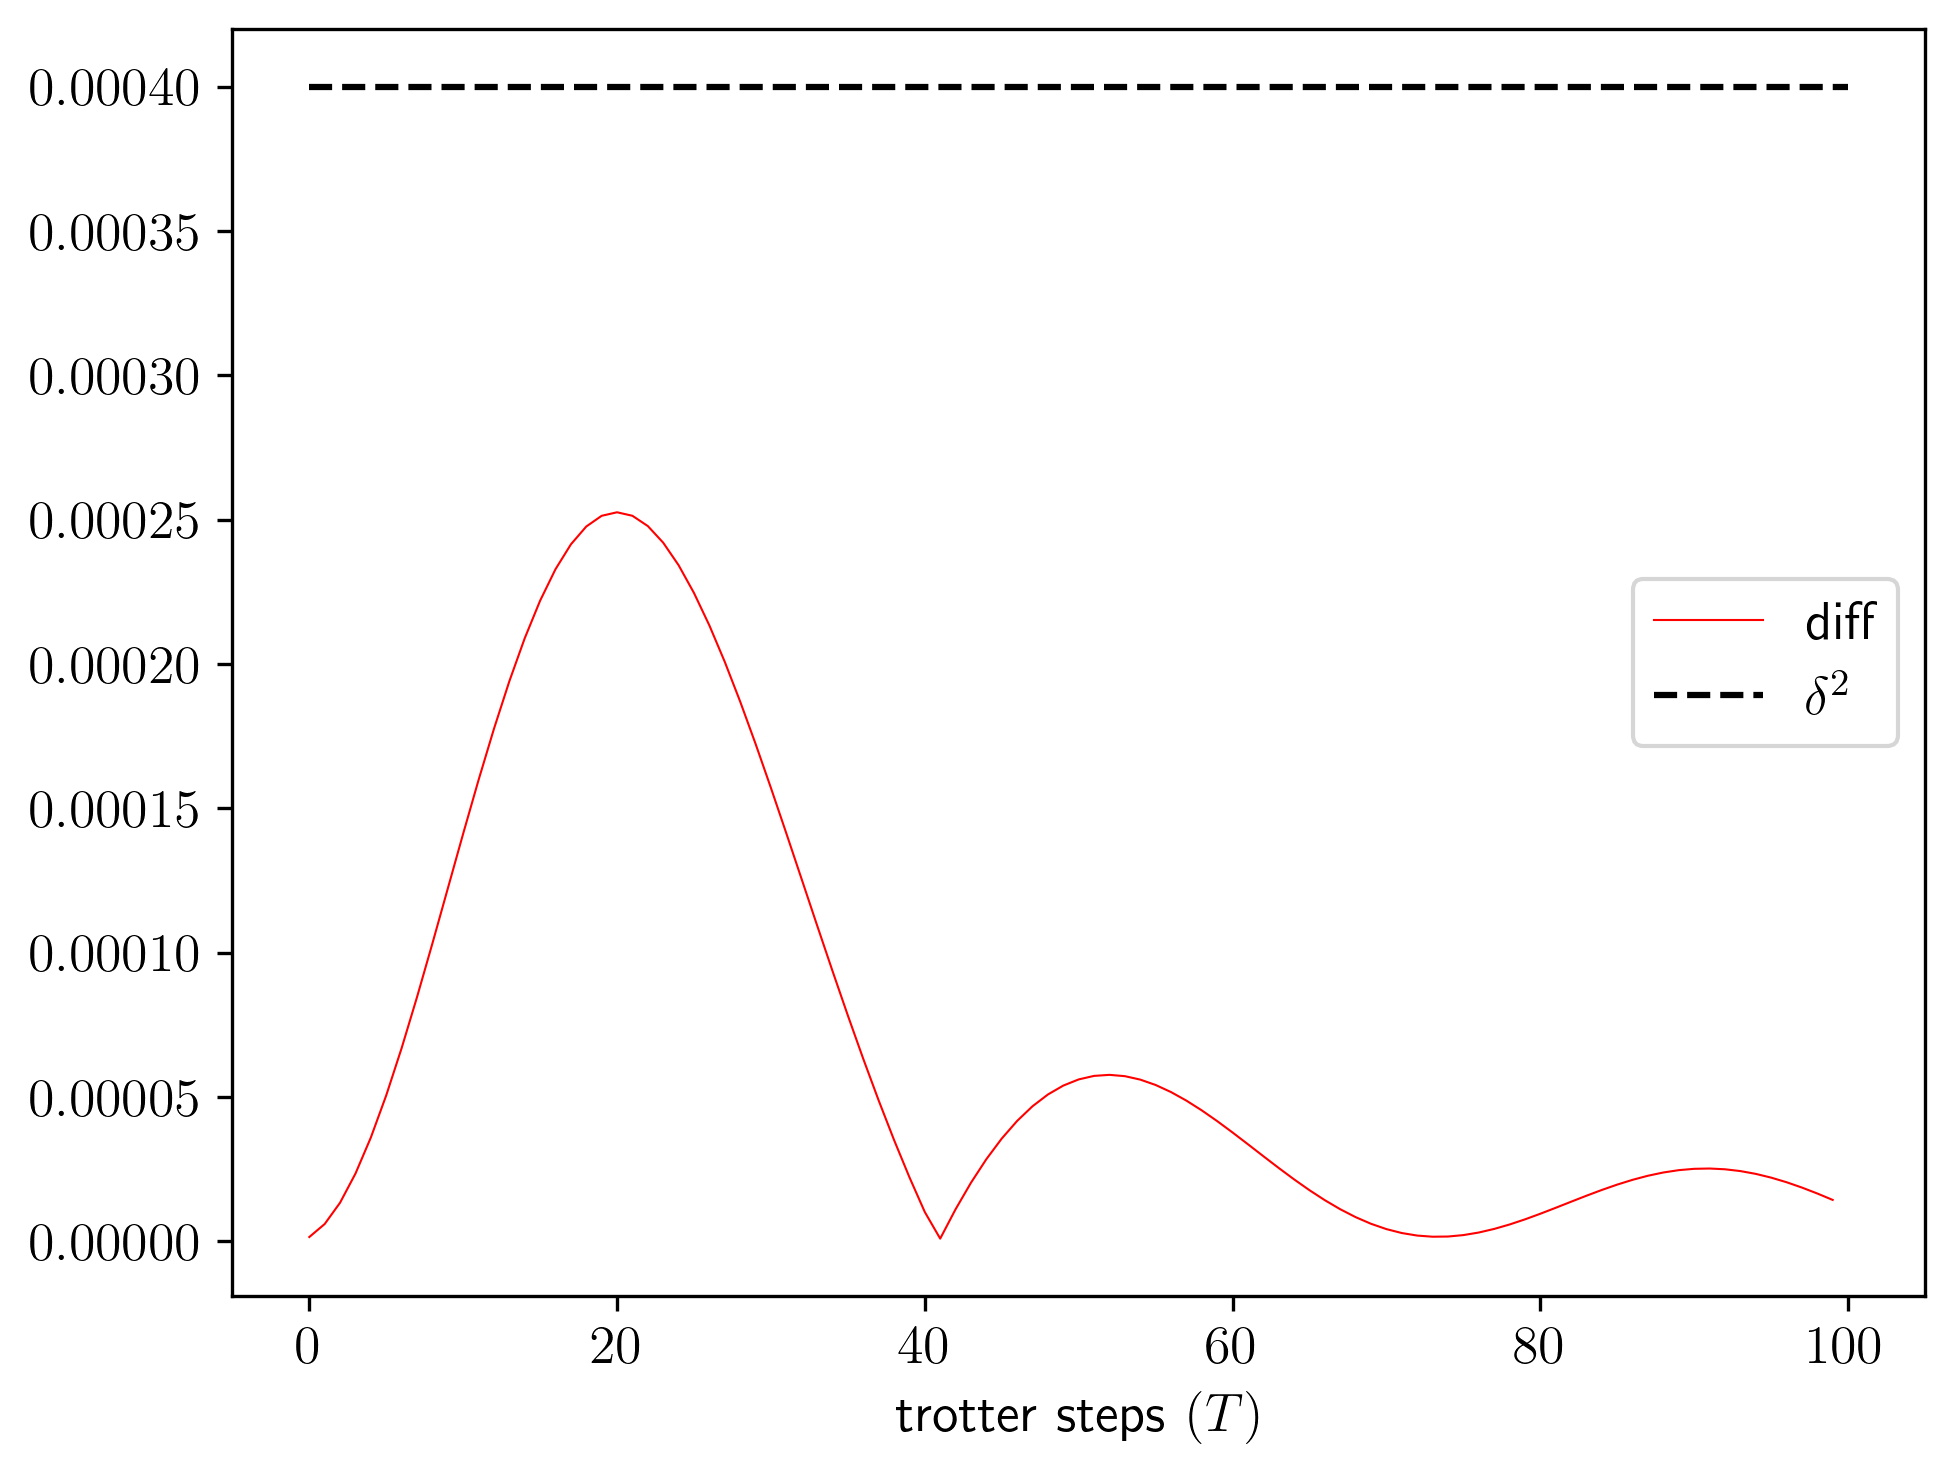

In [50]:
plt.plot(abs(np.asarray(local_magnetization)[1:,L//2]-np.asarray(exp_vals[1])[:,L//2]), 'r', linewidth=0.5, label='diff')
plt.hlines(delta**2, 0, 100, 'k', '--', label=f"$\\delta^2$")
plt.legend(loc='center right')
plt.xlabel("trotter steps $(T)$")


## $(i, i+2)$ interaction

In [51]:
def U_i_ip2_tJ(tp_up, tp_down, delta):
    """
    U_i_ip2

    This function computes the exponential of the 2-site hamiltonian for the t-J model.
    It returns to versions: 
    1. one with a time step delta/2 to use at the initial and final step
    of the trotterization
    2. one with a time step delta to use in the bulk steps of the trotterization

    """

    # choose the hamiltonian parameters
    H_i_ip2 = (
    - (tp_up/8) * kron(T_up_h, kron(Id, T_h_up)) 
    - (tp_up/8) * kron(T_h_up, kron(Id, T_up_h))
    - (tp_down/8) * kron(T_down_h, kron(Id, T_h_down)) 
    - (tp_down/8) * kron(T_h_down, kron(Id, T_down_h))).toarray()

    # initial and final 2-site evolution operator
    op_ev_if = sp.linalg.expm(-1j * delta/2 * H_i_ip2)

    # bulk 2-site evolution operator
    op_ev_bulk = sp.linalg.expm(-1j * delta * H_i_ip2)
    
    return op_ev_if, op_ev_bulk

def evolution_mpo_svd_1_tJ(op_ev: np.ndarray, d: int=3, schmidt_tol: float=1e-15, trunc: bool=False):
    """
    evolution_mpo_svd

    This function takes the edges, and bulk 2-site evolution operators (of the t-J model) and performs an svd
    to separate the matrix into site i and site i+1. Reshaping the results of the svd
    we can obtain the mpo for those evolution operators (with bounded bond dimension D<=d^2)

    """
    op_ev = op_ev.reshape(d,d,d,d)
    op_ev = op_ev.transpose(0,2,1,3)
    op_ev = op_ev.reshape(d*d,d*d)

    u, s, v = svd(op_ev, full_matrices=False)

    if trunc:
        condition = s >= schmidt_tol
        s_trunc = np.extract(condition, s)
        s = s_trunc
        v = v[:len(s),:]

    site_i = u.reshape(d,d,u.shape[1])
    site_i = site_i[:, :, :len(s)]
    site_i = site_i.transpose(2,0,1)
    site_i = site_i.reshape(1,len(s),d,d)

    site_ip1 = ncon([np.diag(s), v],[[-1, 1],[1, -2]]).reshape(v.shape[0],d,d)
    site_ip1 = site_ip1.reshape(1,v.shape[0],d,d)
    site_ip1 = site_ip1.transpose(1,0,2,3)


    tol = 1e-15 * np.max(np.abs(site_i))
    site_i.real[np.abs(site_i.real) < tol] = 0
    site_i.imag[np.abs(site_i.imag) < tol] = 0
    
    tol = 1e-15 * np.max(np.abs(site_ip1))
    site_ip1.real[np.abs(site_ip1.real) < tol] = 0
    site_ip1.imag[np.abs(site_ip1.imag) < tol] = 0
    
    return site_i, site_ip1

def evolution_mpo_svd_2_tJ(op_ev: np.ndarray, d: int=3, schmidt_tol: float=1e-15, trunc: bool=False):
    """
    evolution_mpo_svd

    This function takes the edges, and bulk 2-site evolution operators (of the t-J model) and performs an svd
    to separate the matrix into site i and site i+1. Reshaping the results of the svd
    we can obtain the mpo for those evolution operators (with bounded bond dimension D<=d^2)

    """
    op_ev = op_ev.reshape(d,d,d,d,d,d)
    op_ev = op_ev.transpose(0,1,3,4,2,5)
    op_ev = op_ev.reshape((d**2)*(d**2),d*d)

    u, s, v = svd(op_ev, full_matrices=False)

    if trunc:
        condition = s >= schmidt_tol
        s_trunc = np.extract(condition, s)
        s = s_trunc
        u = u[:, :len(s)]

    site_i_ip1 = ncon([u, np.diag(s)],[[-1, 1],[1, -2]])
    site_i_ip1 = site_i_ip1.reshape(d**2,d**2,u.shape[1])
    site_i_ip1 = site_i_ip1.transpose(2,0,1)
    site_i_ip1 = site_i_ip1.reshape(1,len(s),d**2,d**2)

    site_i_ip1 = site_i_ip1.reshape(1,len(s),d,d,d,d)
    site_i_ip1 = site_i_ip1.transpose(0,2,4,1,3,5)
    site_i_ip1 = site_i_ip1.reshape(d**2,(d**2)*len(s))

    u1, s1, v1 = svd(site_i_ip1, full_matrices=False)

    if trunc:
        condition = s1 >= schmidt_tol
        s_trunc = np.extract(condition, s1)
        s1 = s_trunc
        v1 = v1[:len(s1),:]

    site_ip1 = v1.reshape(v1.shape[0],len(s),d,d)

    site_i = ncon([u1, np.diag(s1)],[[-1, 1],[1, -2]]).reshape(1,d,d,u1.shape[1])
    site_i = site_i[:,:,:,:len(s1)]
    site_i = site_i.transpose(0,3,1,2)

    site_ip2 = v.reshape(v.shape[0],d,d)
    site_ip2 = site_ip2[:len(s), :, :]
    site_ip2 = site_ip2.reshape(1,len(s),d,d)
    site_ip2 = site_ip2.transpose(1,0,2,3)


    tol = 1e-15 * np.max(np.abs(site_i))
    site_i.real[np.abs(site_i.real) < tol] = 0
    site_i.imag[np.abs(site_i.imag) < tol] = 0
    
    tol = 1e-15 * np.max(np.abs(site_ip1))
    site_ip1.real[np.abs(site_ip1.real) < tol] = 0
    site_ip1.imag[np.abs(site_ip1.imag) < tol] = 0

    tol = 1e-15 * np.max(np.abs(site_ip2))
    site_ip2.real[np.abs(site_ip2.real) < tol] = 0
    site_ip2.imag[np.abs(site_ip2.imag) < tol] = 0
    
    return site_i, site_ip1, site_ip2


def evolution_mpo_step_tJ(n, site_i_if, site_ip1_if, site_i_b, site_ip1_b):
    """
    evolution_mpo_start_tJ

    This function finds the starting evolution mpo for a chain n of the t-J model.
    It is the first step of a second order trotterization.

    """
    # first site has one tensor only
    mpo_id = Id.reshape((1,1,3,3))
    mpo_start = ncon([site_i_if, mpo_id, site_i_if],[[-1,-4,-7,1],[-2,-5,1,2],[-3,-6,2,-8]]).reshape((site_i_if.shape[0]**2,site_i_if.shape[1]**2, 3, 3))
    # two bulk operators for even and odd sites
    mpo_bulk_odd = ncon([site_ip1_if, site_i_b, site_ip1_if],[[-1,-4,-7,1],[-2,-5,1,2],[-3,-6,2,-8]]).reshape((site_ip1_if.shape[0]**2*site_i_b.shape[0],site_ip1_if.shape[1]**2*site_i_b.shape[1], 3, 3))
    mpo_bulk_even = ncon([site_i_if, site_ip1_b, site_i_if],[[-1,-4,-7,1],[-2,-5,1,2],[-3,-6,2,-8]]).reshape((site_i_if.shape[0]**2*site_ip1_b.shape[0],site_i_if.shape[1]**2*site_ip1_b.shape[1], 3, 3))
    # two last-site operators depending on the parity of the chain
    mpo_end_n_odd = ncon([mpo_id, site_ip1_b, mpo_id],[[-1,-4,-7,1],[-2,-5,1,2],[-3,-6,2,-8]]).reshape((mpo_id.shape[0]**2*site_ip1_b.shape[0],mpo_id.shape[1]**2*site_ip1_b.shape[1], 3, 3)) # for odd chains
    mpo_end_n_even = ncon([site_ip1_if, mpo_id, site_ip1_if],[[-1,-4,-7,1],[-2,-5,1,2],[-3,-6,2,-8]]).reshape((site_ip1_if.shape[0]**2*mpo_id.shape[0],site_ip1_if.shape[1]**2*mpo_id.shape[1], 3, 3)) # for even chains
 
    mpo_step = []
    
    # left op
    mpo_step.append(mpo_start)
    
    # bulk ops
    for i in range(1,n-1):
        if (i%2) == 0:
            mpo_step.append(mpo_bulk_even)
        elif (i%2) == 1:
            mpo_step.append(mpo_bulk_odd)
    
    # right op
    if (n%2) == 0:
        mpo_step.append(mpo_end_n_even)
    elif (n%2) == 1:
        mpo_step.append(mpo_end_n_odd)
    
    return mpo_step

In [52]:
delta = 0.05
op_ev_delta_half, op_ev_delta = U_i_ip2_tJ(1,1,delta)
site_1_hf, site_2_hf, site_3_hf = evolution_mpo_svd_2_tJ(op_ev_delta_half)
site_1, site_2, site_3 = evolution_mpo_svd_2_tJ(op_ev_delta)

In [53]:
site_1.shape, site_2.shape, site_3.shape

((1, 9, 3, 3), (9, 9, 3, 3), (9, 1, 3, 3))

In [54]:
site_2[8,-1]

array([[0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j]])

In [55]:
for i in range(9):
    for j in range(3):
        print(site_2[i,i,j,j])

(0.577350269189626+0j)
(0.5773502691896258+0j)
(0.5773502691896258+0j)
-0.5773502691896257j
-0.5773502691896257j
-0.5773502691896257j
(-0.2552571177572654+0.5178582211064983j)
(-0.2552571177572654+0.5178582211064983j)
(-0.2552571177572654+0.5178582211064983j)
(0.43618925749393866+0j)
(0.43618925749393866+0j)
(0.43618925749393866+0j)
(-0.436188985812086+0.00048683604789021706j)
(-0.436188985812086+0.0004868360478902168j)
(-0.436188985812086+0.00048683604789021673j)
(0.5773502691854312+0j)
(0.577350269191544+0j)
(0.5773502691919019+0j)
(0.449288860618343+0j)
(-2.2453594270051602e-12+0j)
(-0.08773783513664629+0j)
(2.5245663273206183e-13+0j)
0j
(-4.930012818771895e-14+0j)
0j
0j
0j


In [56]:
def evolution_mpo_step_tJ_2(n, site_i_if, site_ip1_if, site_ip2_if, site_i_b, site_ip1_b, site_ip2_b):
    """
    evolution_mpo_start_tJ_2

    This function finds the starting evolution mpo for a chain n of the t-J model.
    It is the first step of a second order trotterization.

    """
    # first site has one tensor only
    mpo_id = Id.reshape((1,1,3,3))
    mpo_left_1 = site_i_if.copy()
    mpo_left_2 = ncon([site_ip1_if, site_i_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_ip1_if.shape[0]*site_i_b.shape[0],site_ip1_if.shape[1]*site_i_b.shape[1],3,3))
    # three bulk operators for (mod 3) sites
    mpo_bulk_1 = ncon([site_ip2_if, site_ip1_b, site_i_if],[[-1,-4,-7,1],[-2,-5,1,2],[-3,-6,2,-8]]).reshape((site_ip2_if.shape[0]*site_ip1_b.shape[0]*site_i_if.shape[0],site_ip2_if.shape[1]*site_ip1_b.shape[1]*site_i_if.shape[1], 3, 3))
    mpo_bulk_2 = ncon([site_i_if, site_ip2_b, site_ip1_if],[[-1,-4,-7,1],[-2,-5,1,2],[-3,-6,2,-8]]).reshape((site_i_if.shape[0]*site_ip2_b.shape[0]*site_ip1_if.shape[0],site_i_if.shape[1]*site_ip2_b.shape[1]*site_ip1_if.shape[1], 3, 3))
    mpo_bulk_3 = ncon([site_ip1_if, site_i_b, site_ip2_if],[[-1,-4,-7,1],[-2,-5,1,2],[-3,-6,2,-8]]).reshape((site_ip1_if.shape[0]*site_i_b.shape[0]*site_ip2_if.shape[0],site_ip1_if.shape[1]*site_i_b.shape[1]*site_ip2_if.shape[1], 3, 3))
    # two last-site operators depending on the parity of the chain
    mpo_right_1_0 = ncon([site_ip1_if, site_ip2_if],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_ip1_if.shape[0]*site_ip2_if.shape[0],site_ip1_if.shape[1]*site_ip2_if.shape[1], 3, 3)) # for odd chains
    mpo_right_1_1 = ncon([site_ip2_if, site_ip1_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_ip2_if.shape[0]*site_ip1_b.shape[0],site_ip2_if.shape[1]*site_ip1_b.shape[1], 3, 3)) # for odd chains
    mpo_right_1_2 = ncon([site_ip2_b, site_ip1_if],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_ip2_b.shape[0]*site_ip1_if.shape[0],site_ip2_b.shape[1]*site_ip1_if.shape[1], 3, 3)) # for odd chains
    mpo_right_2_0 = site_ip2_if.copy()
    mpo_right_2_1 = site_ip2_b.copy()
    mpo_step = []

    # left op
    mpo_step.append(mpo_left_1)
    mpo_step.append(mpo_left_2)

    # bulk ops
    for i in range(2,n-2):
        if (i%3) == 0:
            mpo_step.append(mpo_bulk_1)
        elif (i%3) == 1:
            mpo_step.append(mpo_bulk_2)
        elif (i%3) == 2:
            mpo_step.append(mpo_bulk_3)

    # right op
    if (n%3) == 0:
        mpo_step.append(mpo_right_1_0)
        mpo_step.append(mpo_right_2_0)
    elif (n%3) == 1:
        mpo_step.append(mpo_right_1_1)
        mpo_step.append(mpo_right_2_1)
    elif (n%3) == 2:
        mpo_step.append(mpo_right_1_2)
        mpo_step.append(mpo_right_2_0)


    return mpo_step

In [57]:
mpo_nnn = evolution_mpo_step_tJ_2(8, site_1_hf, site_2_hf, site_3_hf, site_1, site_2, site_3)
tensor_shapes(mpo_nnn)

(1, 9, 3, 3)
(9, 81, 3, 3)
(81, 81, 3, 3)
(81, 81, 3, 3)
(81, 81, 3, 3)
(81, 81, 3, 3)
(81, 9, 3, 3)
(9, 1, 3, 3)


[(1, 9, 3, 3),
 (9, 81, 3, 3),
 (81, 81, 3, 3),
 (81, 81, 3, 3),
 (81, 81, 3, 3),
 (81, 81, 3, 3),
 (81, 9, 3, 3),
 (9, 1, 3, 3)]

In [65]:
half_chain_length = 3
t_up = 0
t_down = 0
Jz = 10
J_perp = 0
eps = 0
V = 0
trotter_steps = 100
final_time = 2

Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

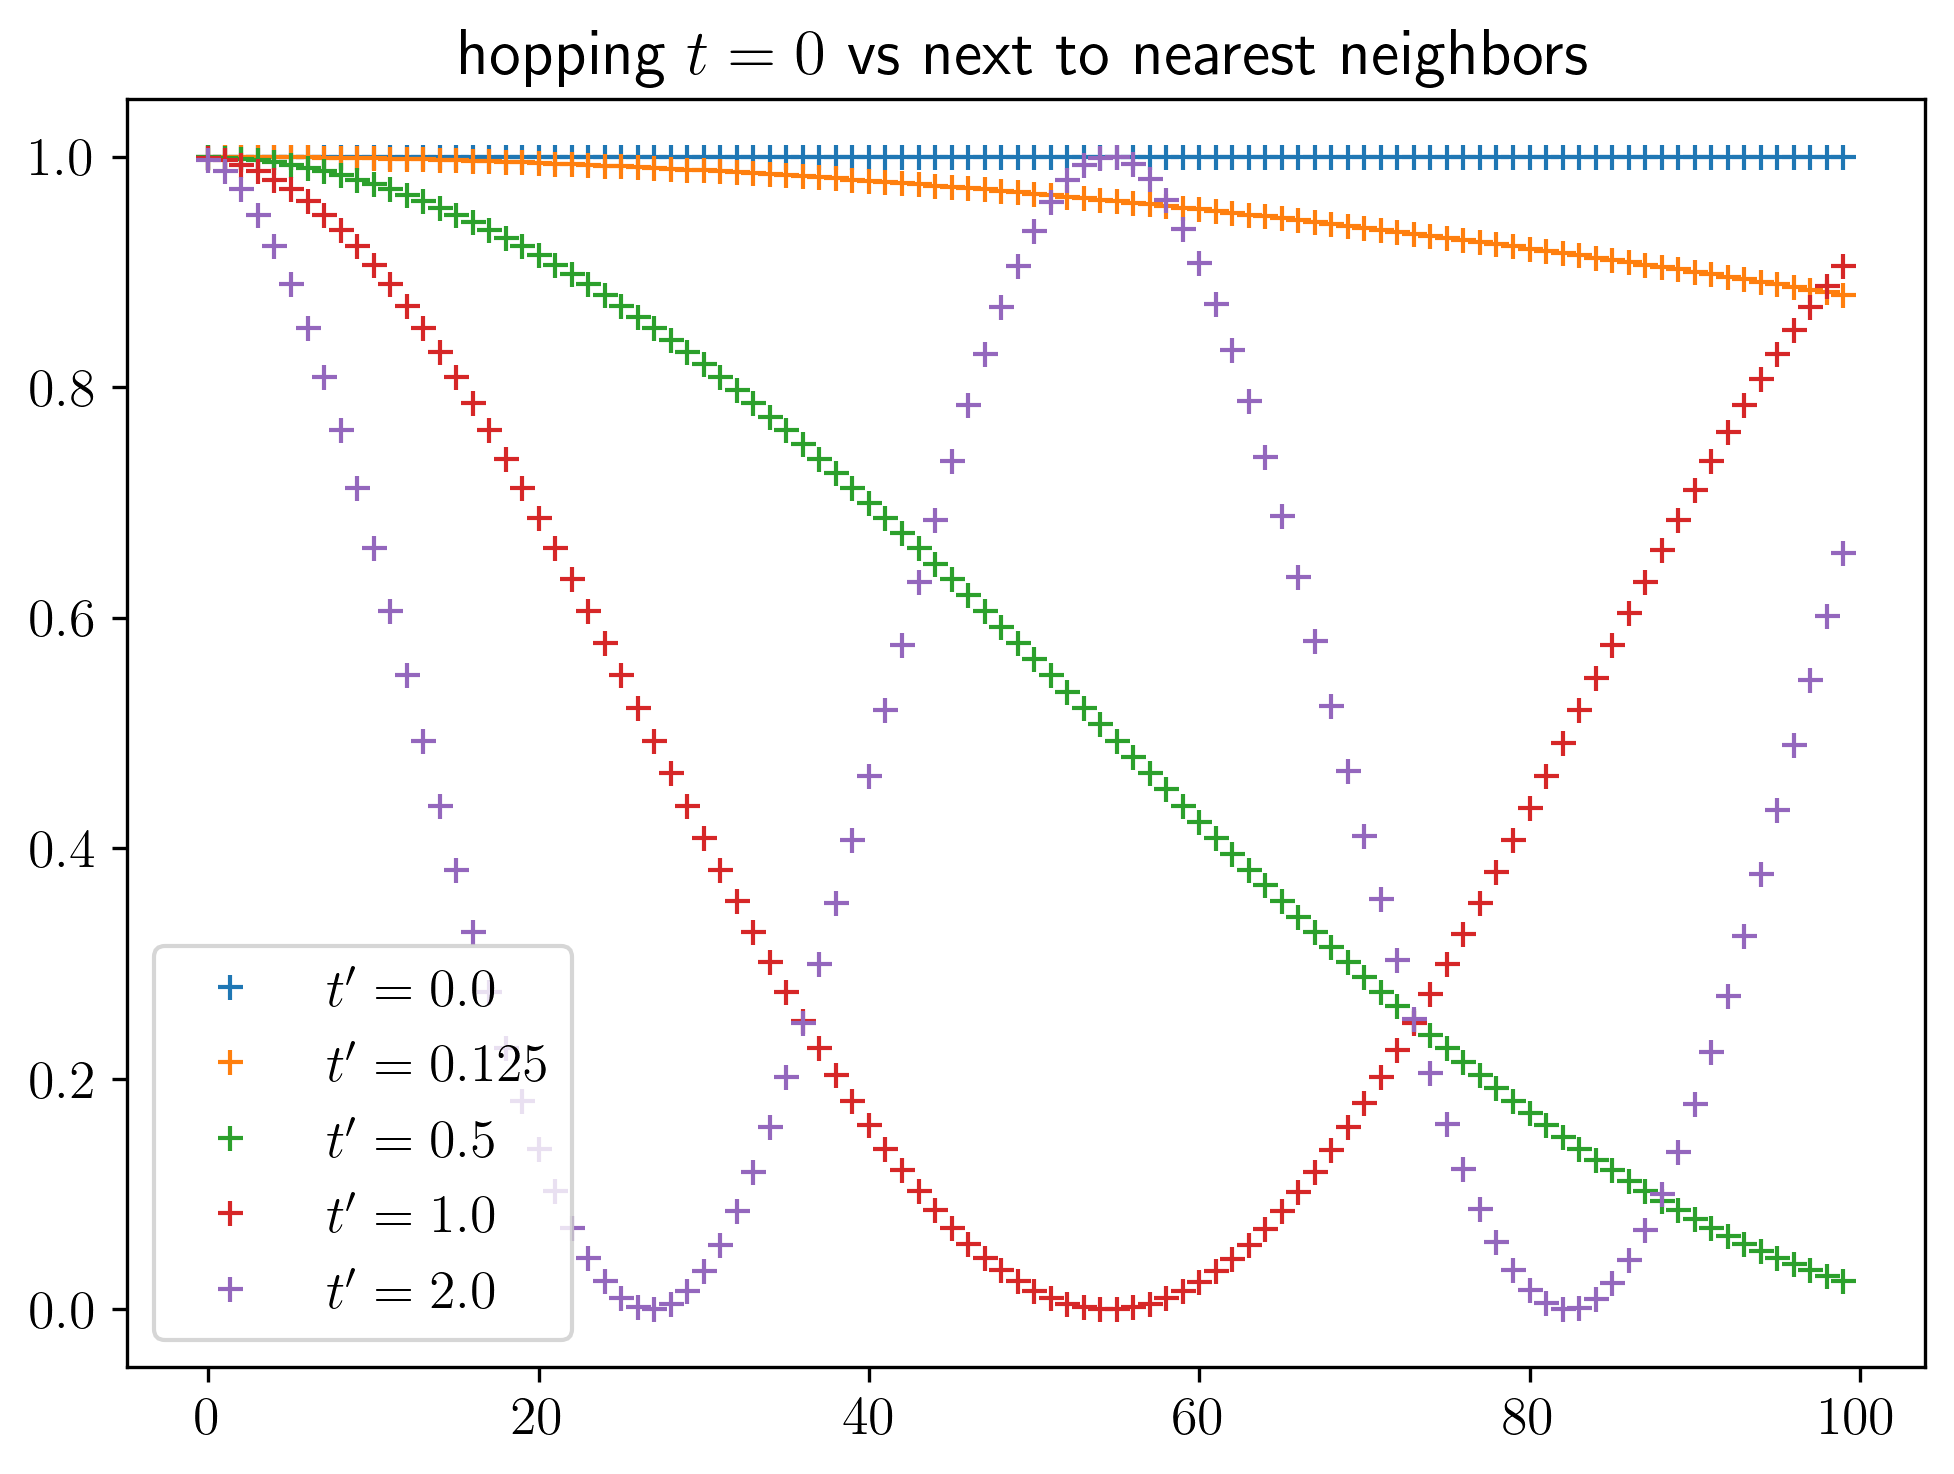

In [66]:
tp_ups = [0,1,4,8,16]
tp_downs = [0,1,4,8,16]
for tp_up, tp_down in zip(tp_ups, tp_downs):
    H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, tp_up=tp_up, tp_down=tp_down)
    occup_tot, _ = half_hole_quench_evolution(half_chain_length, H_ev, psi_init, trotter_steps, final_time)
    plt.plot(np.asarray(occup_tot[0])[:,3],'+', label=f'$t\' ={tp_up/8}$')

plt.title("hopping $t=0$ vs next to nearest neighbors")
plt.legend()

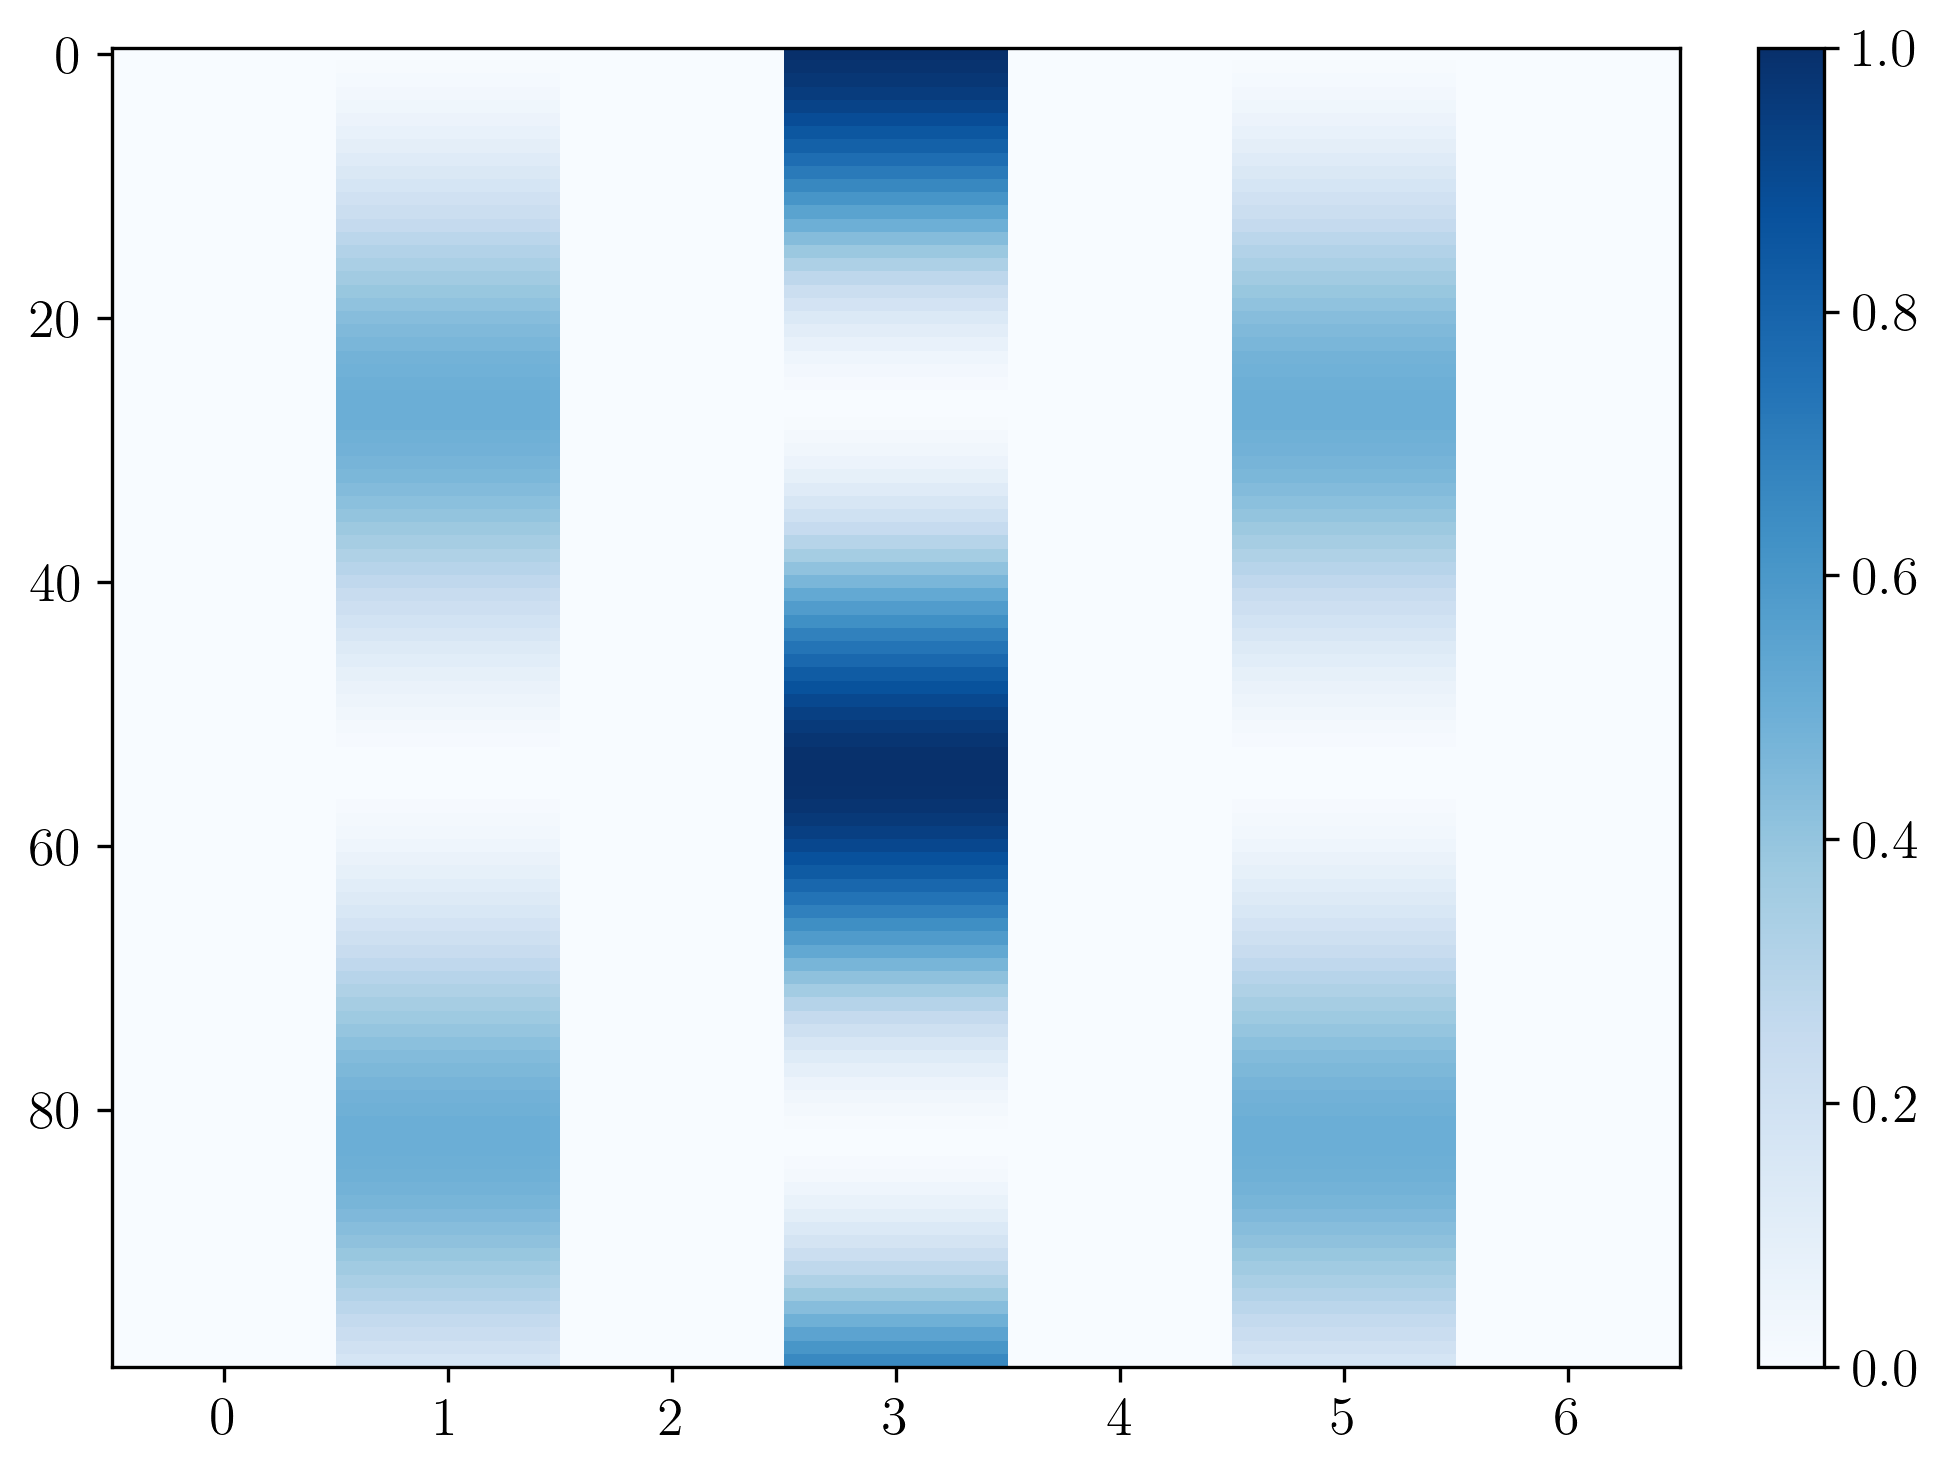

In [67]:
plt.imshow(np.asarray(occup_tot[0]), vmin=0, vmax=1, aspect='auto', cmap="Blues")
plt.colorbar()

In [68]:
n = 2*half_chain_length + 1

op_ev_half, op_ev_delta = U_i_ip1_tJ(Jz, t_up, t_down, J_perp, delta)
site_i_hf, site_ip1_hf = evolution_mpo_svd_1_tJ(op_ev_half)
site_i, site_ip1 = evolution_mpo_svd_1_tJ(op_ev_delta)

op_ev_nnn_delta_half, op_ev_nnn_delta = U_i_ip2_tJ(16,16,delta)
site_1_hf, site_2_hf, site_3_hf = evolution_mpo_svd_2_tJ(op_ev_nnn_delta_half)
site_1, site_2, site_3 = evolution_mpo_svd_2_tJ(op_ev_nnn_delta)

mpo_nnn = evolution_mpo_step_tJ_2(n, site_1_hf, site_2_hf, site_3_hf, site_1, site_2, site_3)
# mpo_nnn = evolution_mpo_step_tJ_2(n, site_1_hf, site_2_hf, site_3_hf, site_1, site_2, site_3)

mpo_id = Id.reshape((1,1,3,3))

mpo_even = [site_i_hf if (i % 2) == 0 else site_ip1_hf for i in range(n-1)]
if (n % 2) == 1:
    mpo_even = mpo_even + [mpo_id]

tensor_shapes(mpo_even)
print("-------------------")

mpo_odd = [mpo_id]
mpo_odd = mpo_odd + [site_i_hf if (i % 2) == 0 else site_ip1_hf for i in range(n-1)]
if (n % 2) == 0:
    mpo_odd = mpo_odd + [mpo_id]

tensor_shapes(mpo_odd)

U_even = mpo_to_matrix(mpo_even)
U_odd = mpo_to_matrix(mpo_odd)
U_nnn = mpo_to_matrix(mpo_nnn)

(1, 9, 3, 3)
(9, 1, 3, 3)
(1, 9, 3, 3)
(9, 1, 3, 3)
(1, 9, 3, 3)
(9, 1, 3, 3)
(1, 1, 3, 3)
-------------------
(1, 1, 3, 3)
(1, 9, 3, 3)
(9, 1, 3, 3)
(1, 9, 3, 3)
(9, 1, 3, 3)
(1, 9, 3, 3)
(9, 1, 3, 3)


In [69]:
# U_step = U_even @ U_odd @ U_nnn @ U_odd @ U_even
U_step = U_even @ U_odd @ U_even

In [70]:
H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, n_holes=1, tp_up=tp_up, tp_down=tp_down)

psi_ev = psi_init.copy()

obs = ['h_loc', 'm_loc']
ops_h = local_hole_occupation(n)
ops_m = local_mag_occupation(n)

occup_tot_h = []
occup_tot_m = []

for t in range(trotter_steps):
    print(f"trotter step: {t}")
    
    psi_ev = U_step @ psi_ev

    if 'h_loc' in obs:
        occup = []
        for op in ops_h:
            occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
            # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
        occup_tot_h.append(occup)

    if 'm_loc' in obs:
        occup = []
        for op in ops_m:
            occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
            # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
        occup_tot_m.append(occup)

trotter step: 0
trotter step: 1
trotter step: 2
trotter step: 3
trotter step: 4
trotter step: 5
trotter step: 6
trotter step: 7
trotter step: 8
trotter step: 9
trotter step: 10
trotter step: 11
trotter step: 12
trotter step: 13
trotter step: 14
trotter step: 15
trotter step: 16
trotter step: 17
trotter step: 18
trotter step: 19
trotter step: 20
trotter step: 21
trotter step: 22
trotter step: 23
trotter step: 24
trotter step: 25
trotter step: 26
trotter step: 27
trotter step: 28
trotter step: 29
trotter step: 30
trotter step: 31
trotter step: 32
trotter step: 33
trotter step: 34
trotter step: 35
trotter step: 36
trotter step: 37
trotter step: 38
trotter step: 39
trotter step: 40
trotter step: 41
trotter step: 42
trotter step: 43
trotter step: 44
trotter step: 45
trotter step: 46
trotter step: 47
trotter step: 48
trotter step: 49
trotter step: 50
trotter step: 51
trotter step: 52
trotter step: 53
trotter step: 54
trotter step: 55
trotter step: 56
trotter step: 57
trotter step: 58
trotter

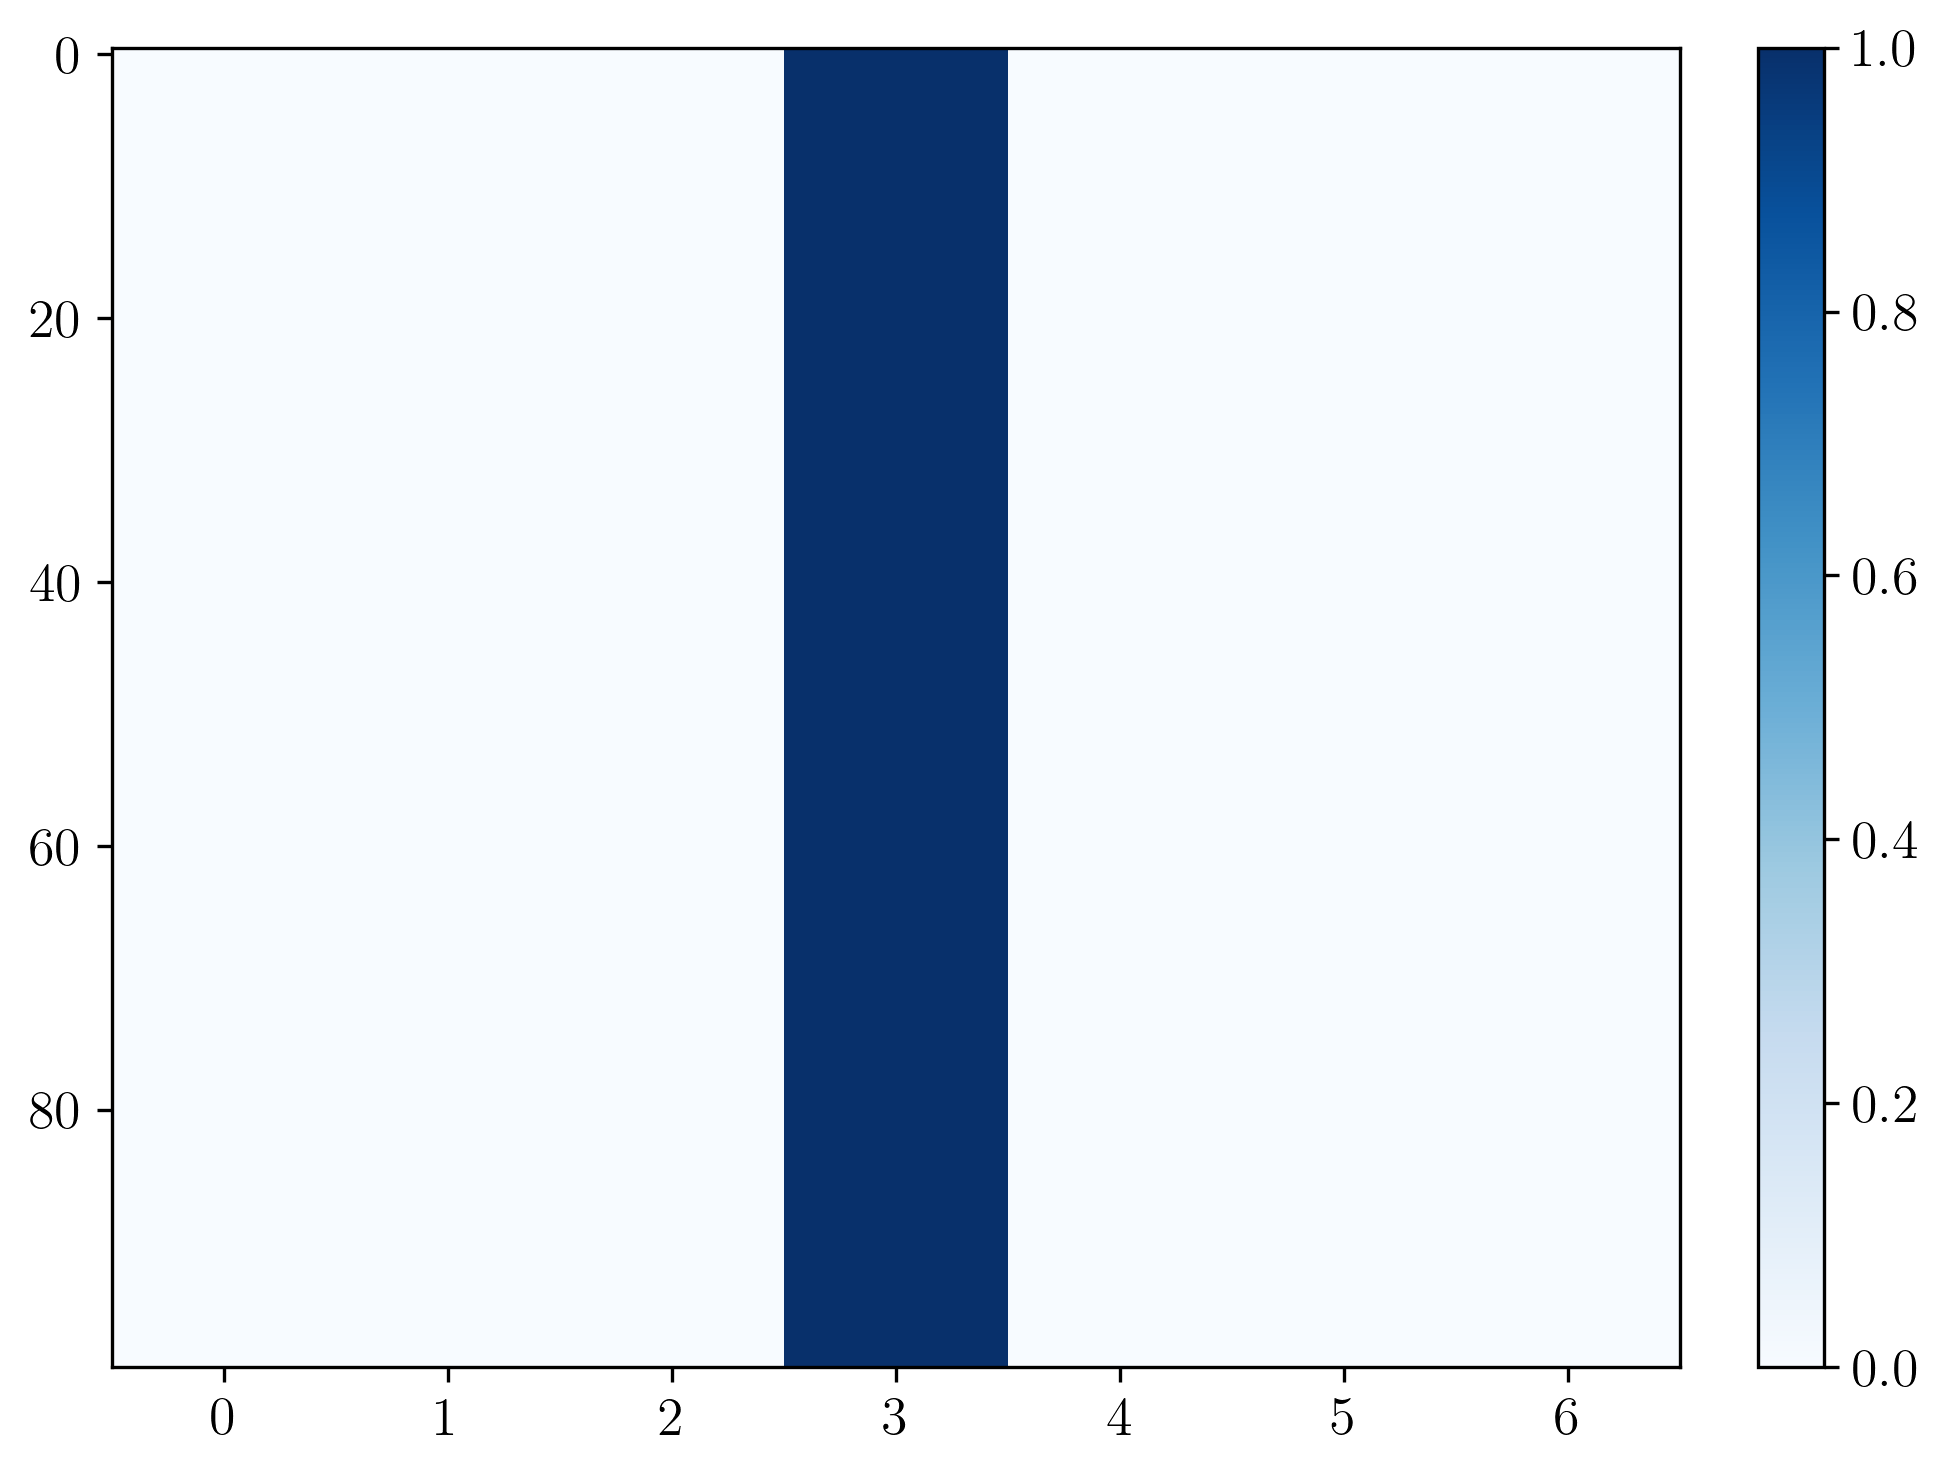

In [71]:
plt.imshow(np.asarray(occup_tot_h), vmin=0, vmax=1, aspect='auto', cmap="Blues")
plt.colorbar()